# WH - Limit Plots

This notebook plots:

- 1D Brazil limit plots which show the observed and expected xsection limits as a function of $m_s$ for a given $m_{\phi}$, T and decay mode.  
- 2D limit plot of the observed excluded mu value as a function of $m_{\phi}$ (x-axis) and T (y-axis). 
- Summary plots: showing the $\mu=1$ exclusion limit for every value of $m_s$ and decay mode.

Using functions in `plot_utils.py`.

Use the Outline to navigate to the desired section.

In [ ]:
%config InlineBackend.figure_format = 'retina'
import os
import matplotlib.pyplot as plt
from matplotlib import ticker
import numpy as np
import plot_utils as utils

plt.style.use('physics.mplstyle')

import mplhep as hep
hep.style.use("CMS")

In [17]:
# parameters
itag = '../cards/WH_2_6_toys/'

# outDir = '/home/submit/{}/public_html/SUEP/limits/debug/'.format(os.environ['USER'])
outDirAN = '/home/submit/{}/SUEP/AN-23-183/images/'.format(os.environ['USER'])
# outDirPaper = '/home/submit/{}/SUEP/EXO-23-002/'.format(os.environ['USER'])
# outDirSupp = '/home/submit/{}/SUEP/EXO-23-002/supplementary/'.format(os.environ['USER'])
outDirPAS = '/home/submit/lavezzo/SUEP/PAS/EXO-24-030/images/'

saveToAN = True
saveToPaper = False
saveToPAS = True

# if not os.path.isdir(outDir): os.mkdir(outDir)

## 1D Limits: $T_D/m_{\phi}$ scan

In [18]:
import numpy as np
zh = np.loadtxt("SRCR_generic_limAsy.txt", delimiter=":")
norm = 0.909
obs = zh[:,-1]
mPhi = zh[:,1]
T = zh[:,2]
s2m = zh[:, 3]
s1m = zh[:, 4]
exp = zh[:, 5]
s1p = zh[:, 6]
s2p = zh[:, 7]

FileNotFoundError: SRCR_generic_limAsy.txt not found.

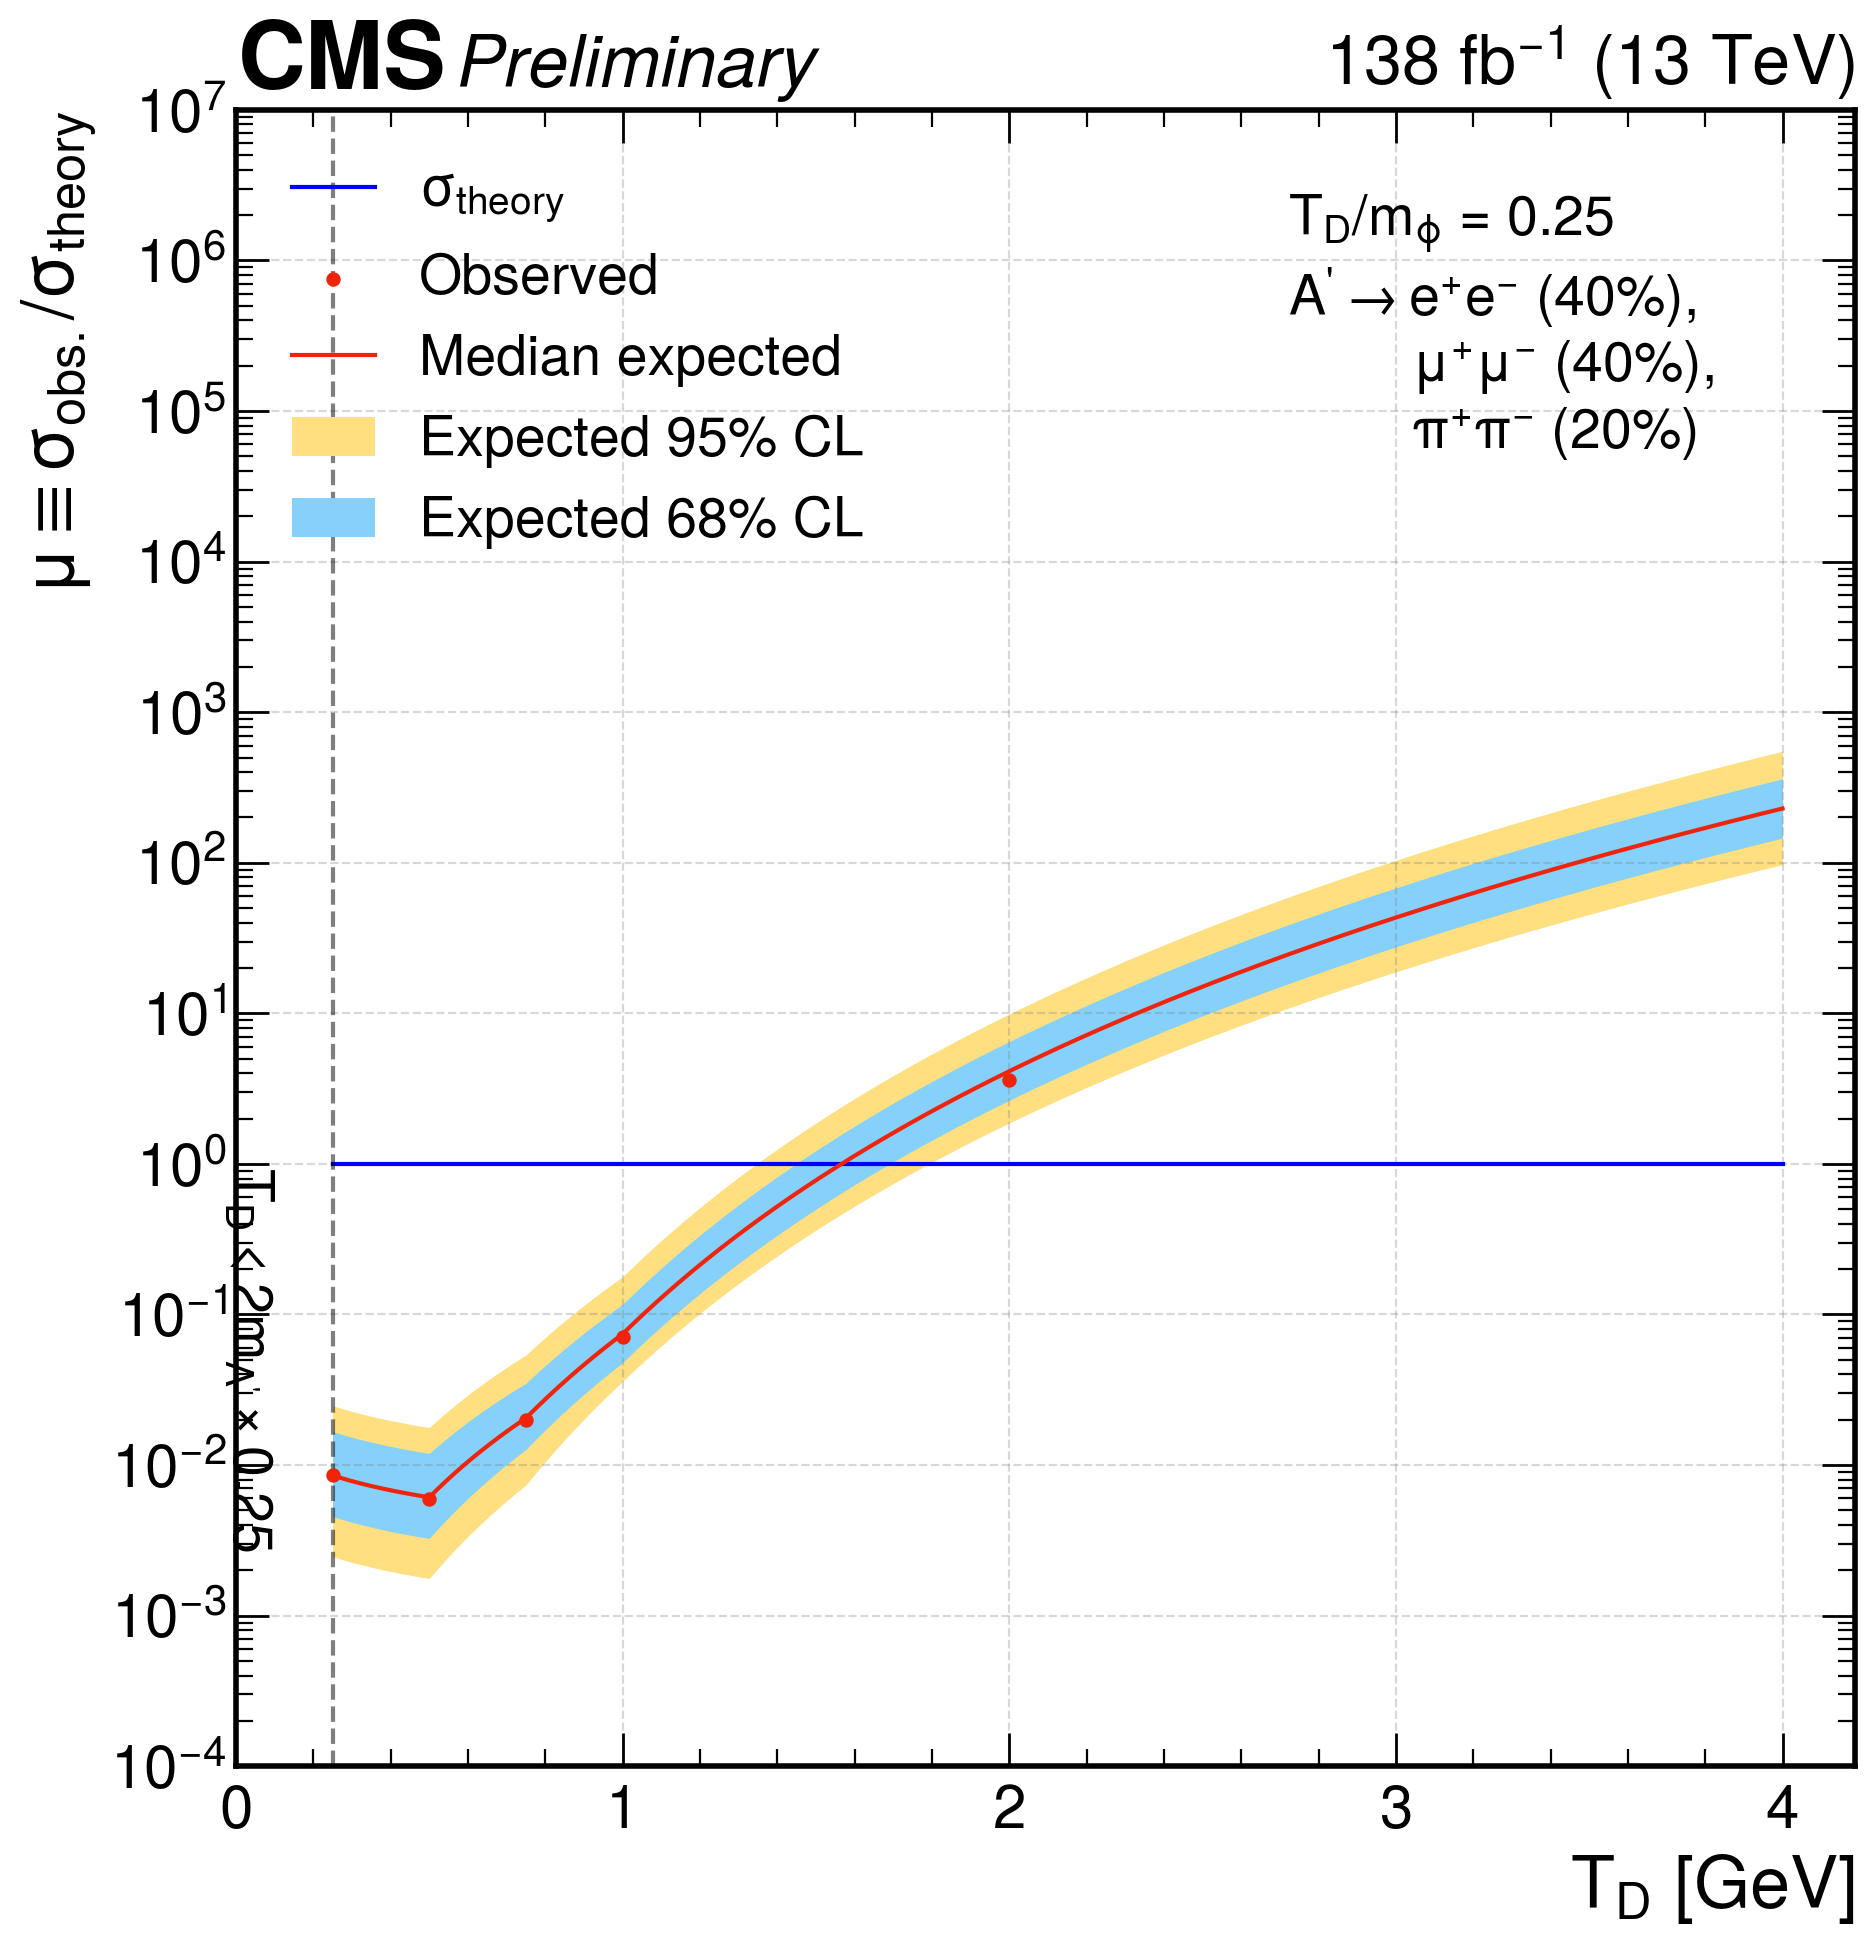

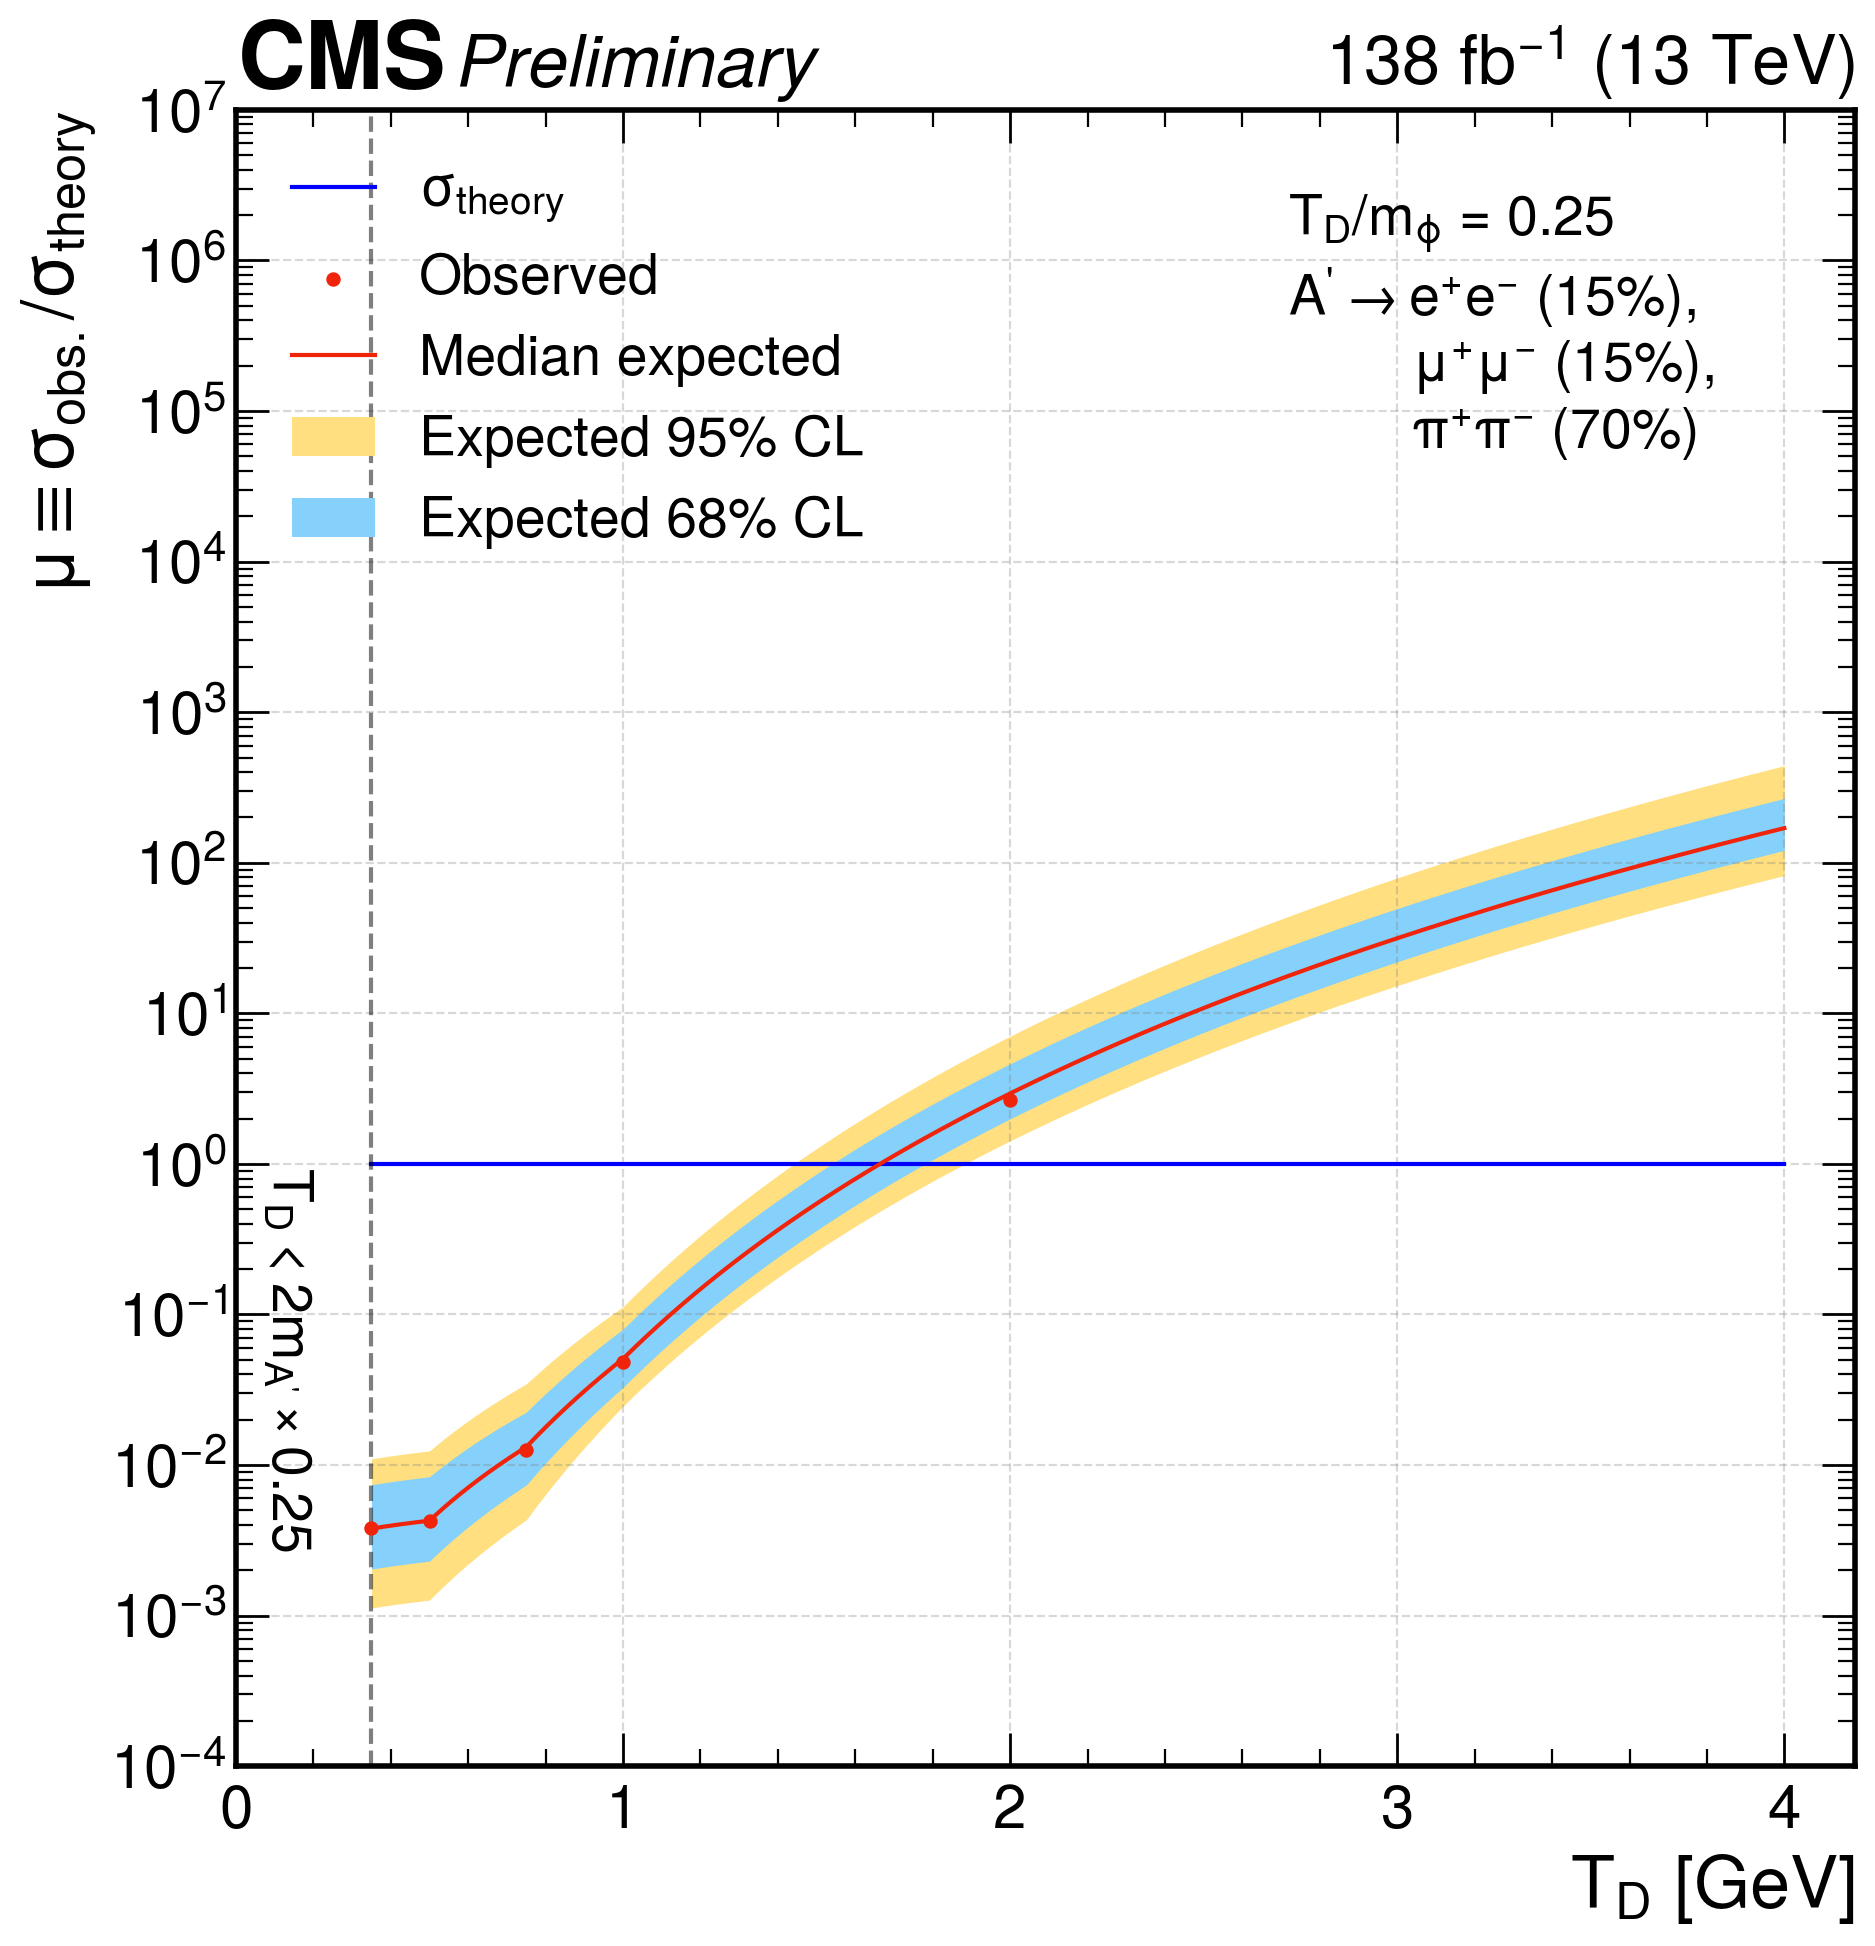

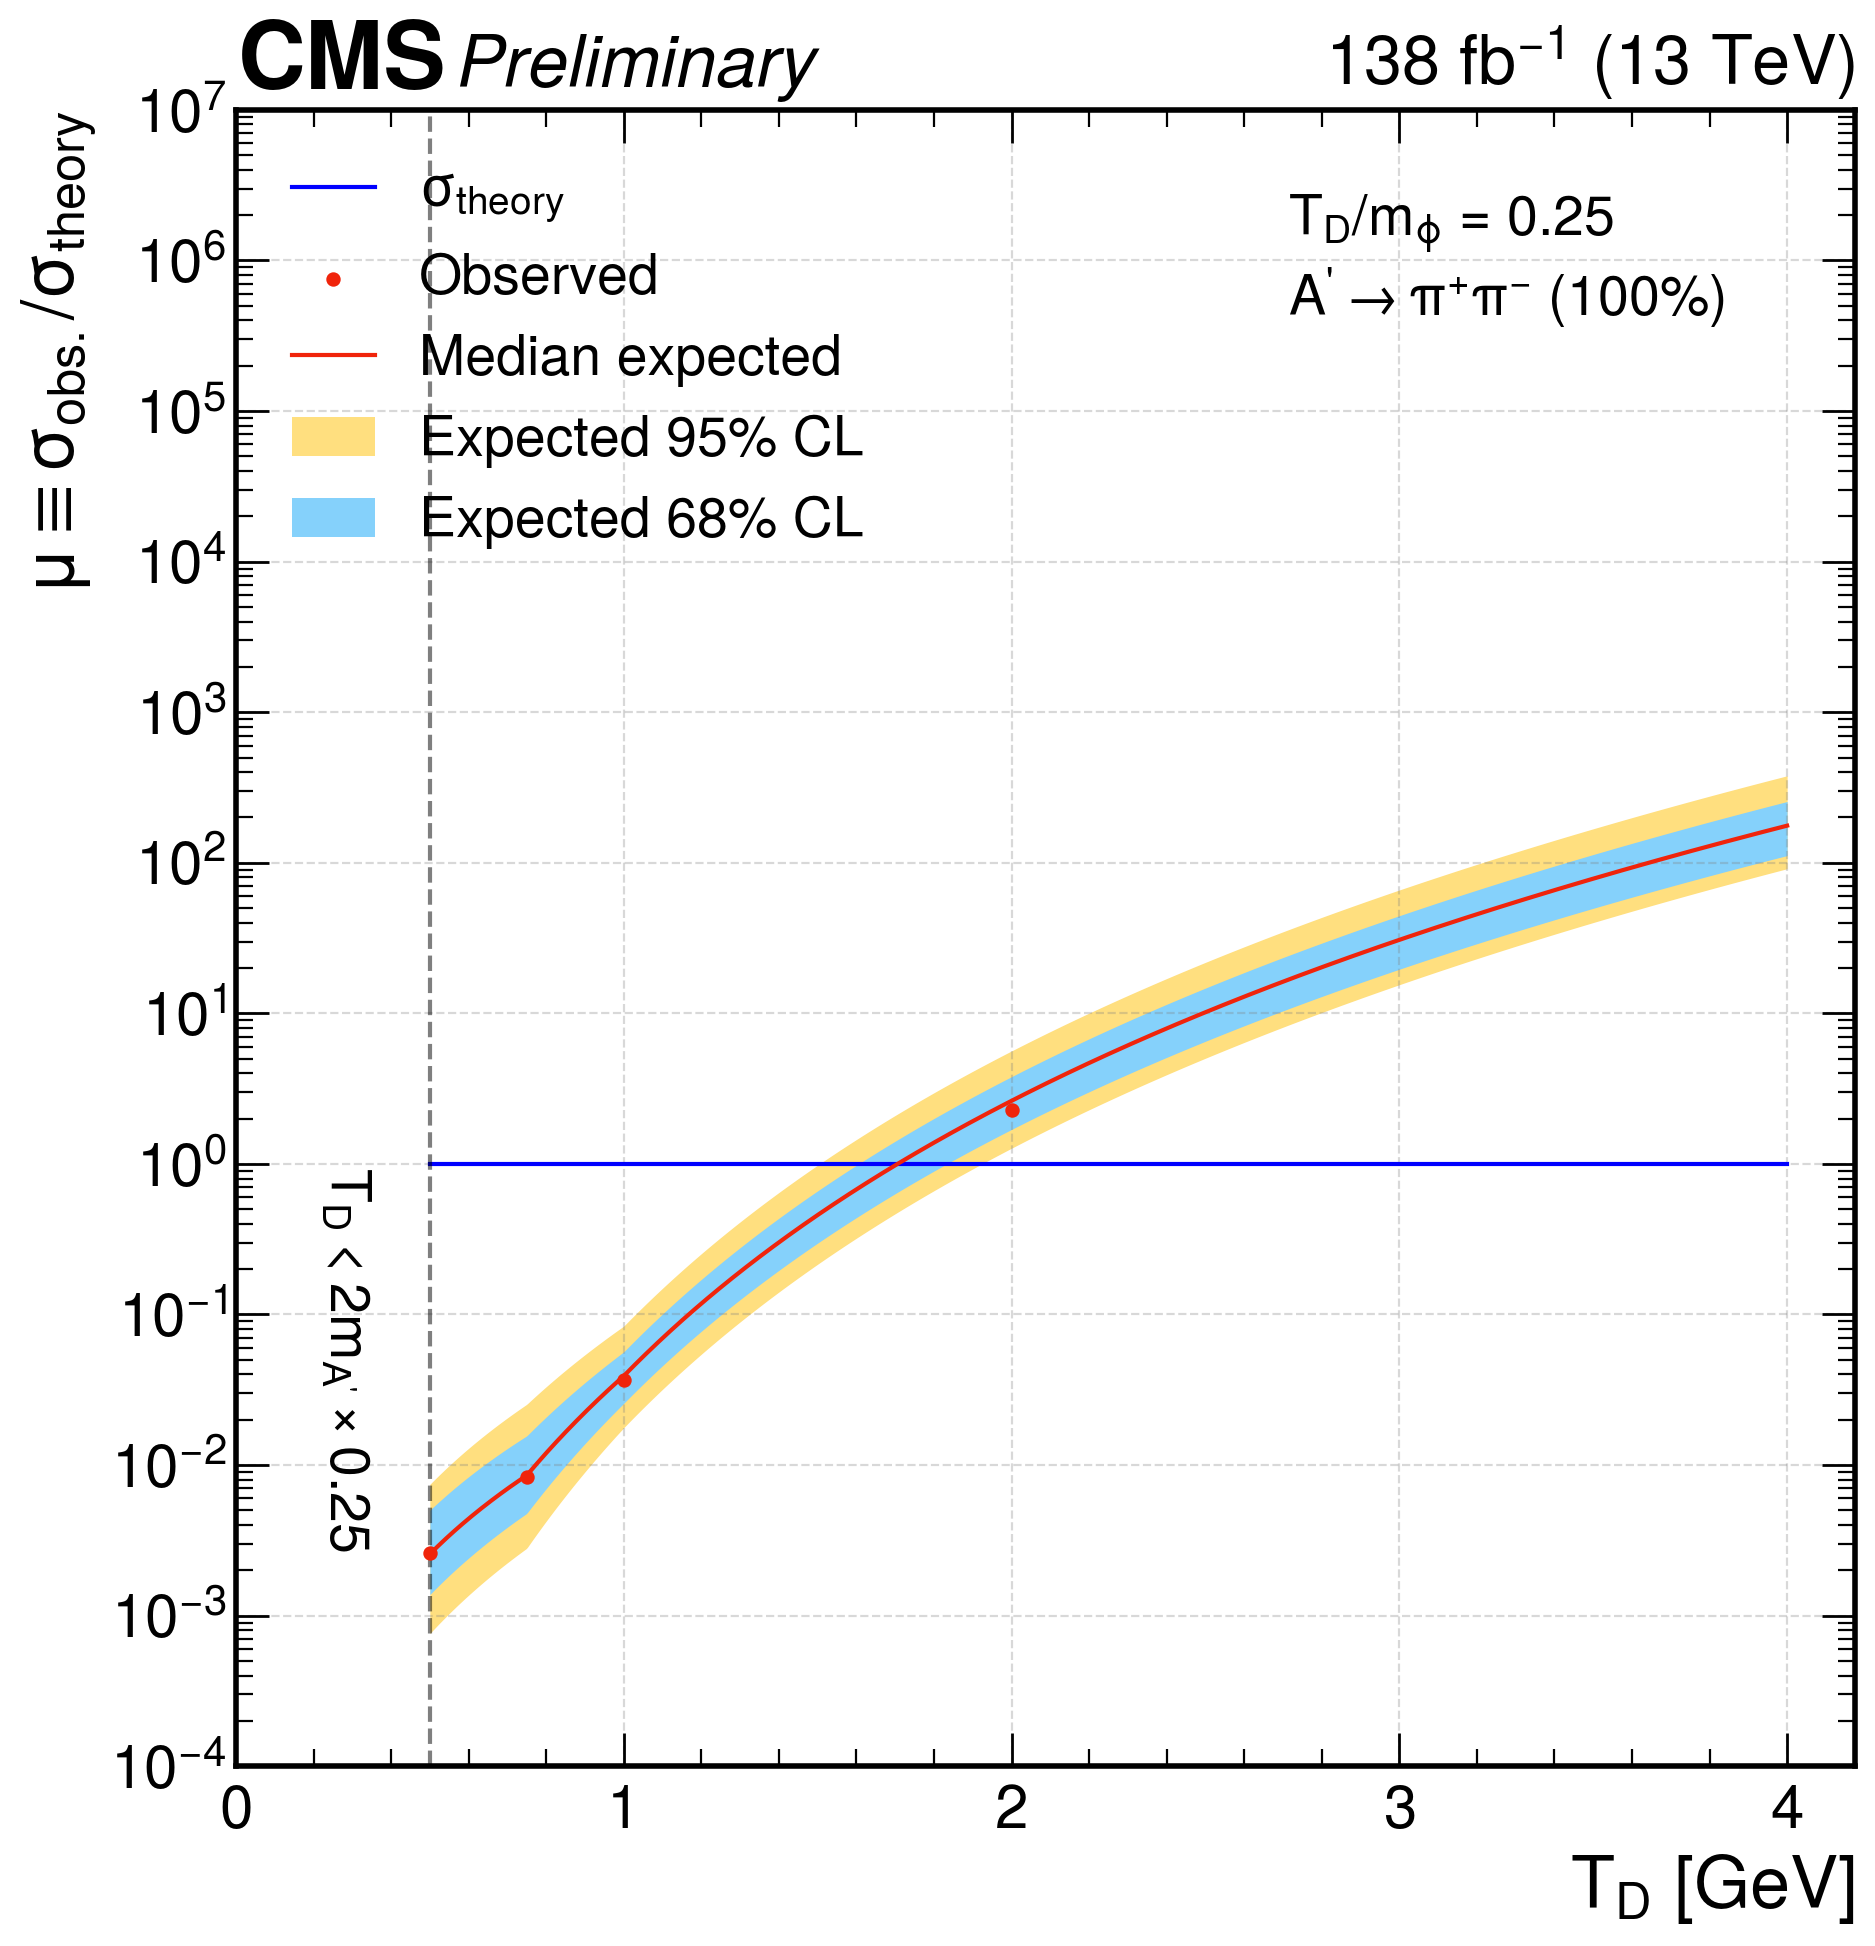

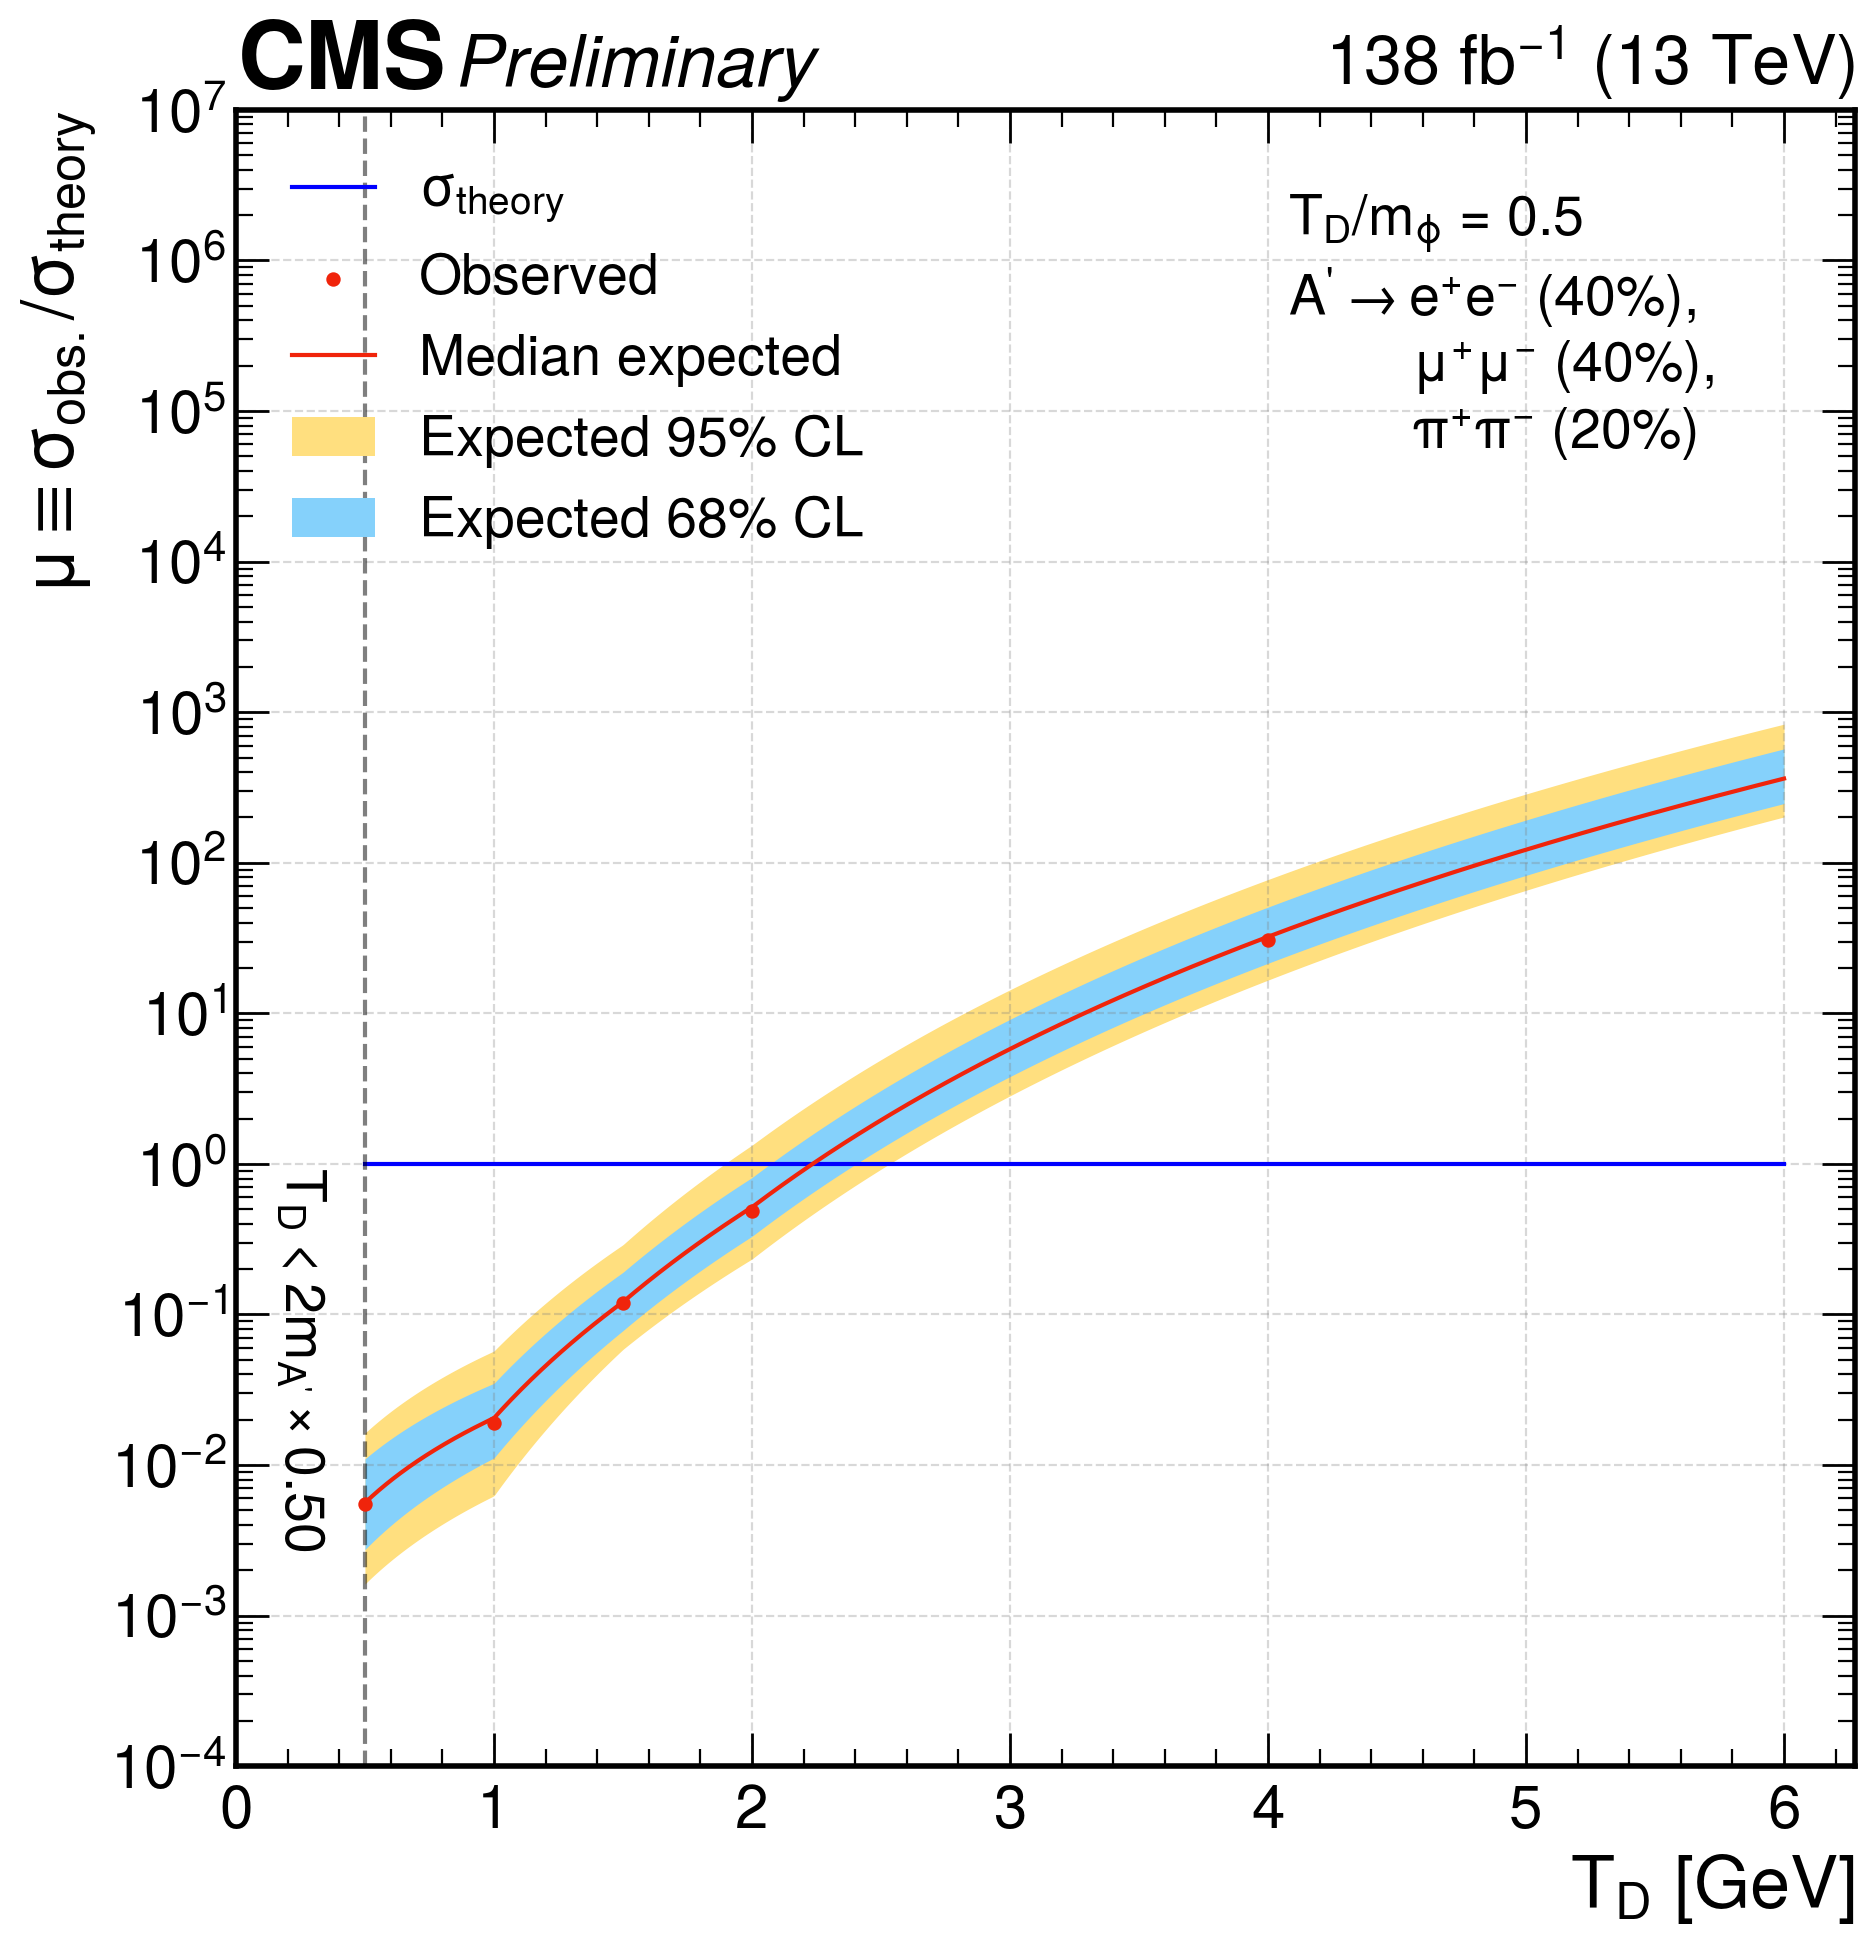

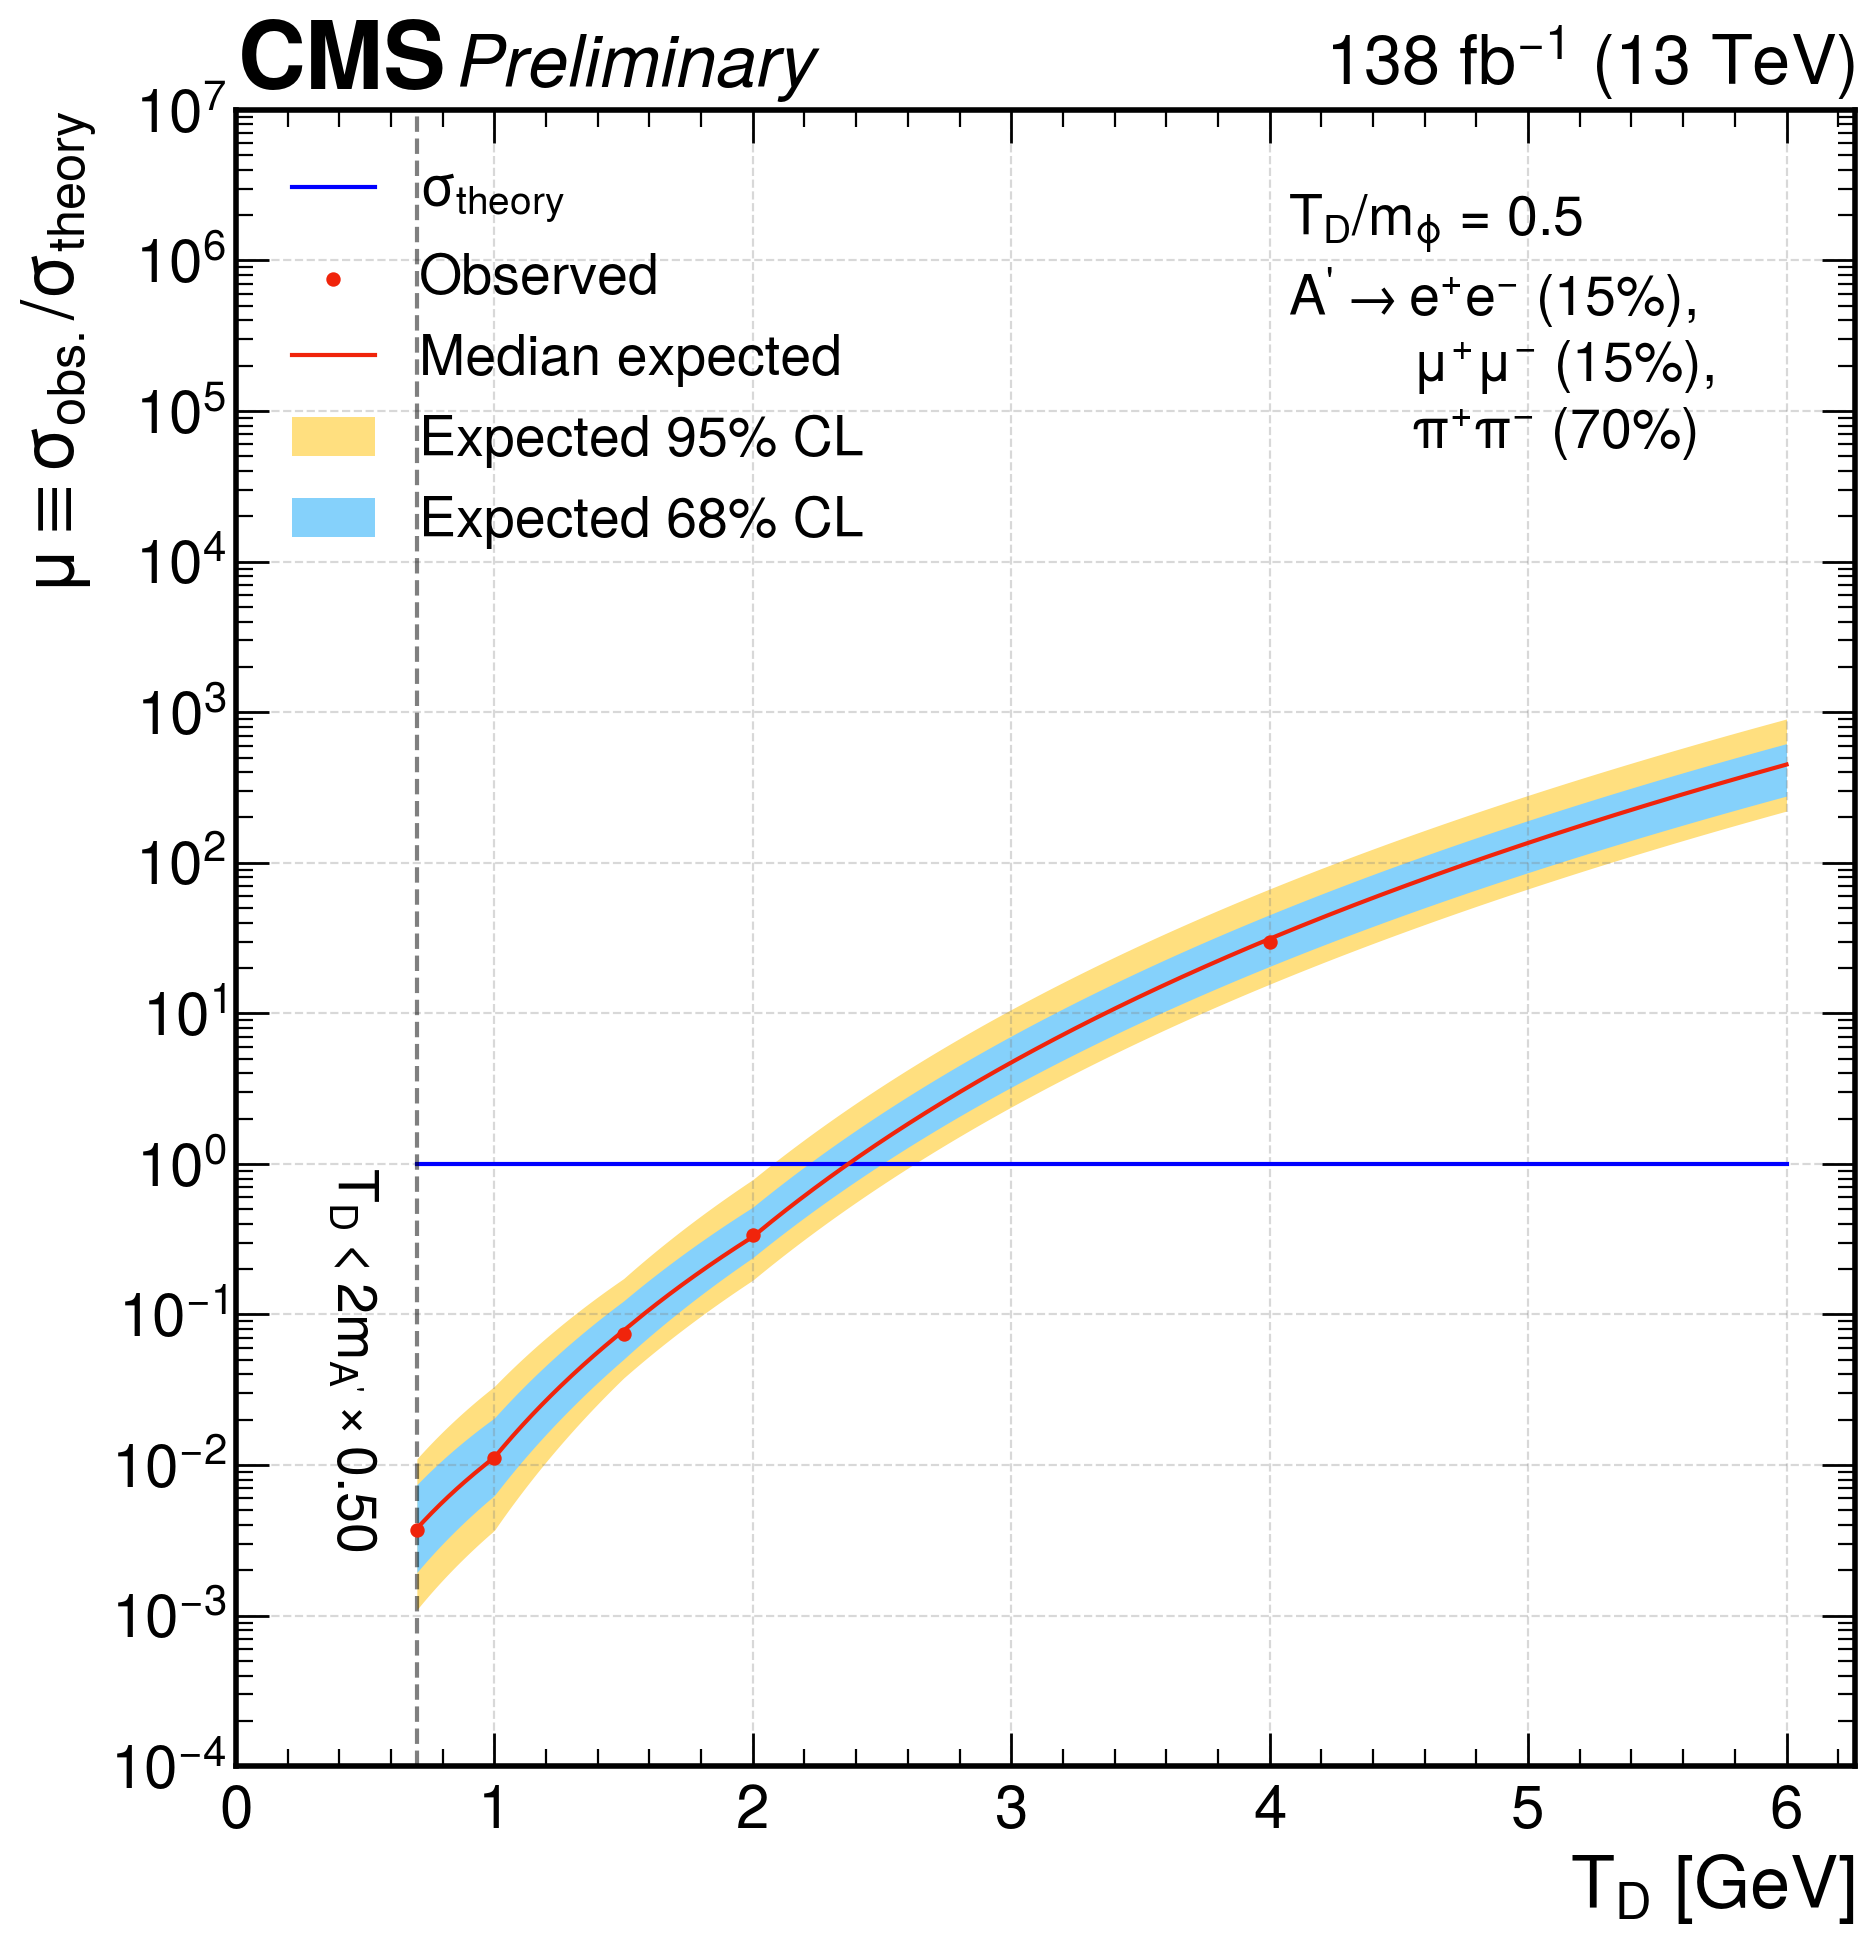

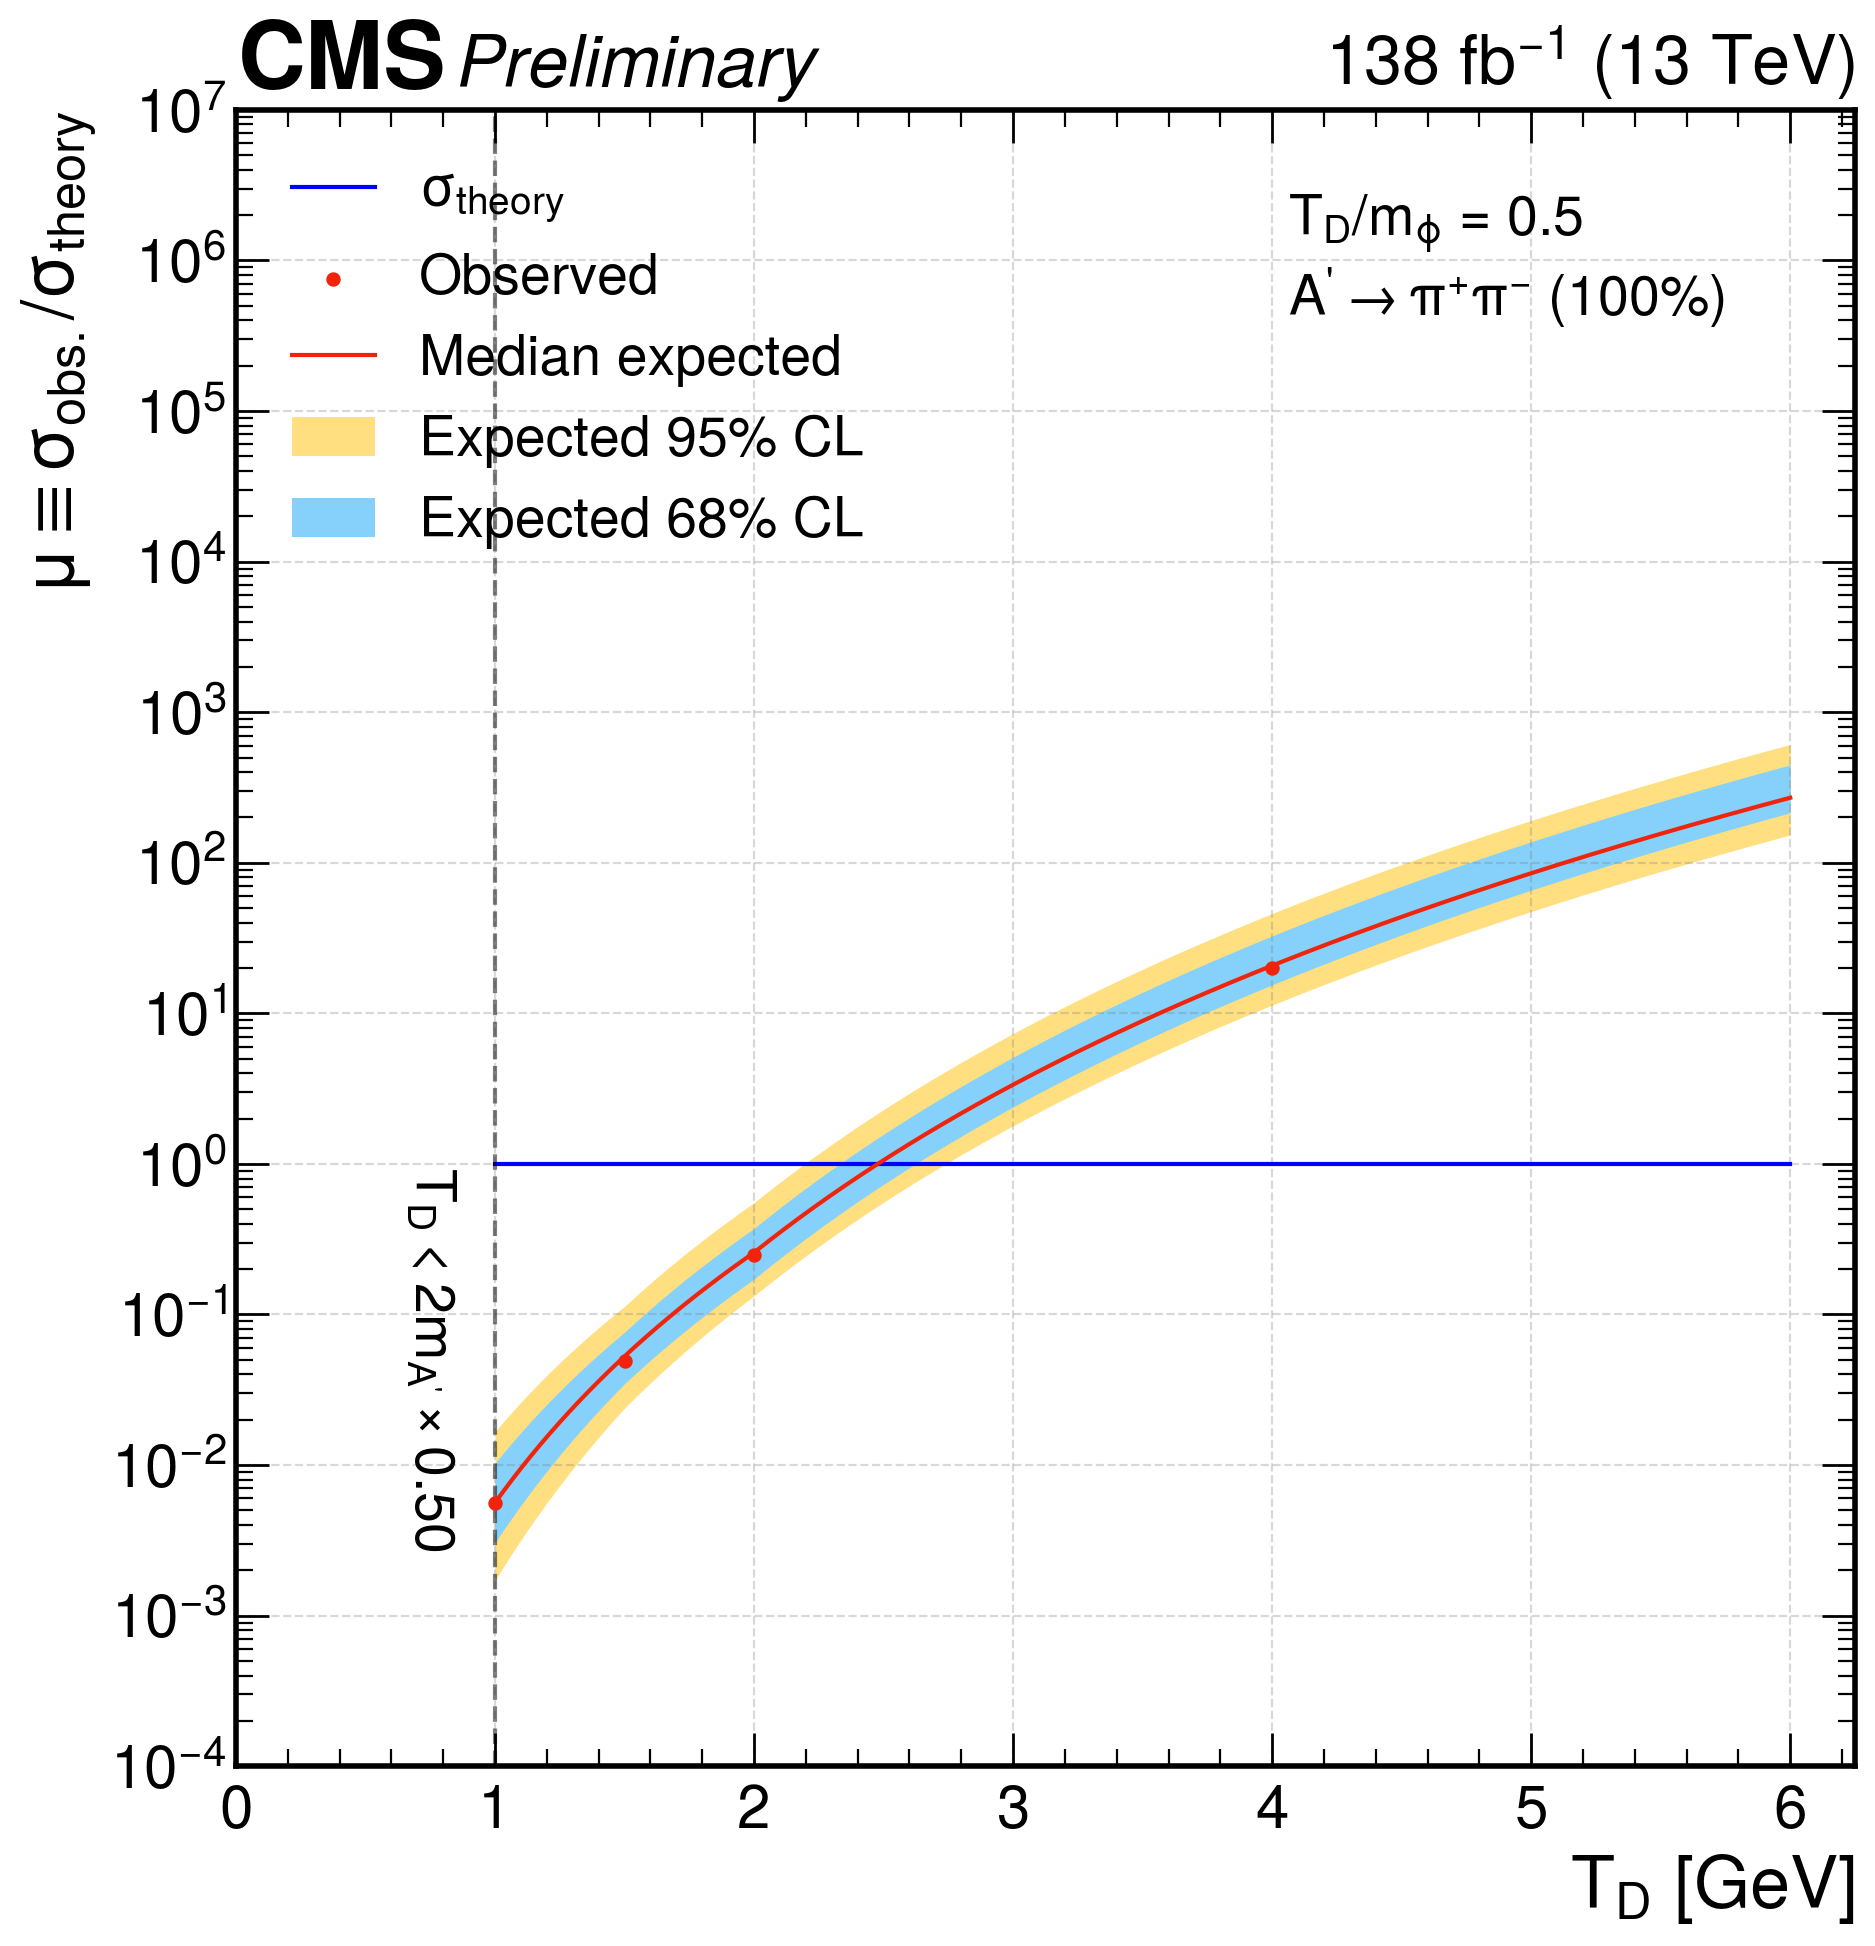

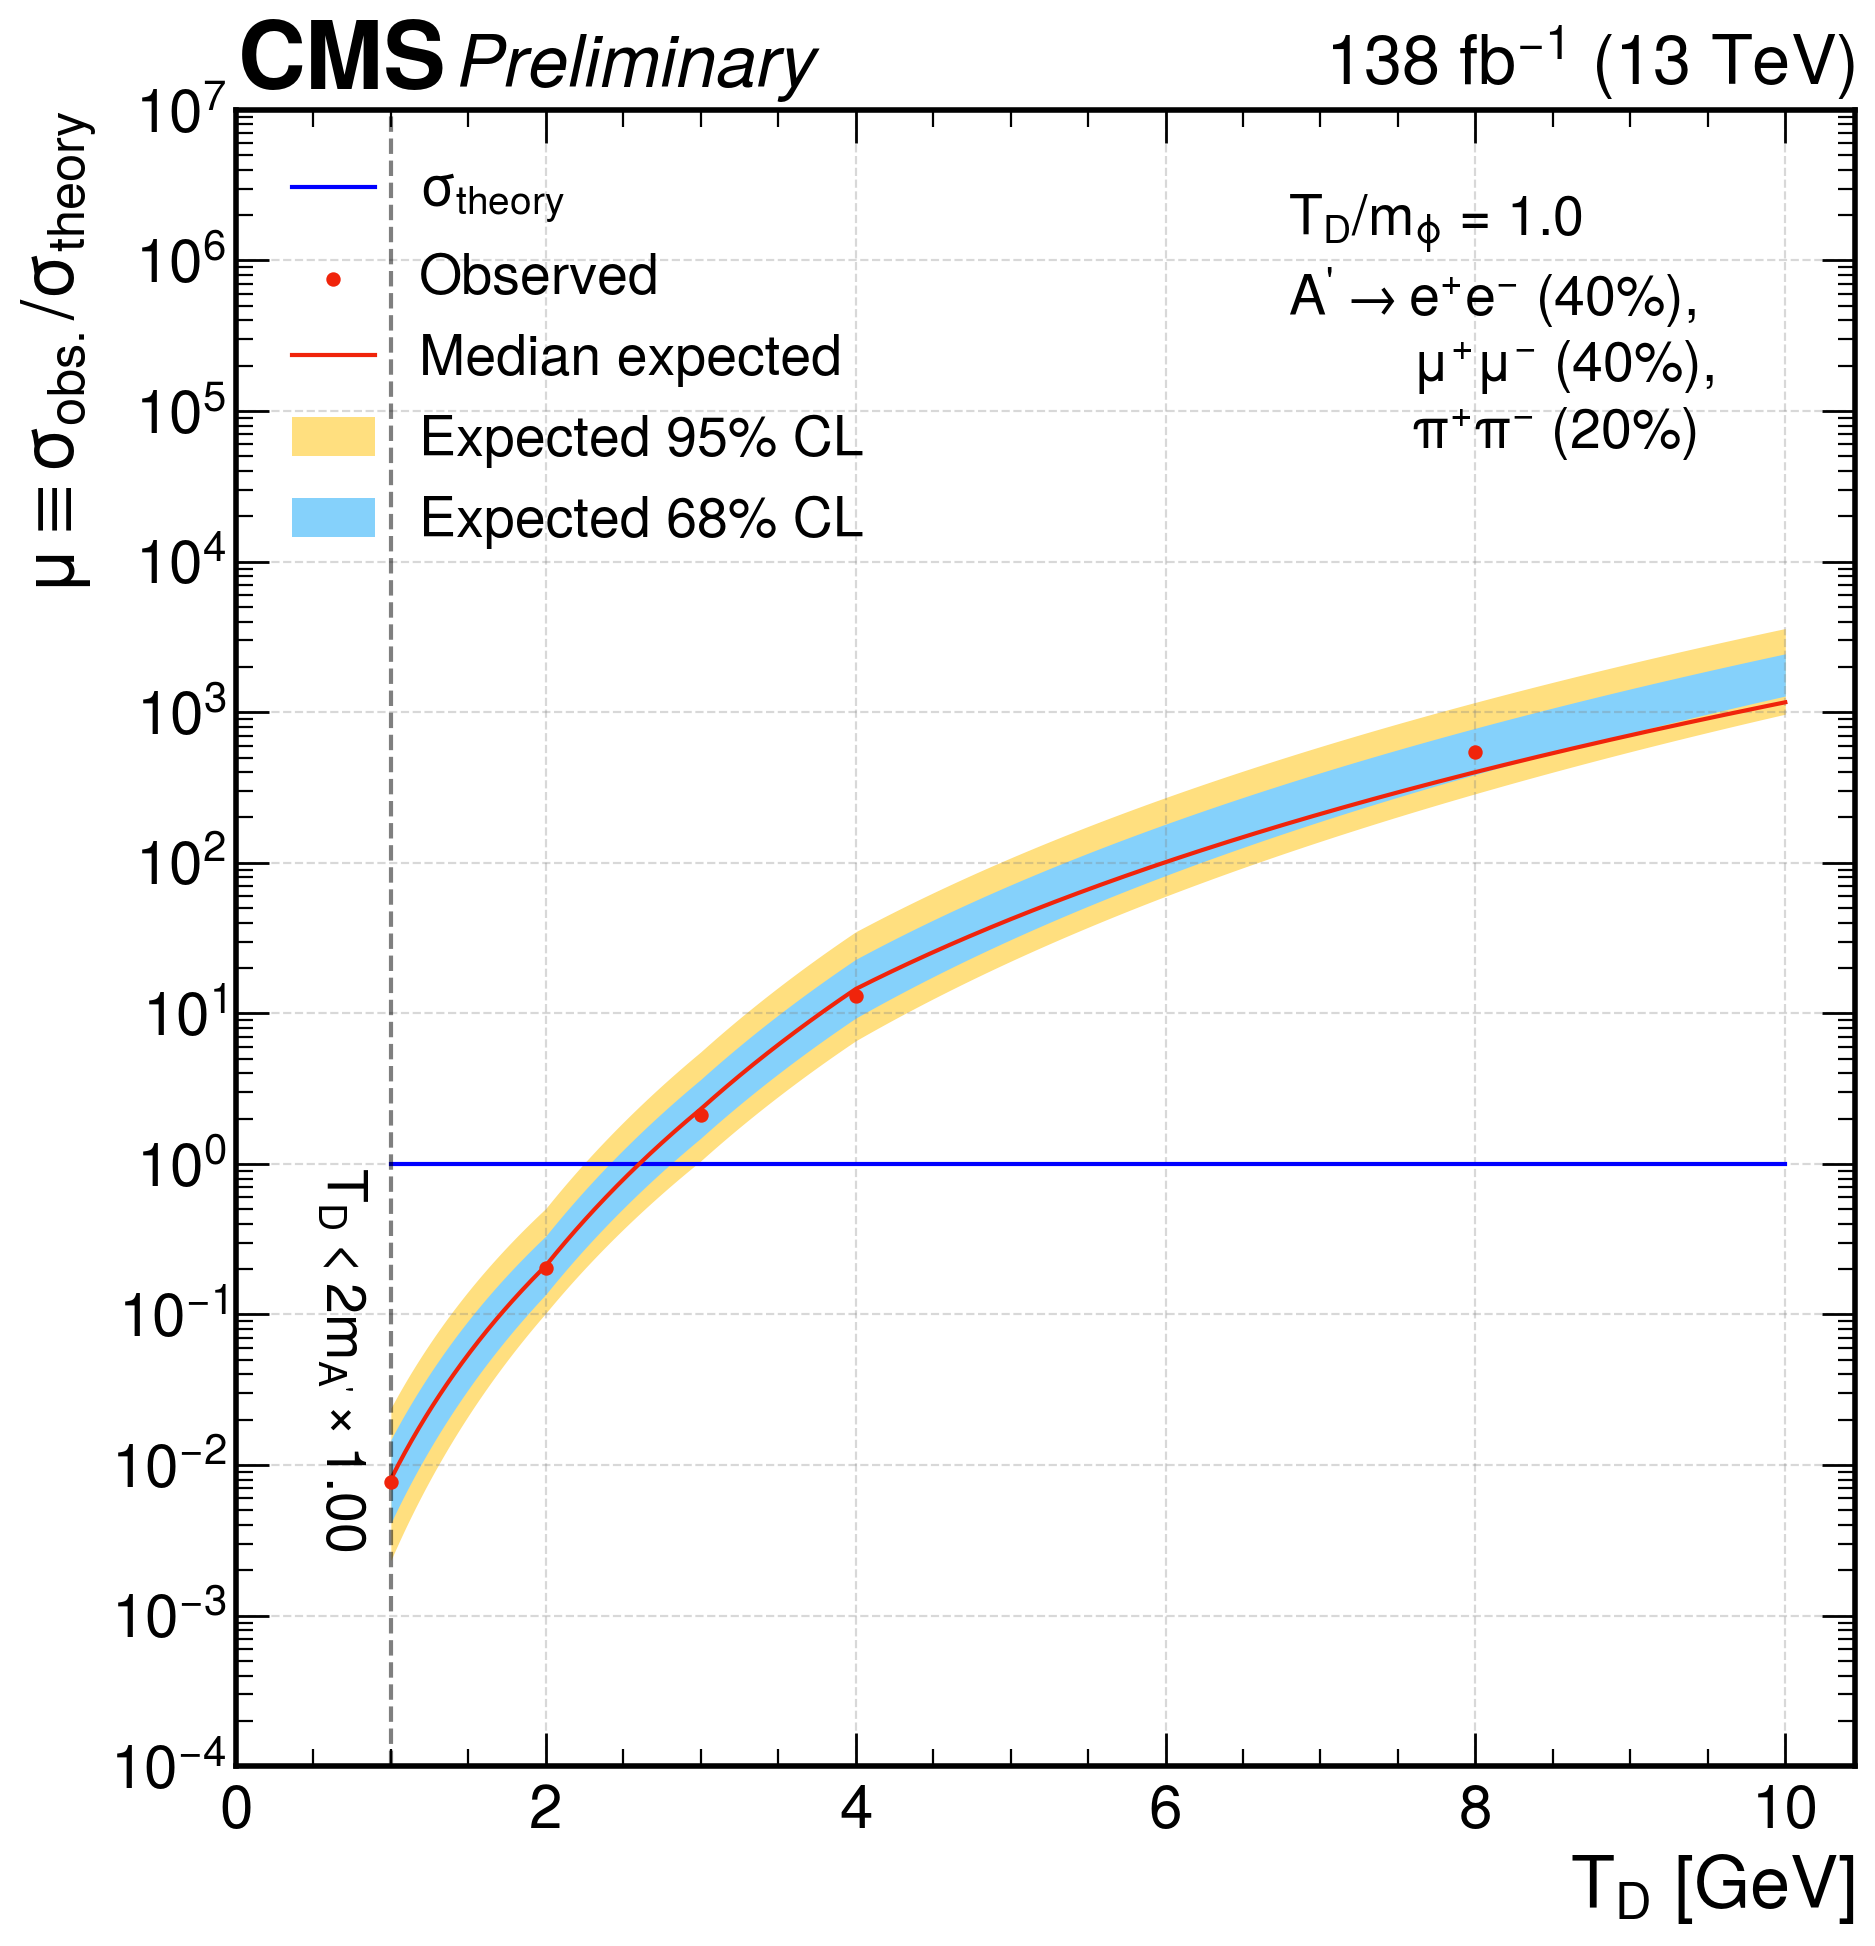

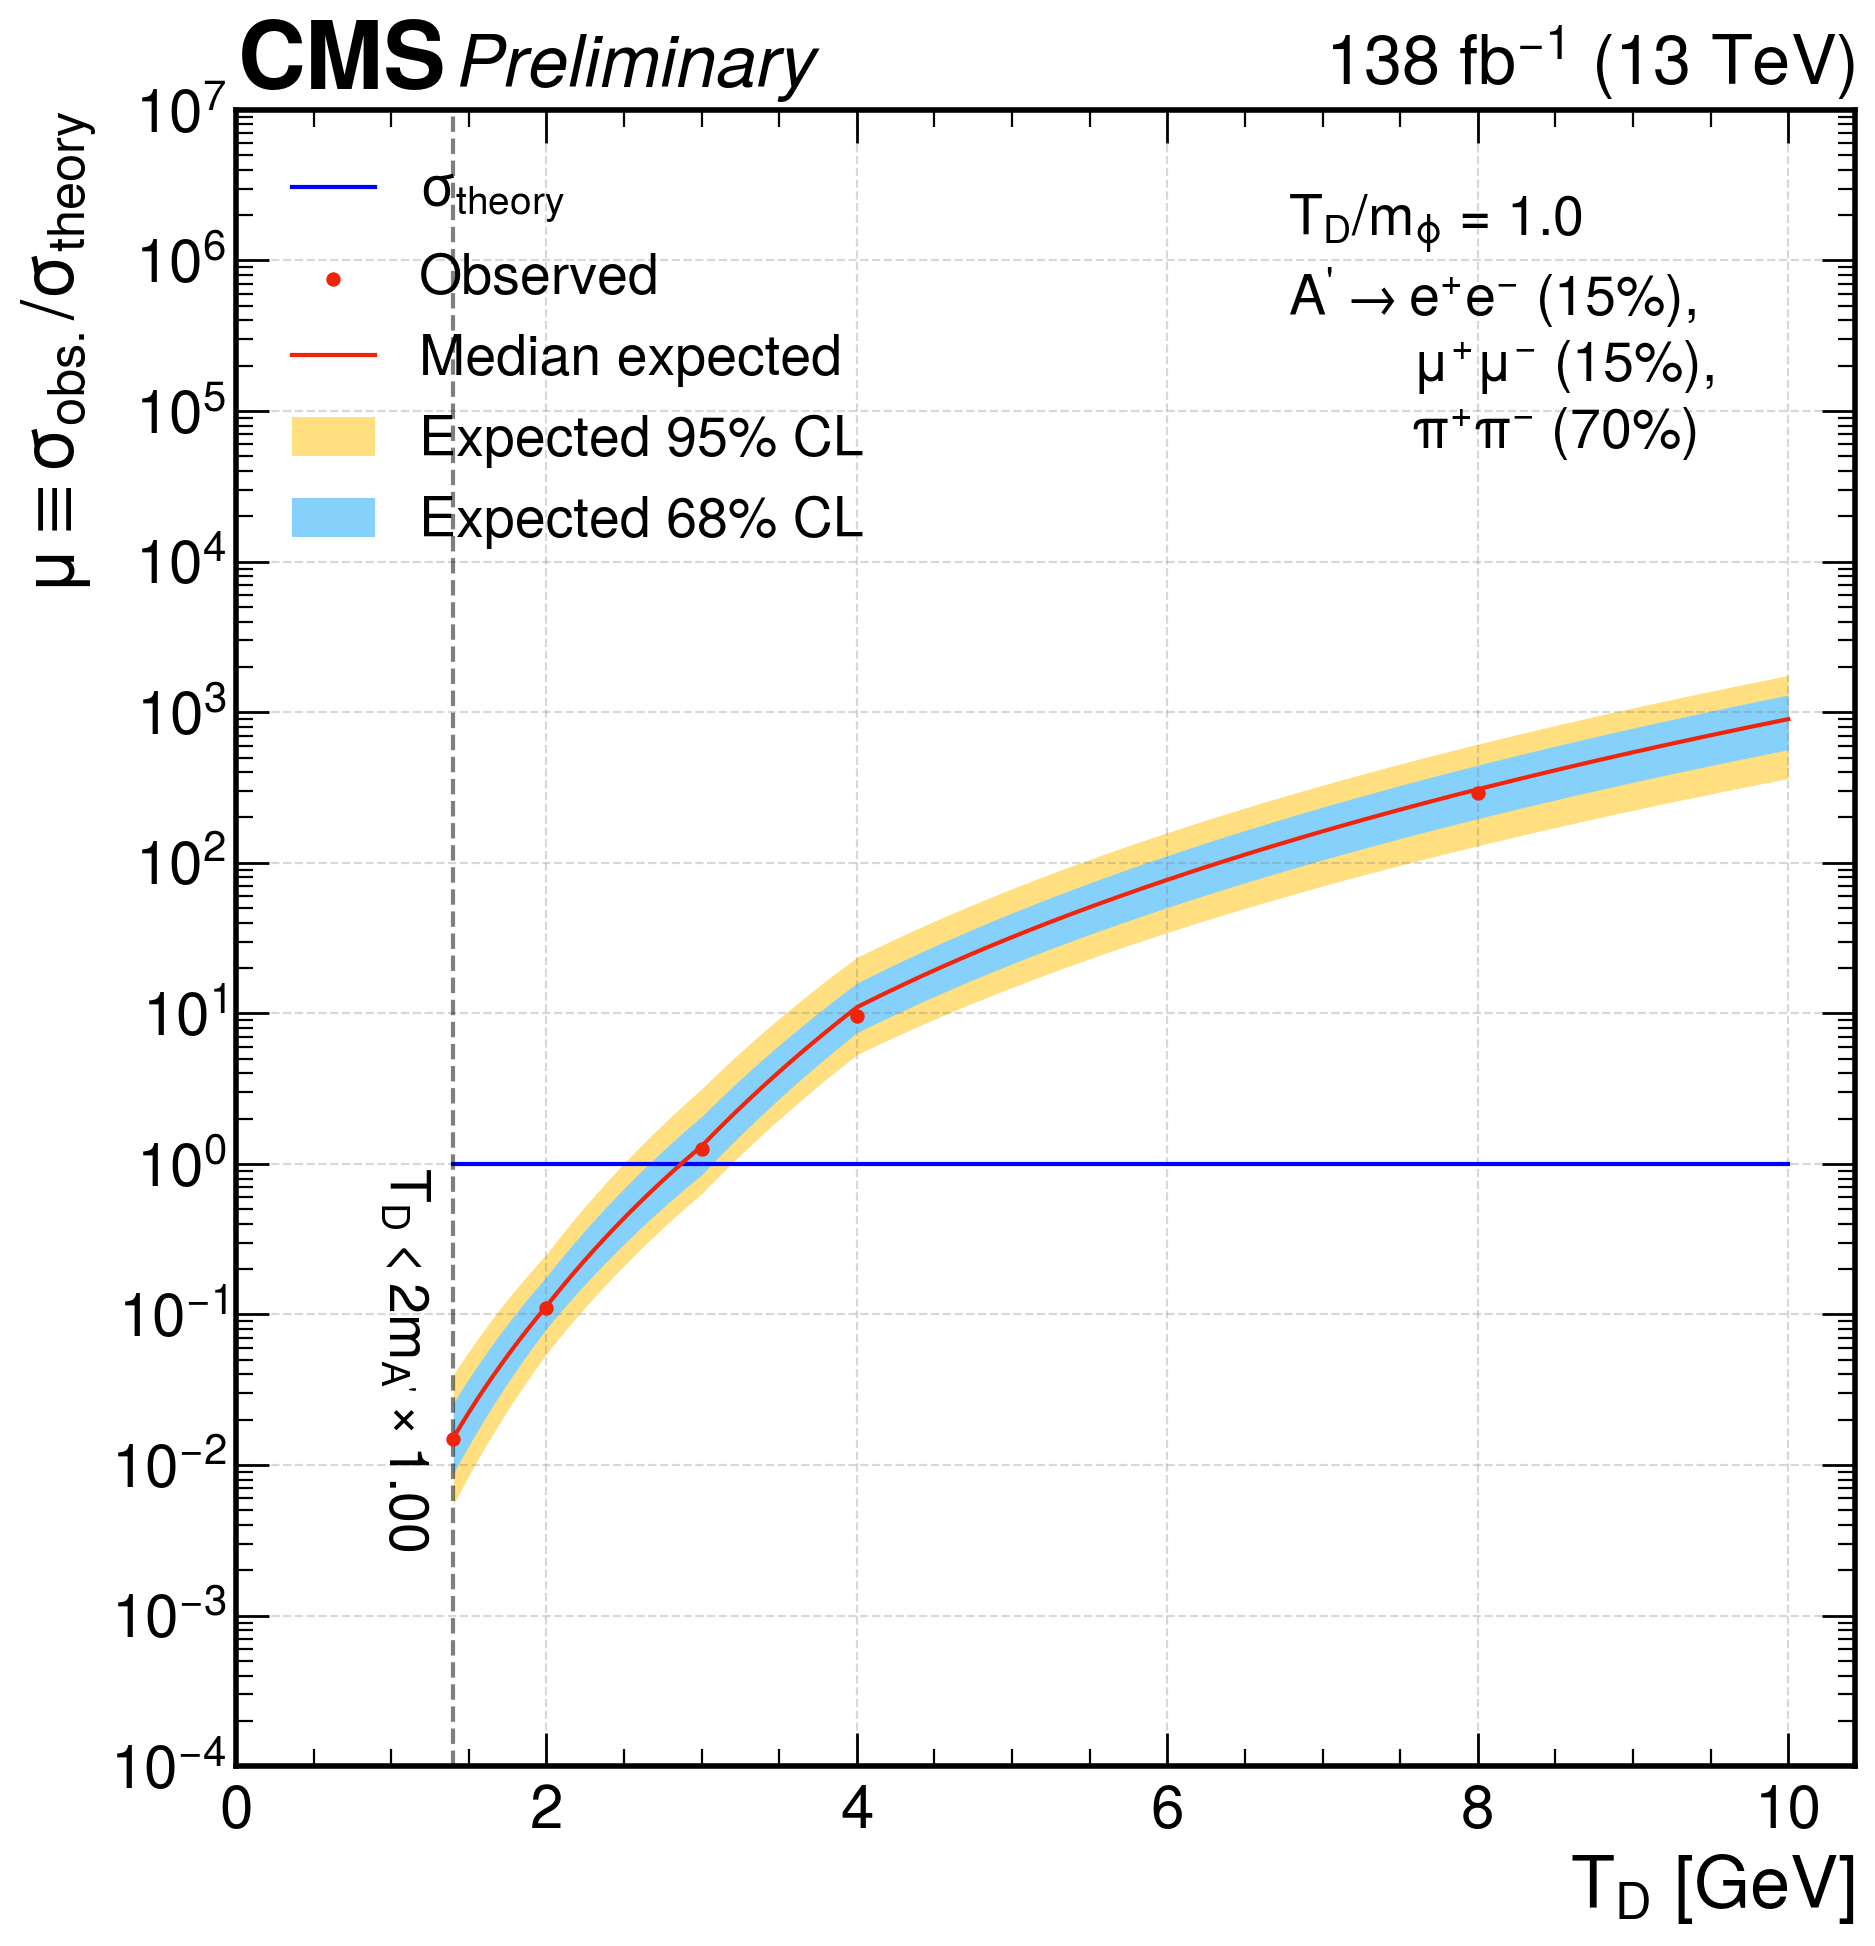

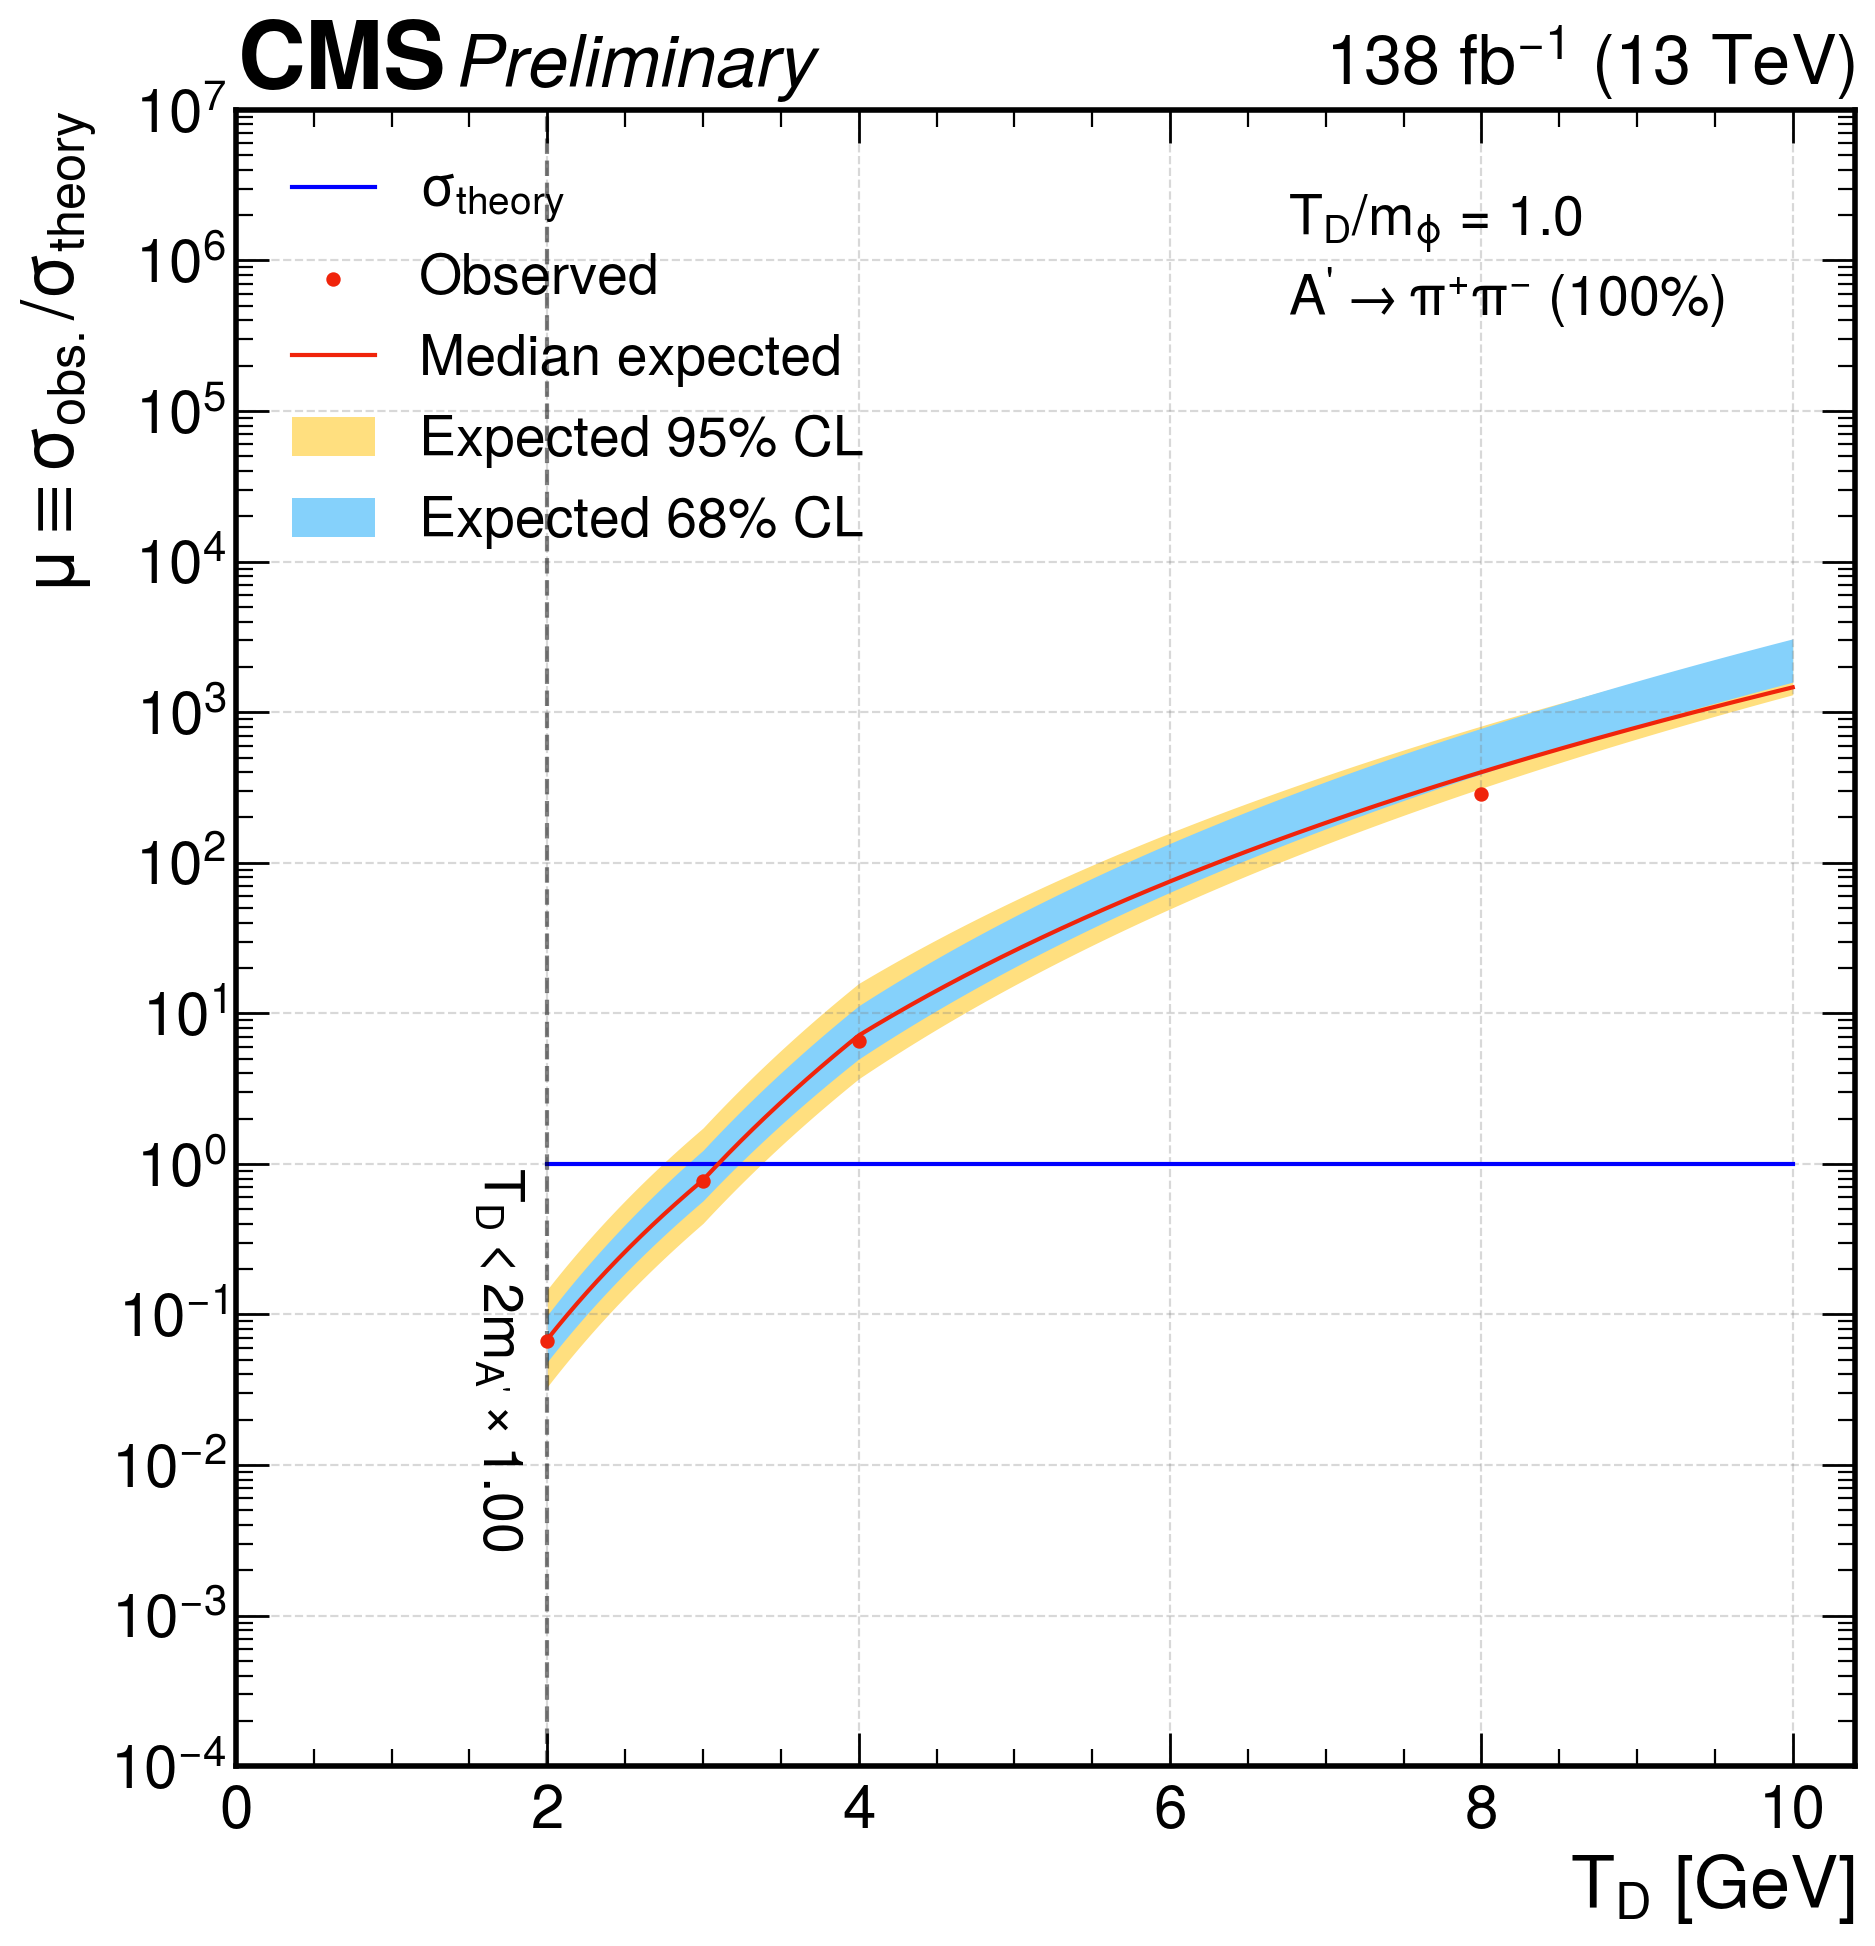

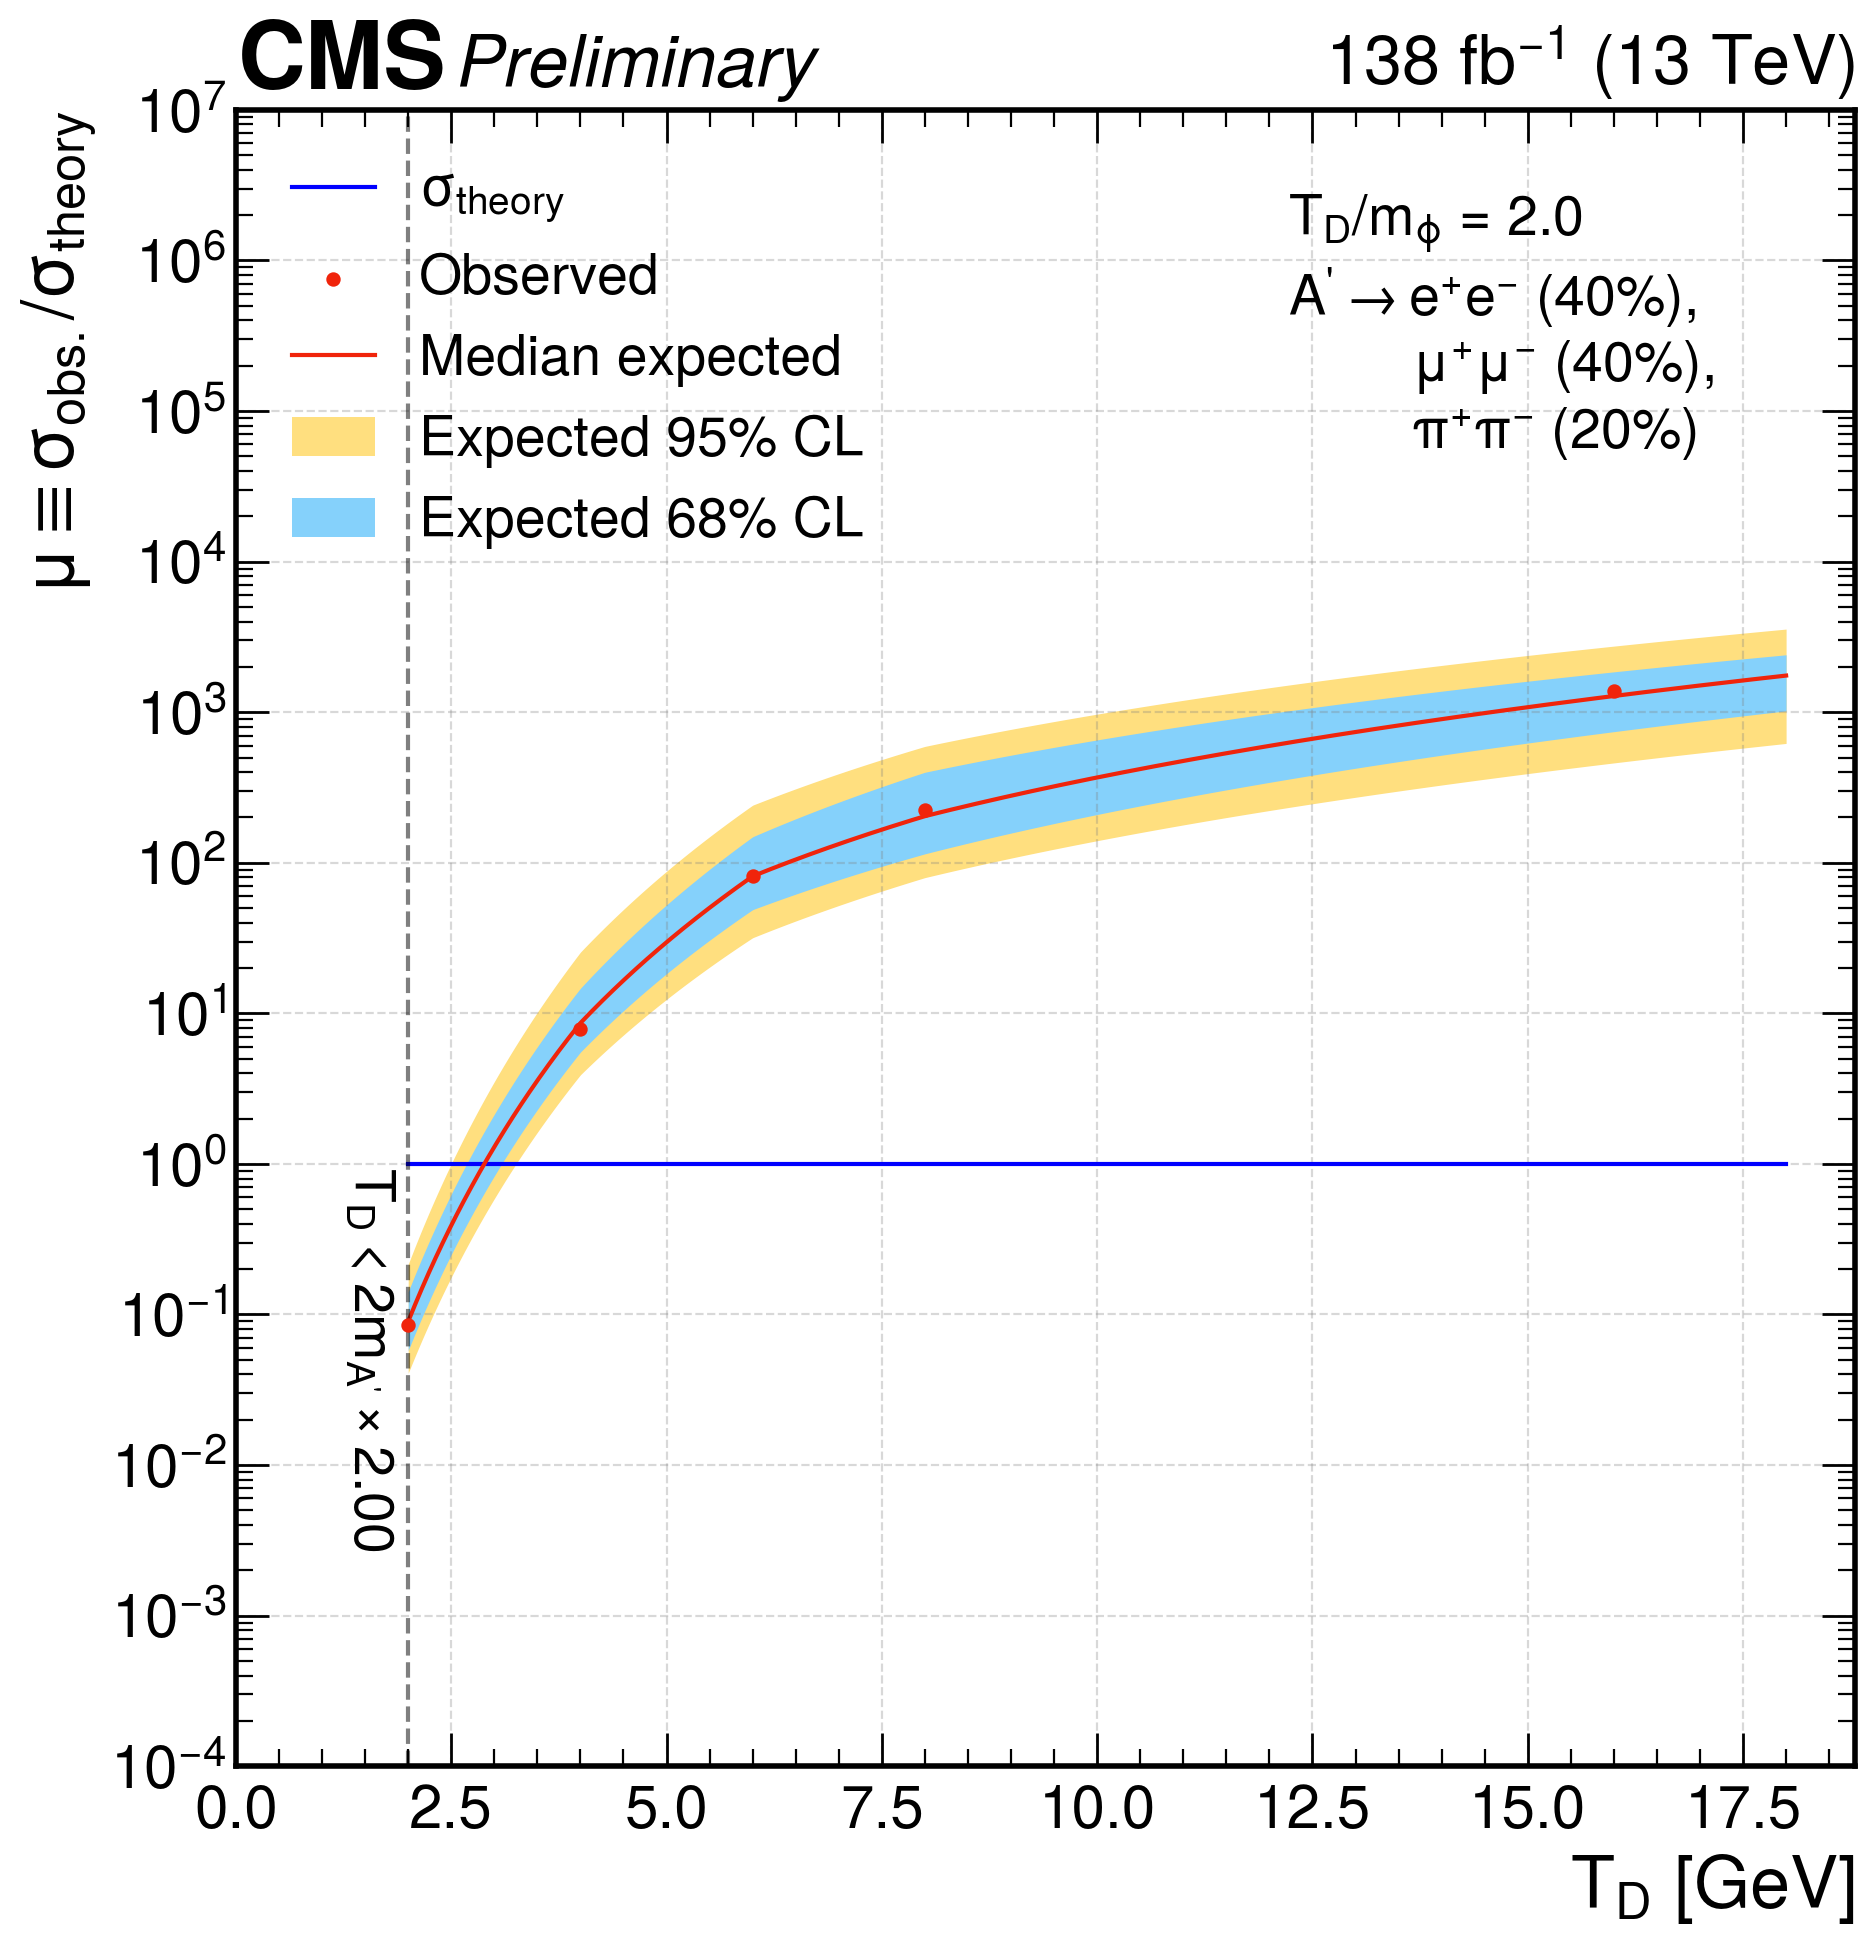

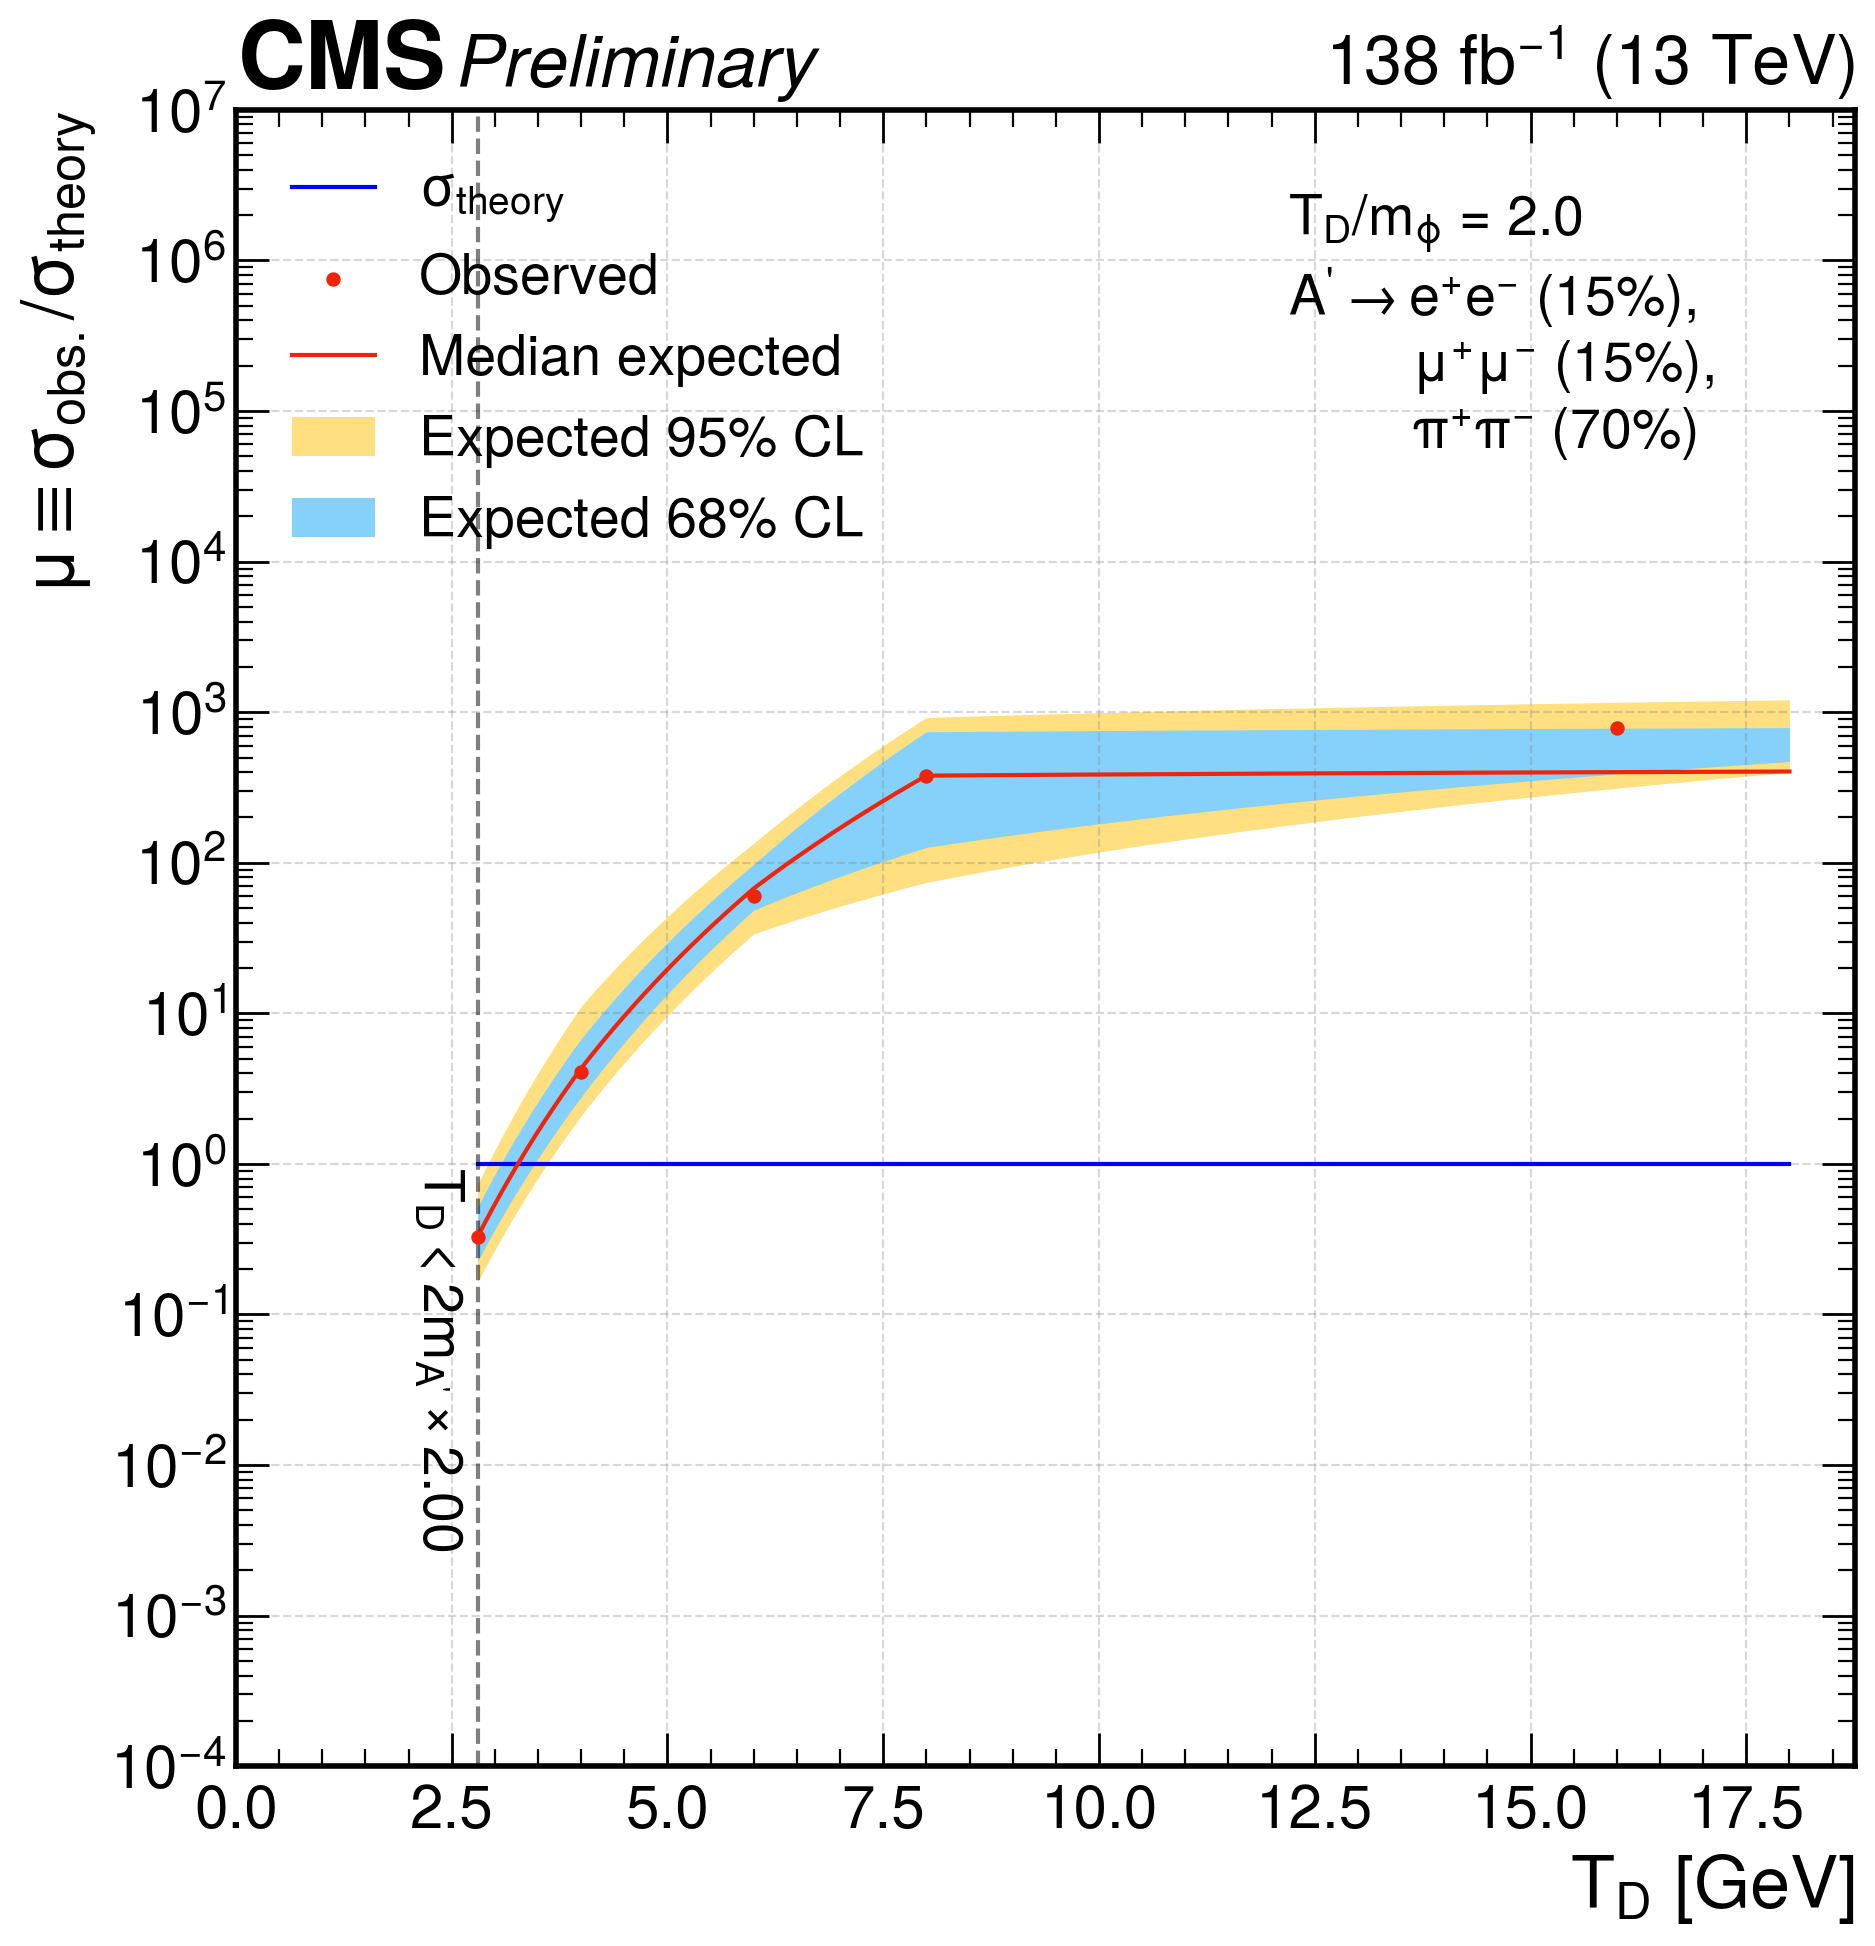

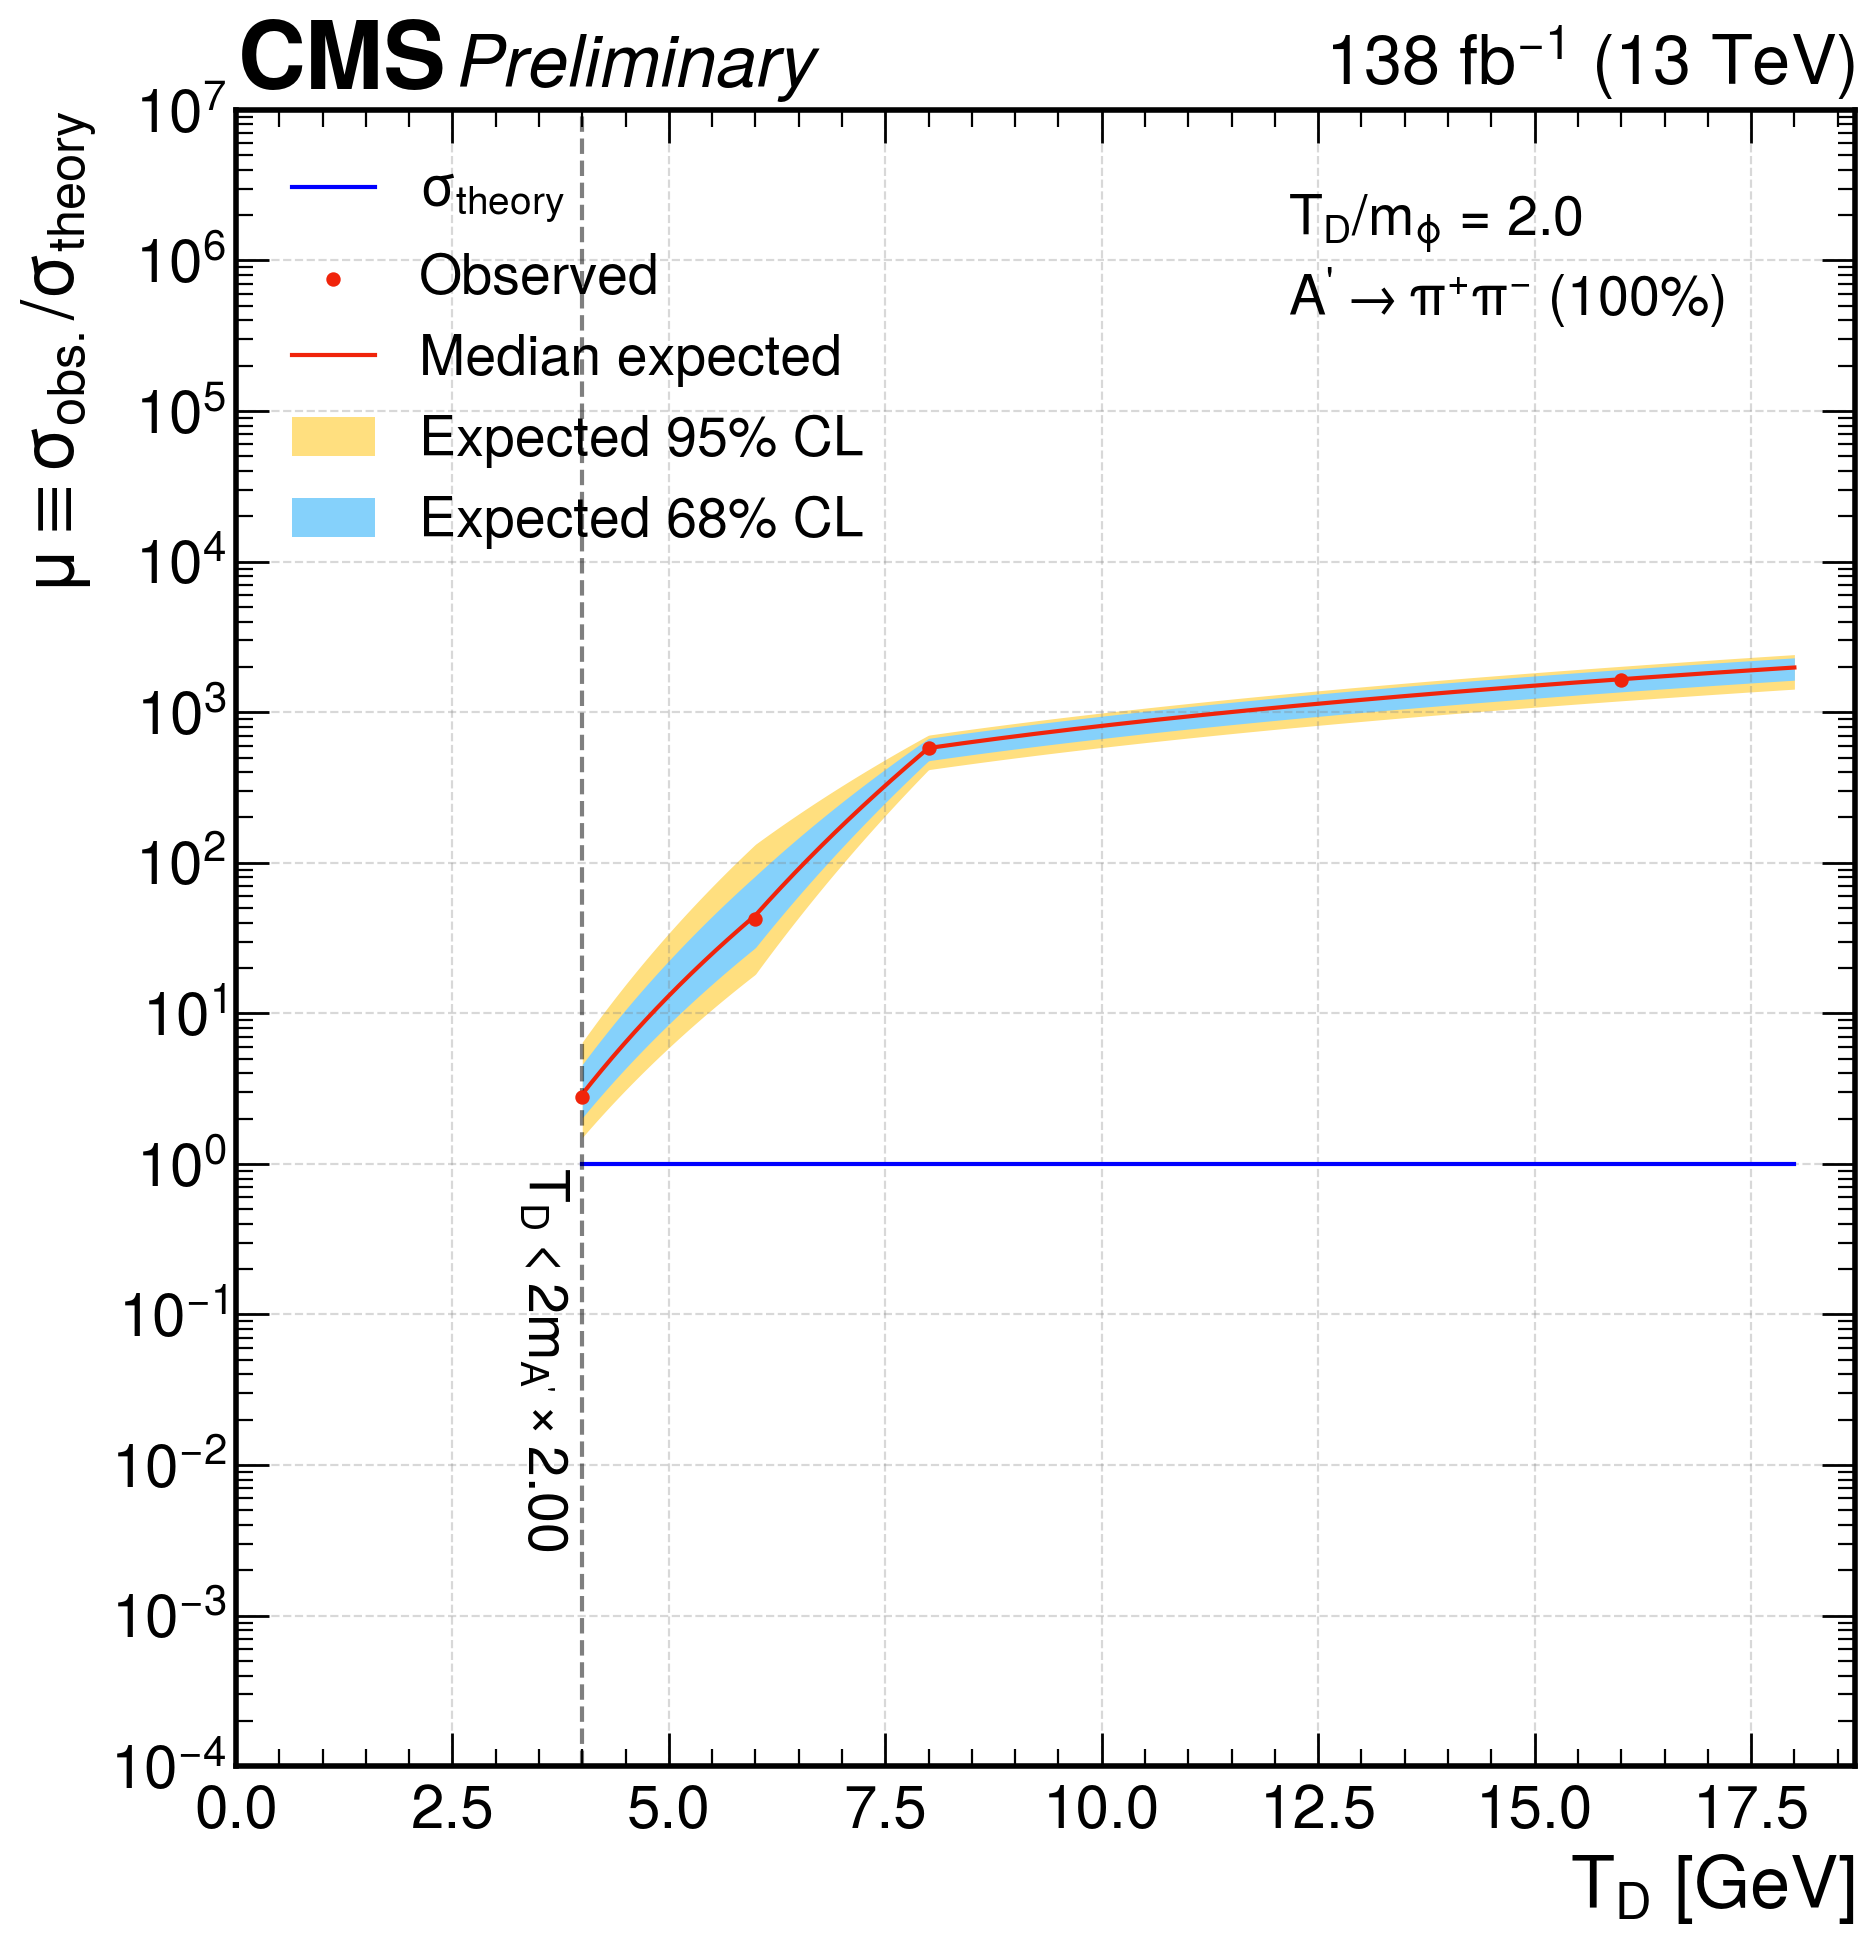

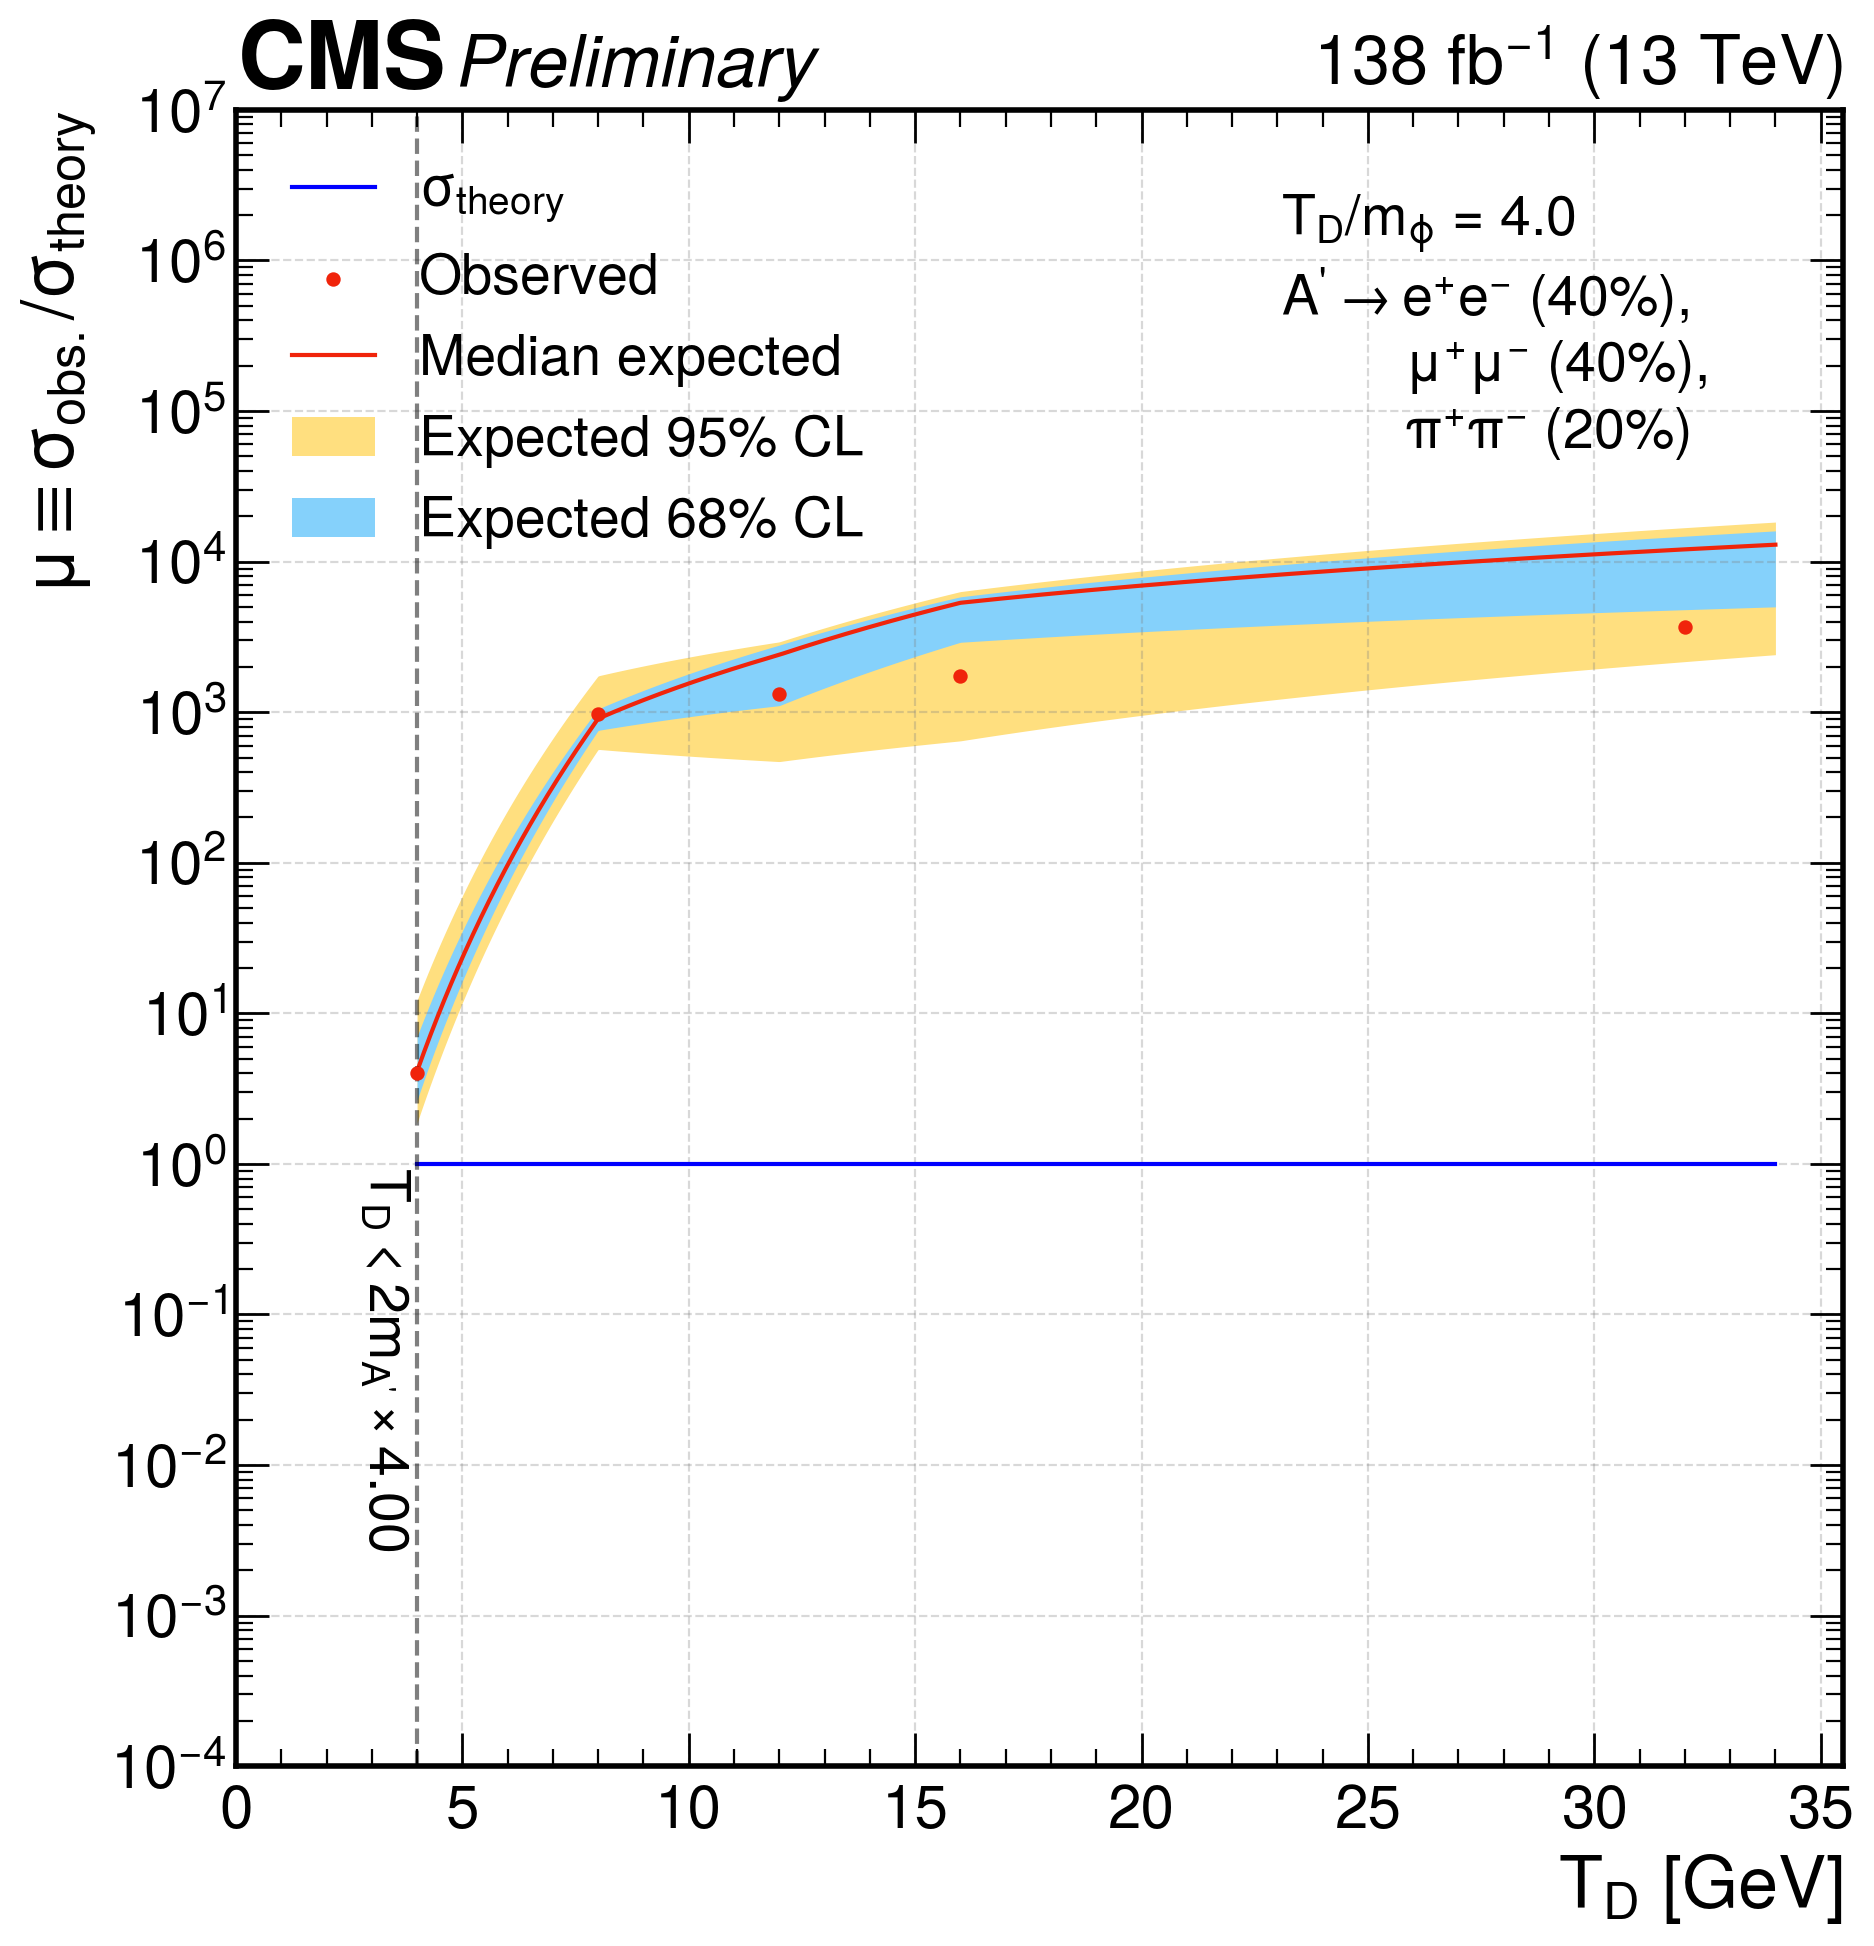

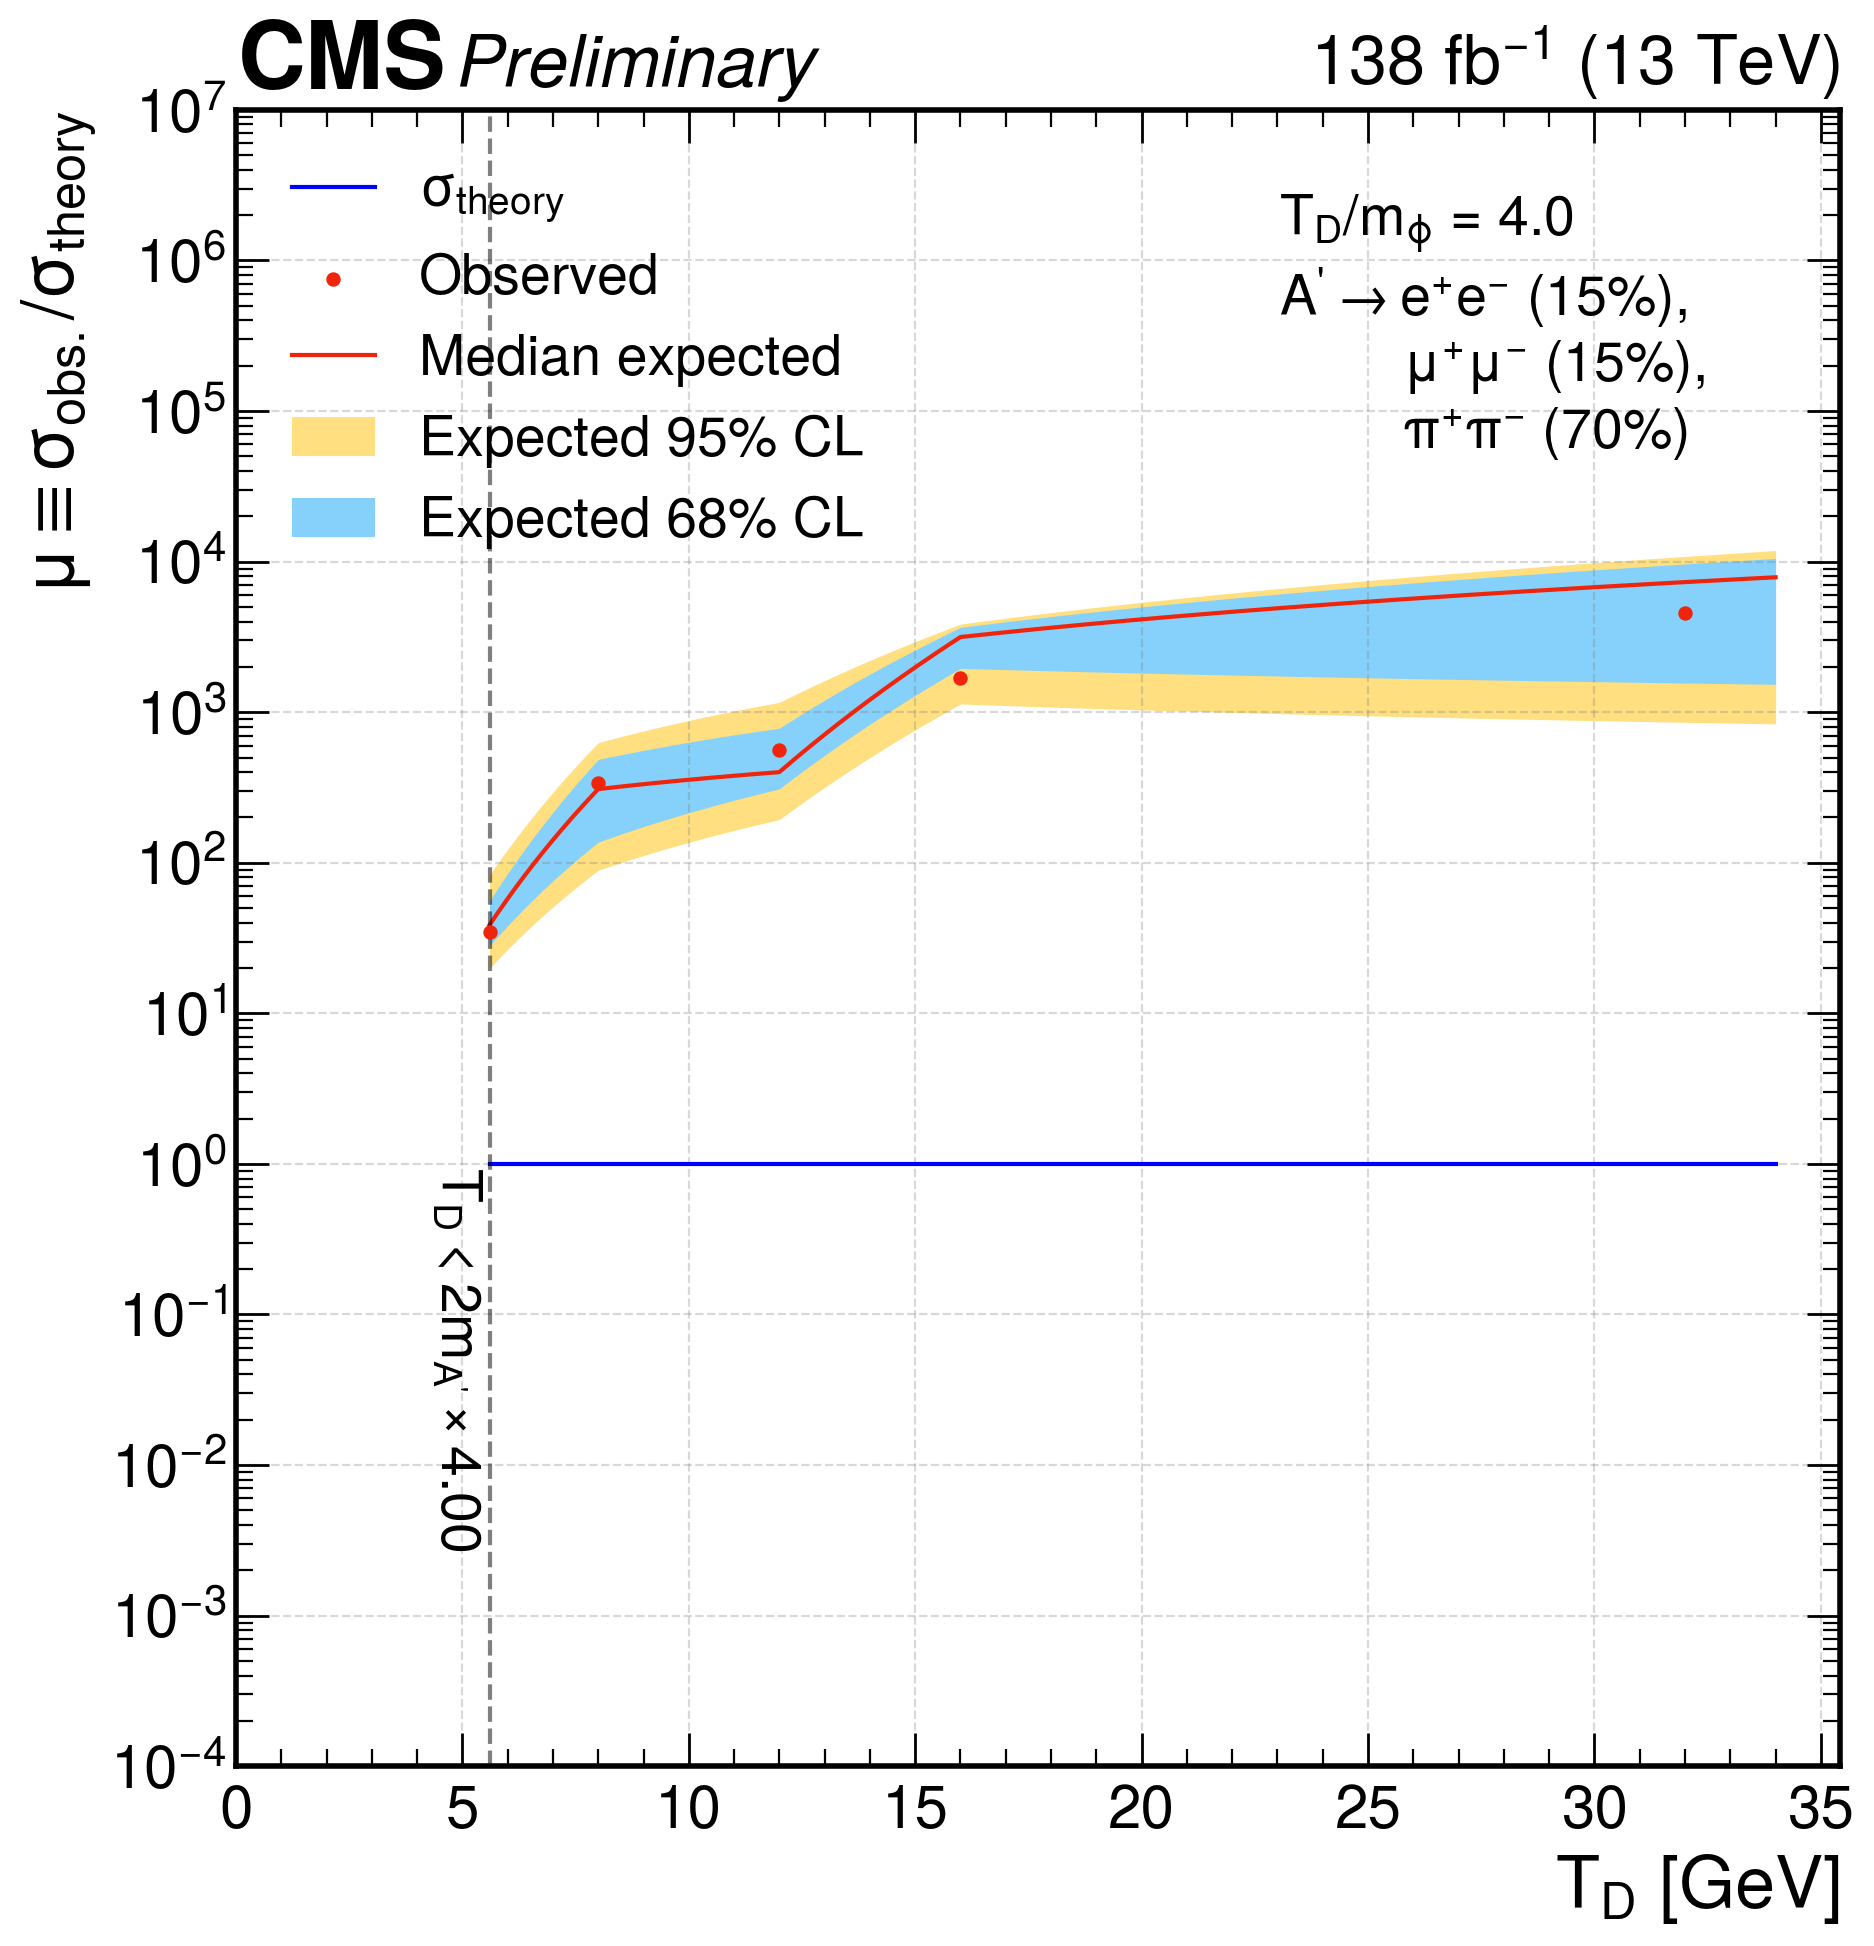

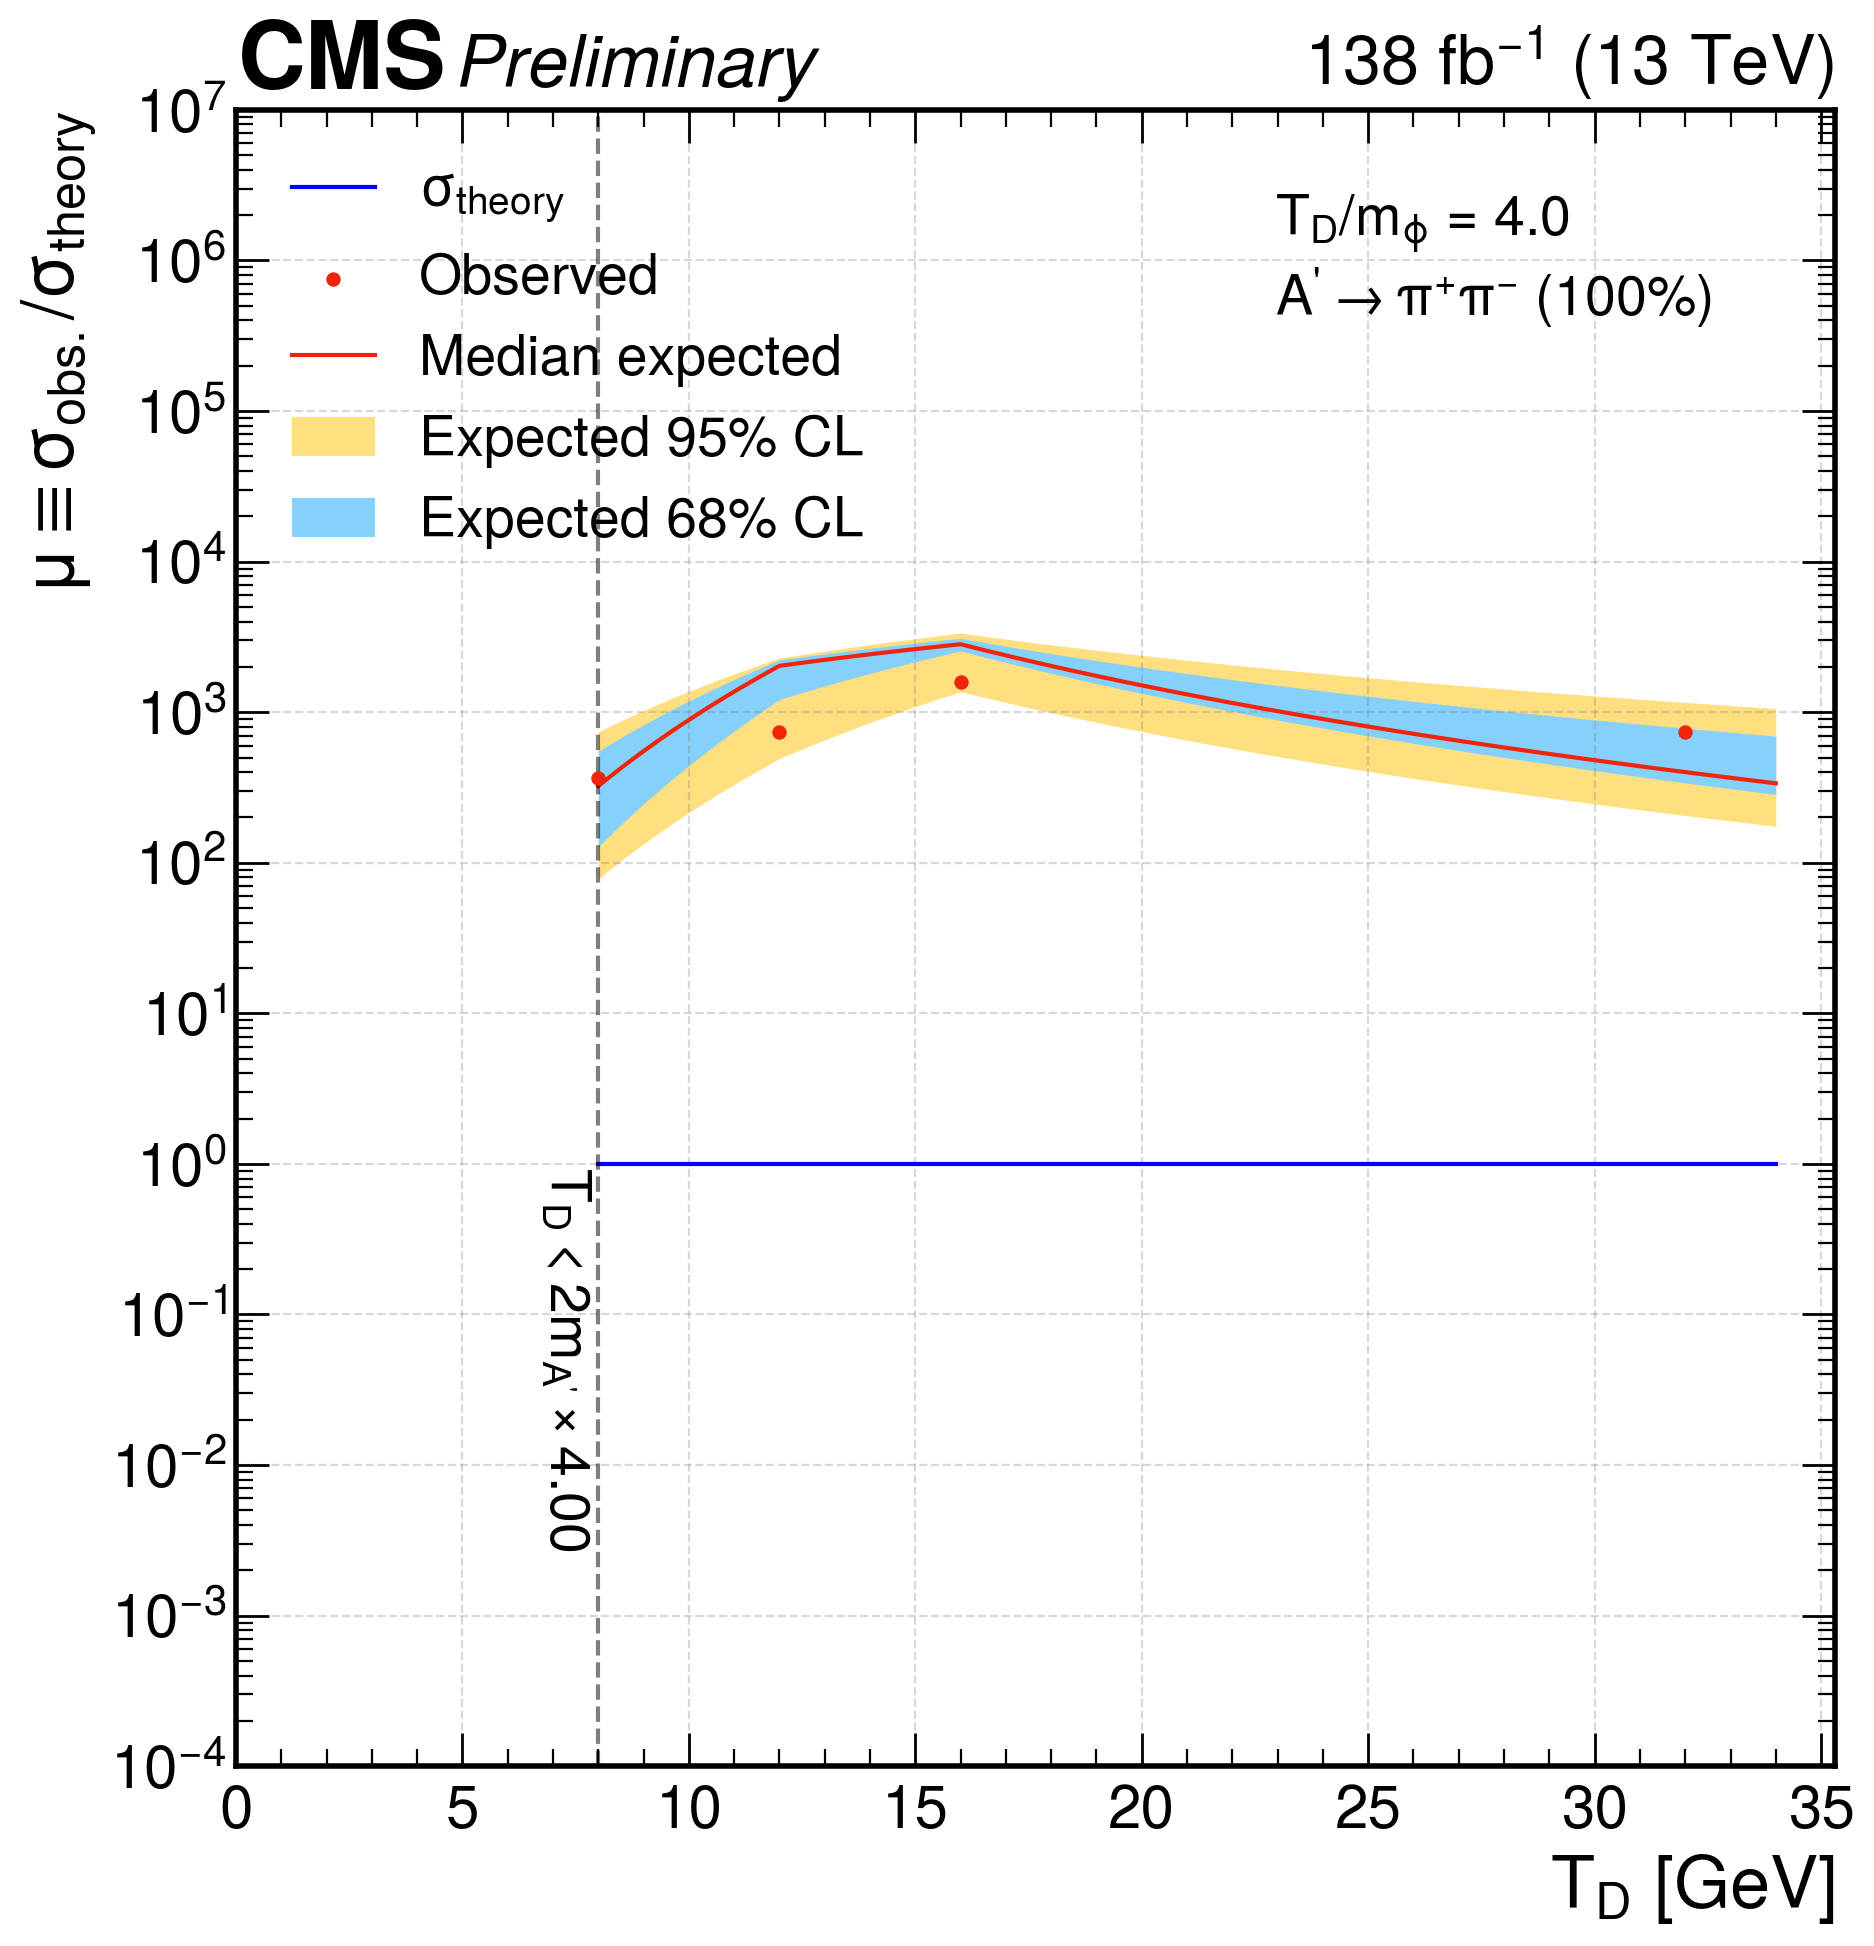

In [25]:
decay_modes = [
    'leptonic', 
    'hadronic',
    'generic'
]
mphi_by_t = [
    0.25,
    0.5,
    1.0,
    2.0,
    4.0
]
show_zh = False

for i in mphi_by_t:
    for decay_mode in decay_modes:

        fig = utils.plot_mphi_by_T_limits(temp_by_mphi=i, ms=125, decay=decay_mode, path='../cards/WH_3_9/', obs_marker='.', method='AsymptoticLimits', analysis='wh', mu_limit=True)
        hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

        # code for adding the ZH limits to this plot
        if show_zh:
            mask = (T/mPhi == i) & (T < 10) & ((T != 0.5) & (mPhi != 0.5) & (T != 1.0) & (mPhi != 1.0))

            xvar = np.linspace(min(T[mask]), max(T[mask])+2, 1000)
            exp_limit = utils.log_interp1d(T[mask], exp[mask]) 
            s1p_limit = utils.log_interp1d(T[mask], s1p[mask])
            s1m_limit = utils.log_interp1d(T[mask], s1m[mask])
            s2p_limit = utils.log_interp1d(T[mask], s2p[mask])
            s2m_limit = utils.log_interp1d(T[mask], s2m[mask])

            ax = fig.get_axes()[0]
            ax.plot(xvar, exp_limit(xvar), ls="--", ms=12, color='cyan', label="ZH Median expected")
            ax.fill_between(xvar, s2m_limit(xvar), s2p_limit(xvar), color="blue", alpha=0.3, lw=0, label="ZH Expected 95% CL")
            ax.fill_between(xvar, s1m_limit(xvar), s1p_limit(xvar), color="darkblue", alpha=0.3, lw=0, label="ZH Expected 68% CL")
            ax.scatter(T[mask], obs[mask], marker='*', s=70, color='cyan', label="ZH Observed") 

        if saveToAN:
            fig.savefig(outDirAN + fig.get_label() + '.pdf', bbox_inches='tight')

## 2D Limits: $m_{\phi}$, T scan

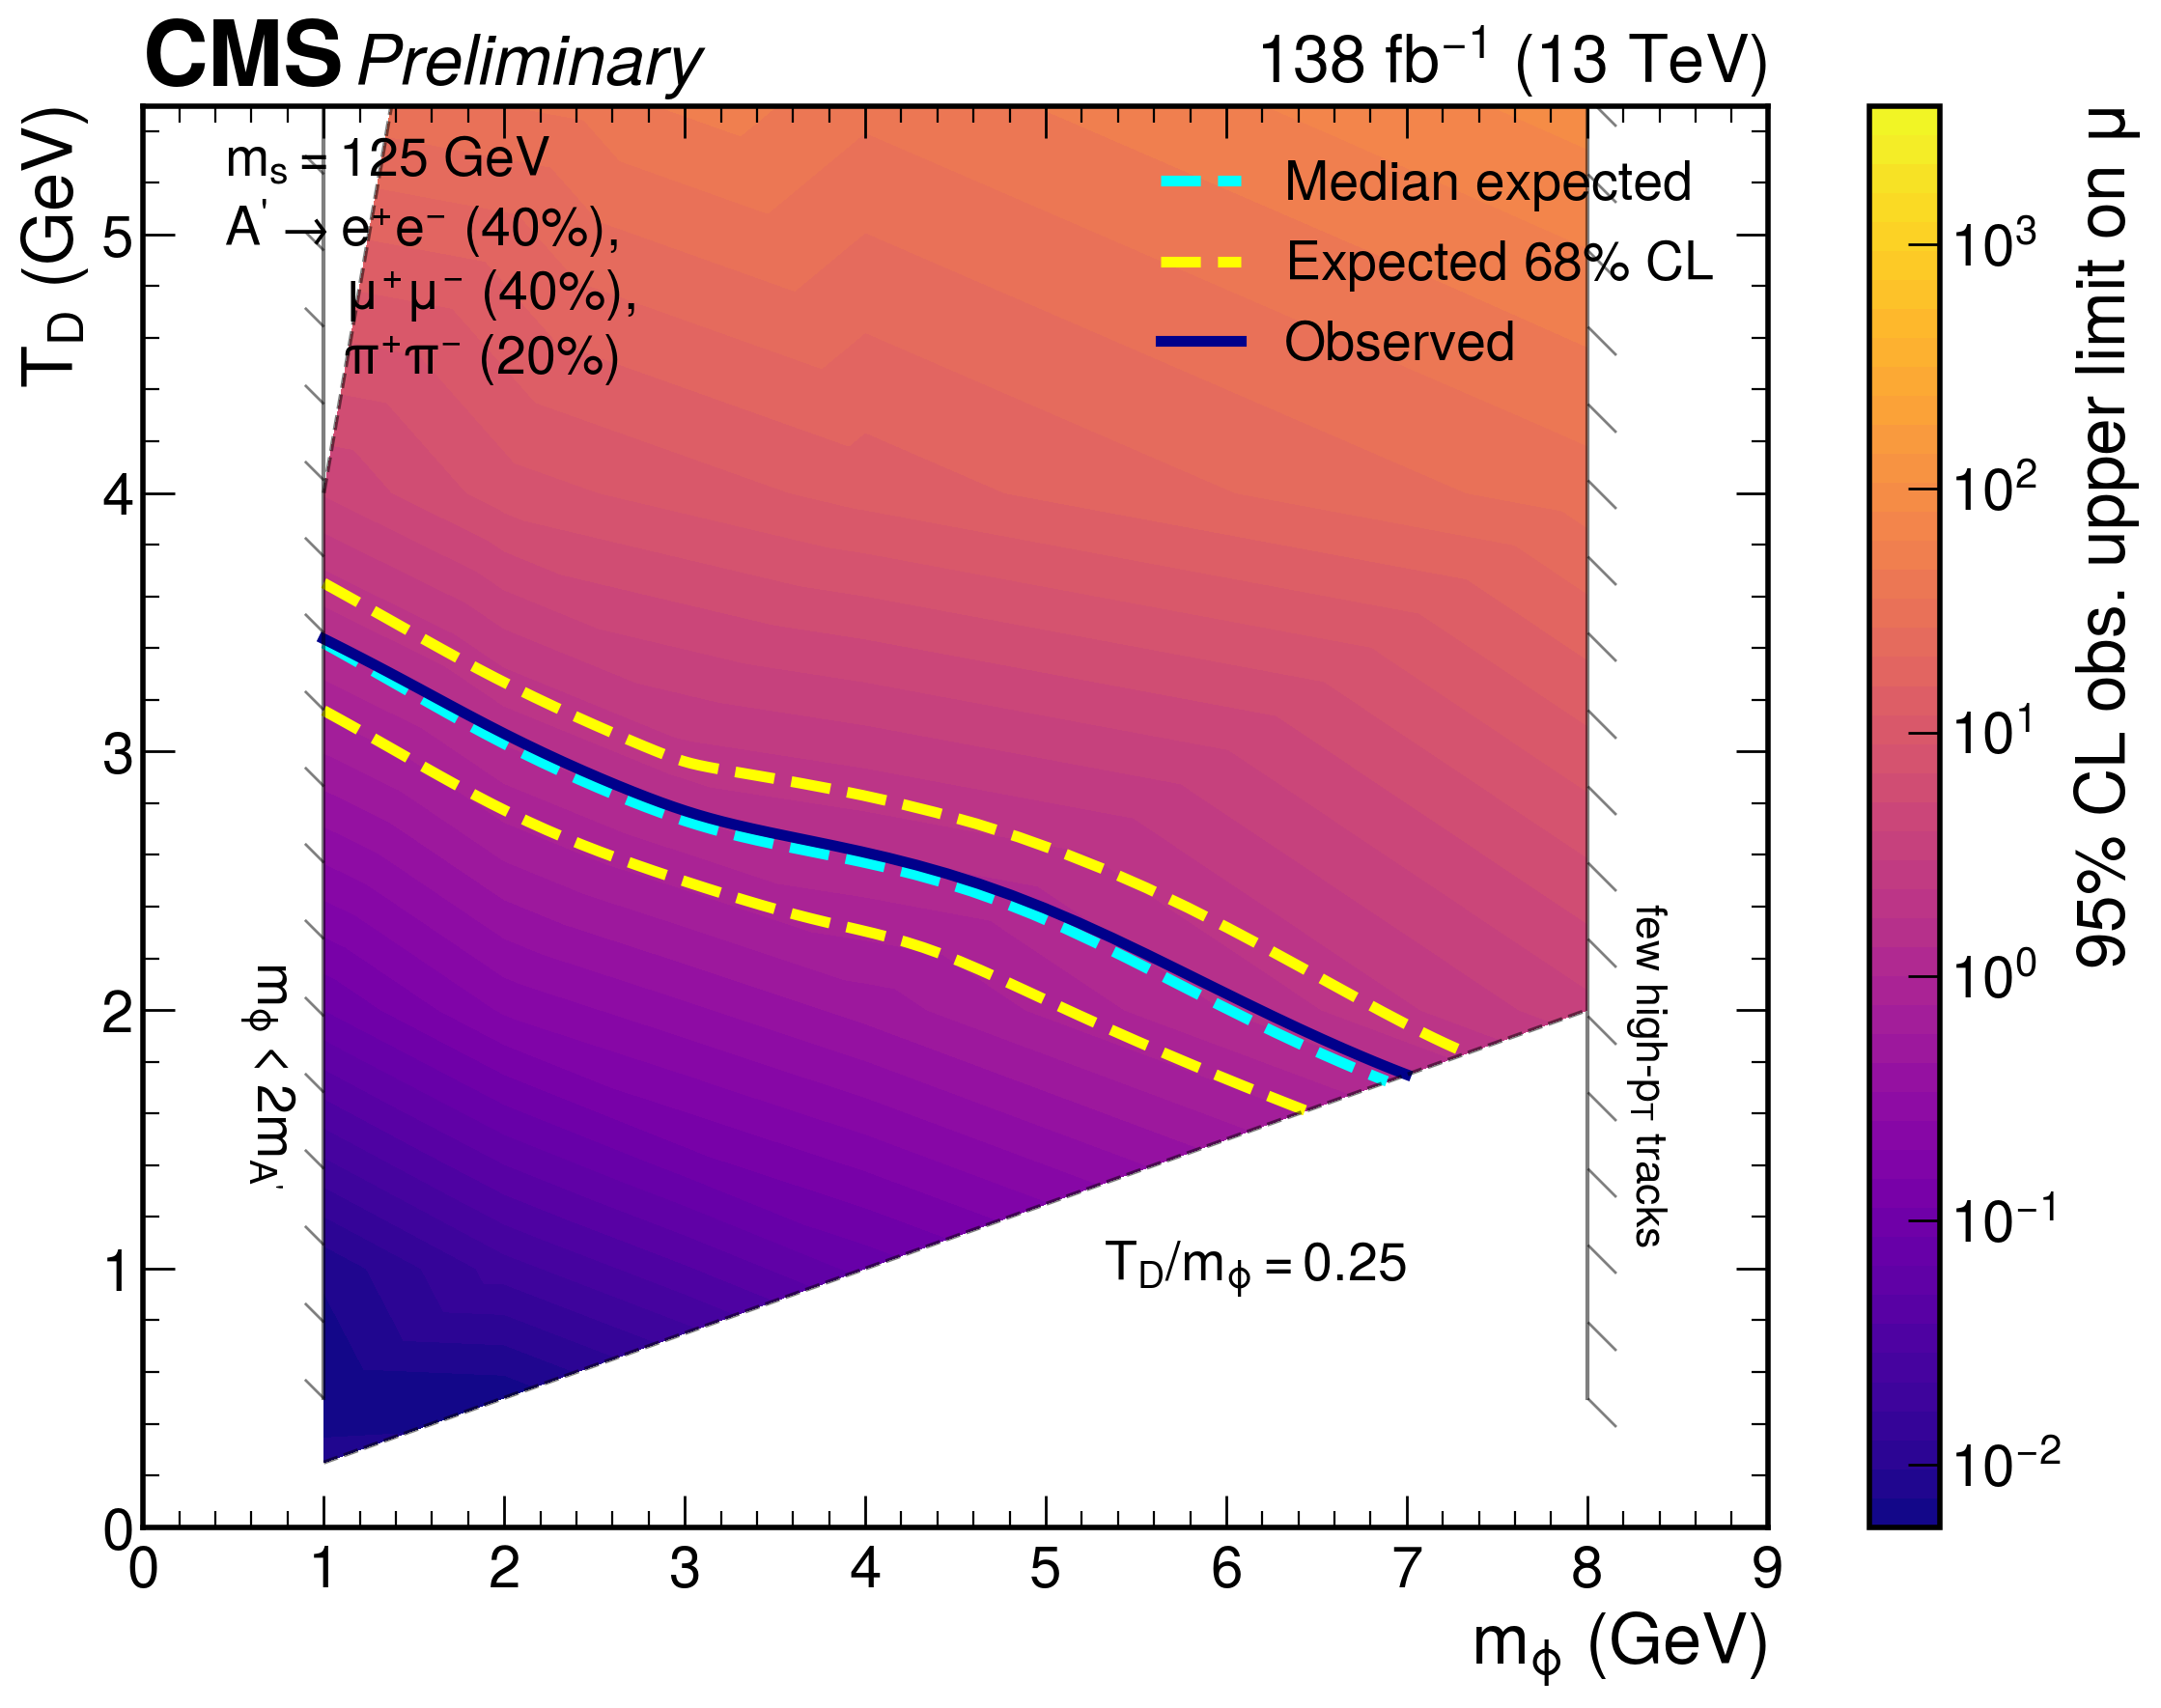

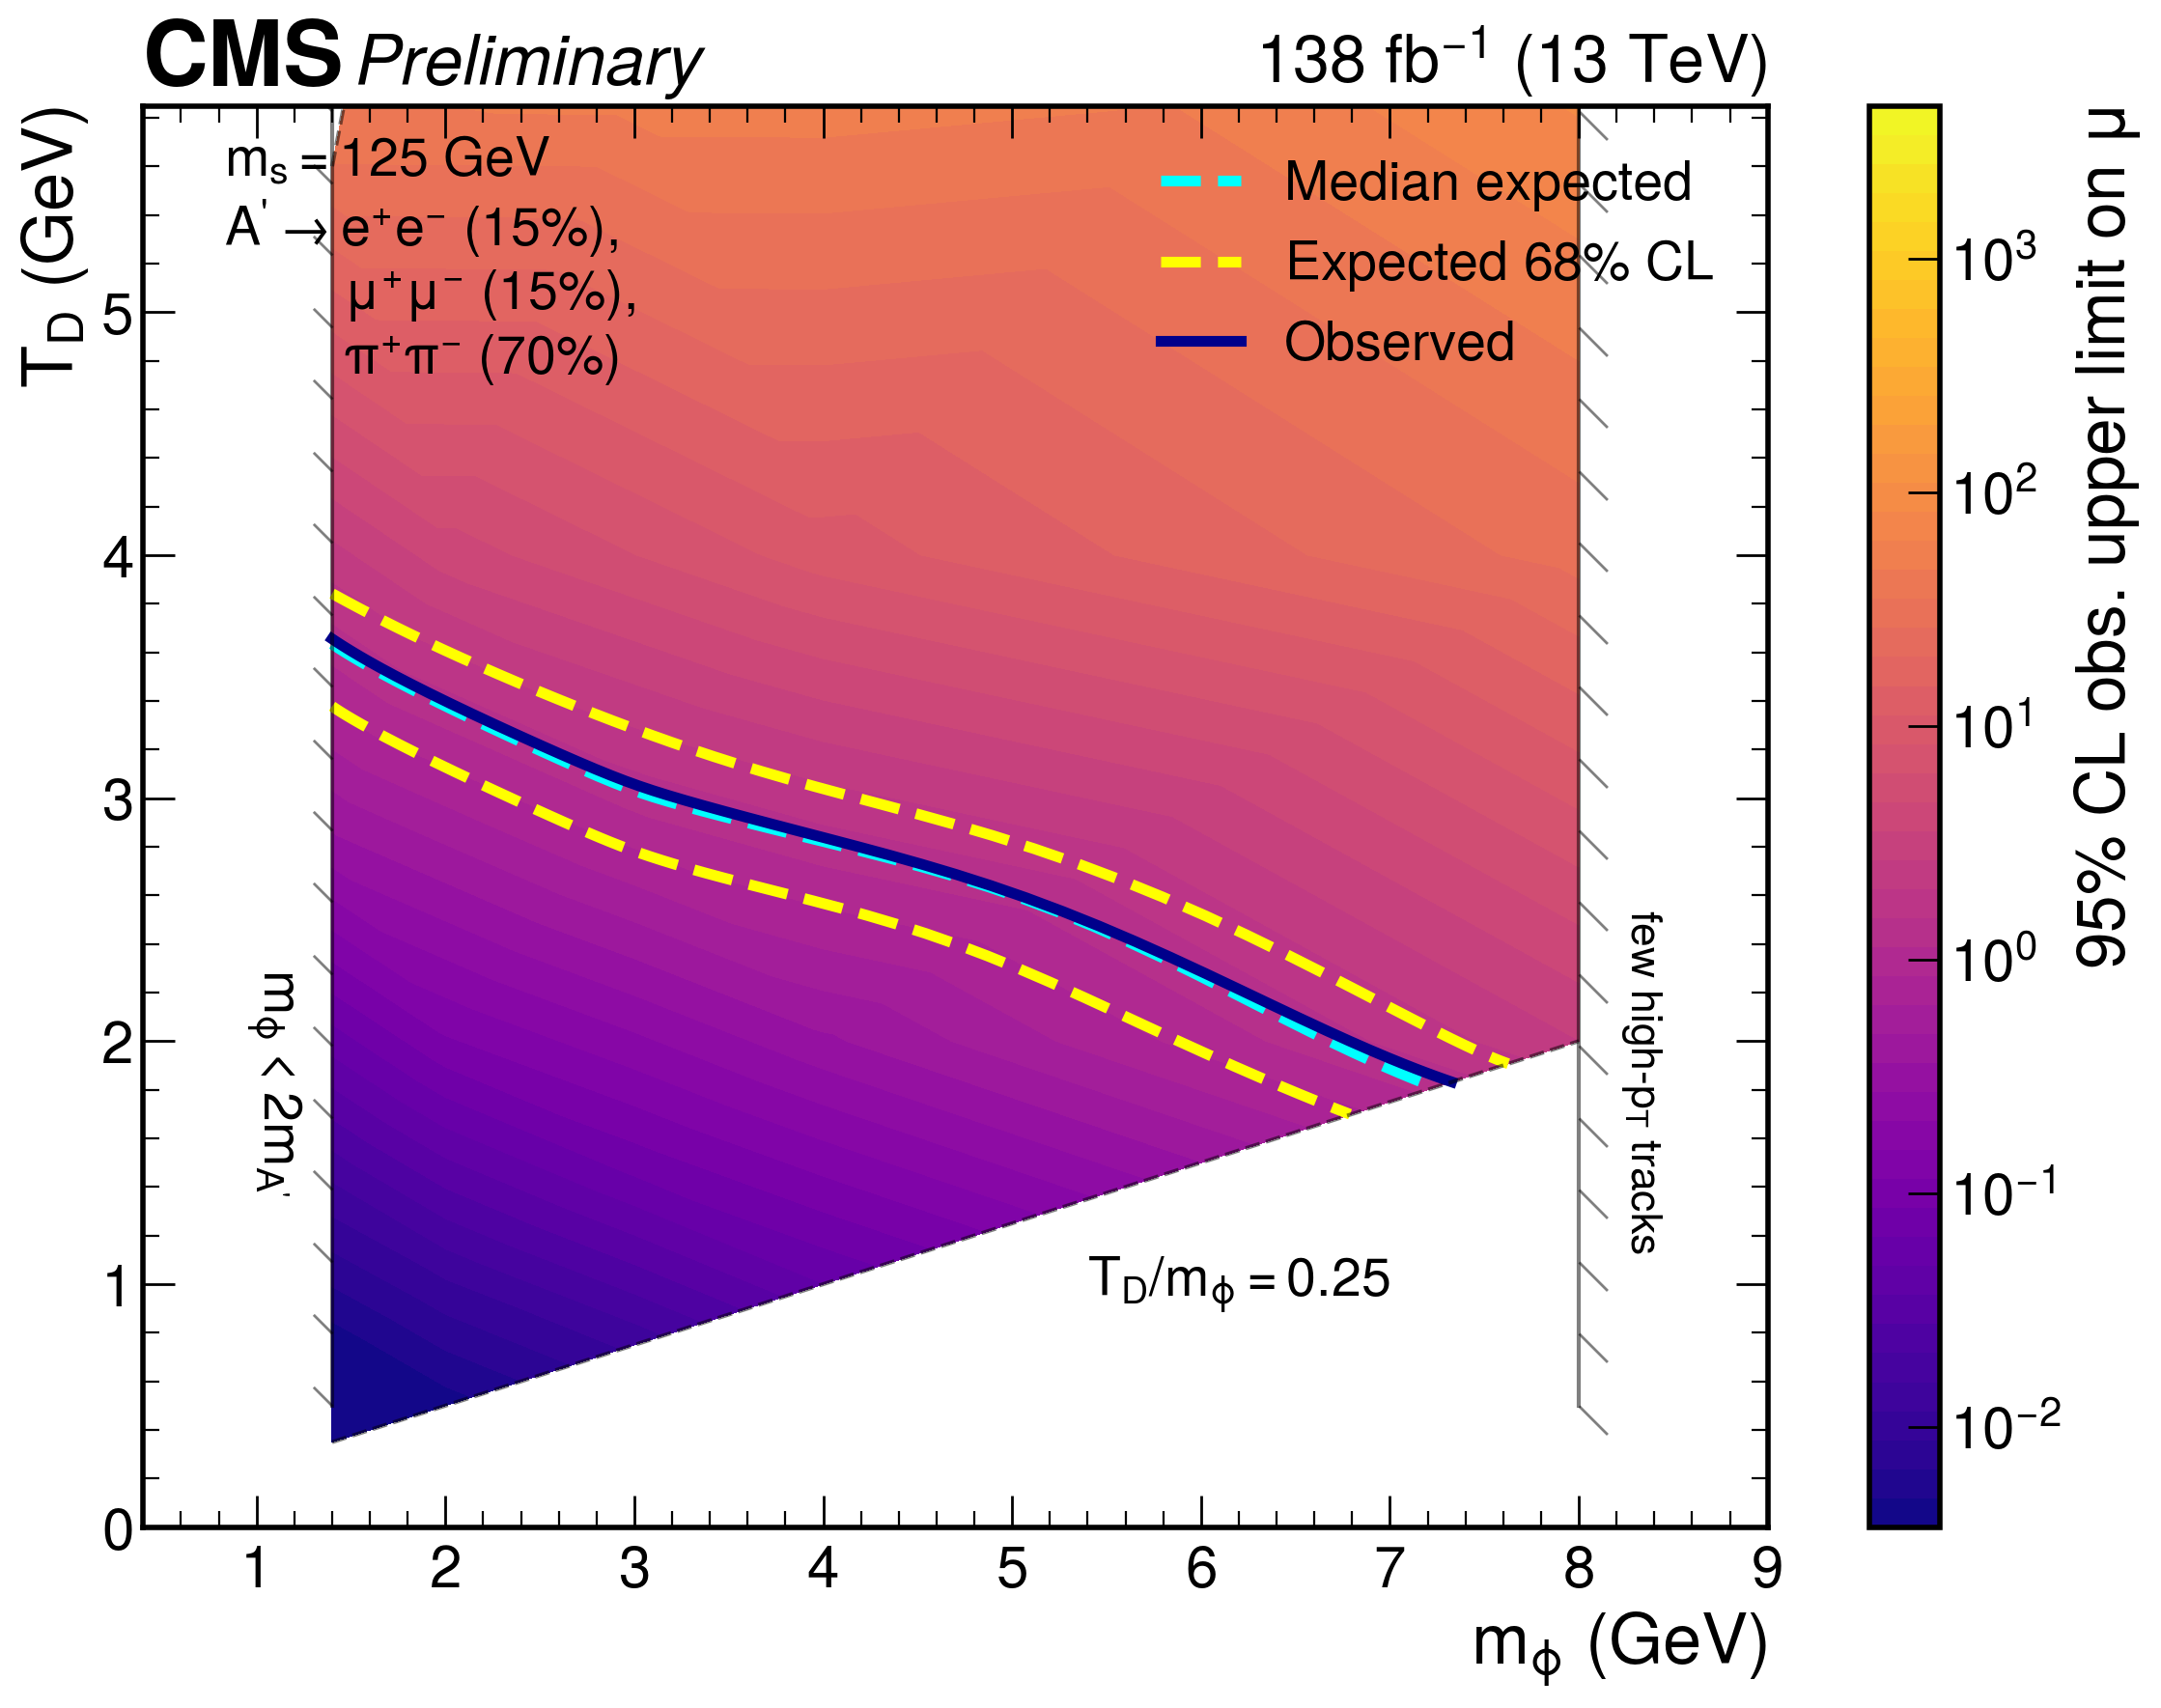

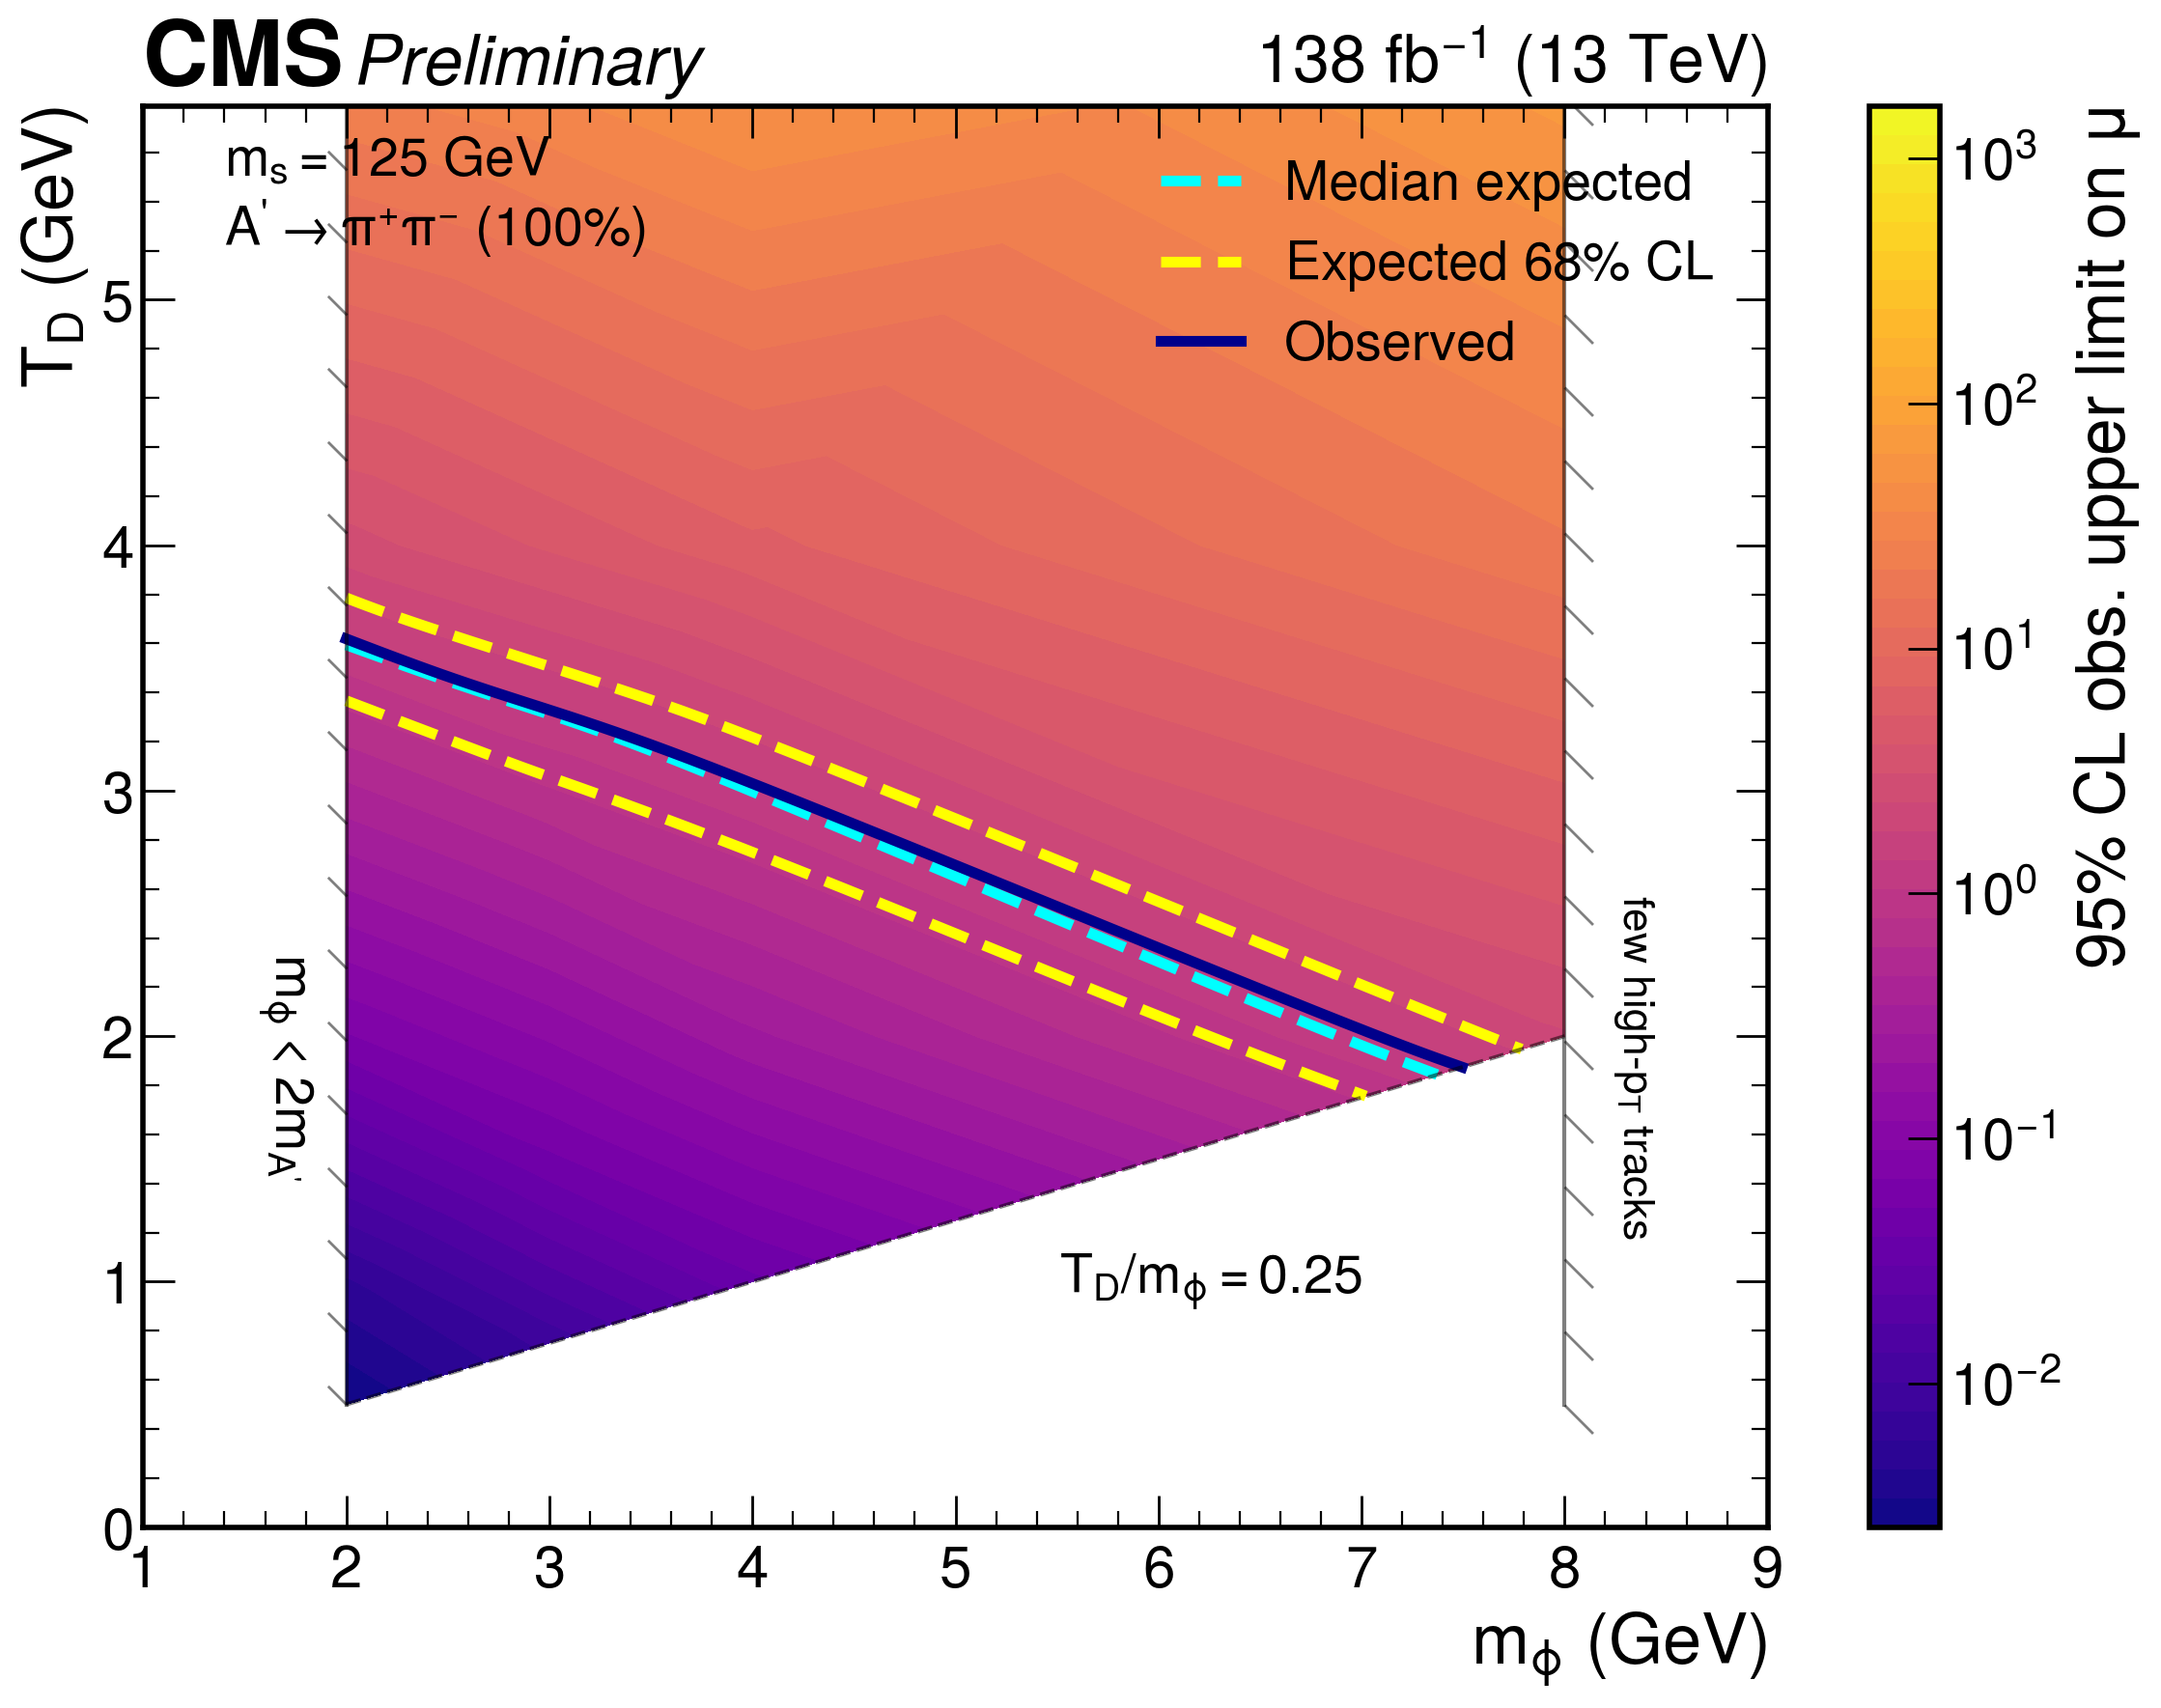

In [24]:
# example usage of the 2D limits function
decay_modes = [
    'leptonic',
    'hadronic',
    'generic'
]

for decay_mode in decay_modes:
    fig = utils.plot_mPhi_temp_limits(
        ms=125, analysis='wh', decay=decay_mode,
        path='../cards/WH_3_9/', method='AsymptoticLimits',
        tricontour='log', showPoints=False, showObserved=True, showTheoryLines=True, cmsLabel=False, muLimit=True
    )
    _ = hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])
    if saveToAN:
        fig.savefig(outDirAN + fig.get_label() + '.pdf', bbox_inches='tight')
    if saveToPAS:
        fig.savefig(outDirPAS + fig.get_label() + '.pdf', bbox_inches='tight')

## PAS: log(T/mD) ZH style 1D limits

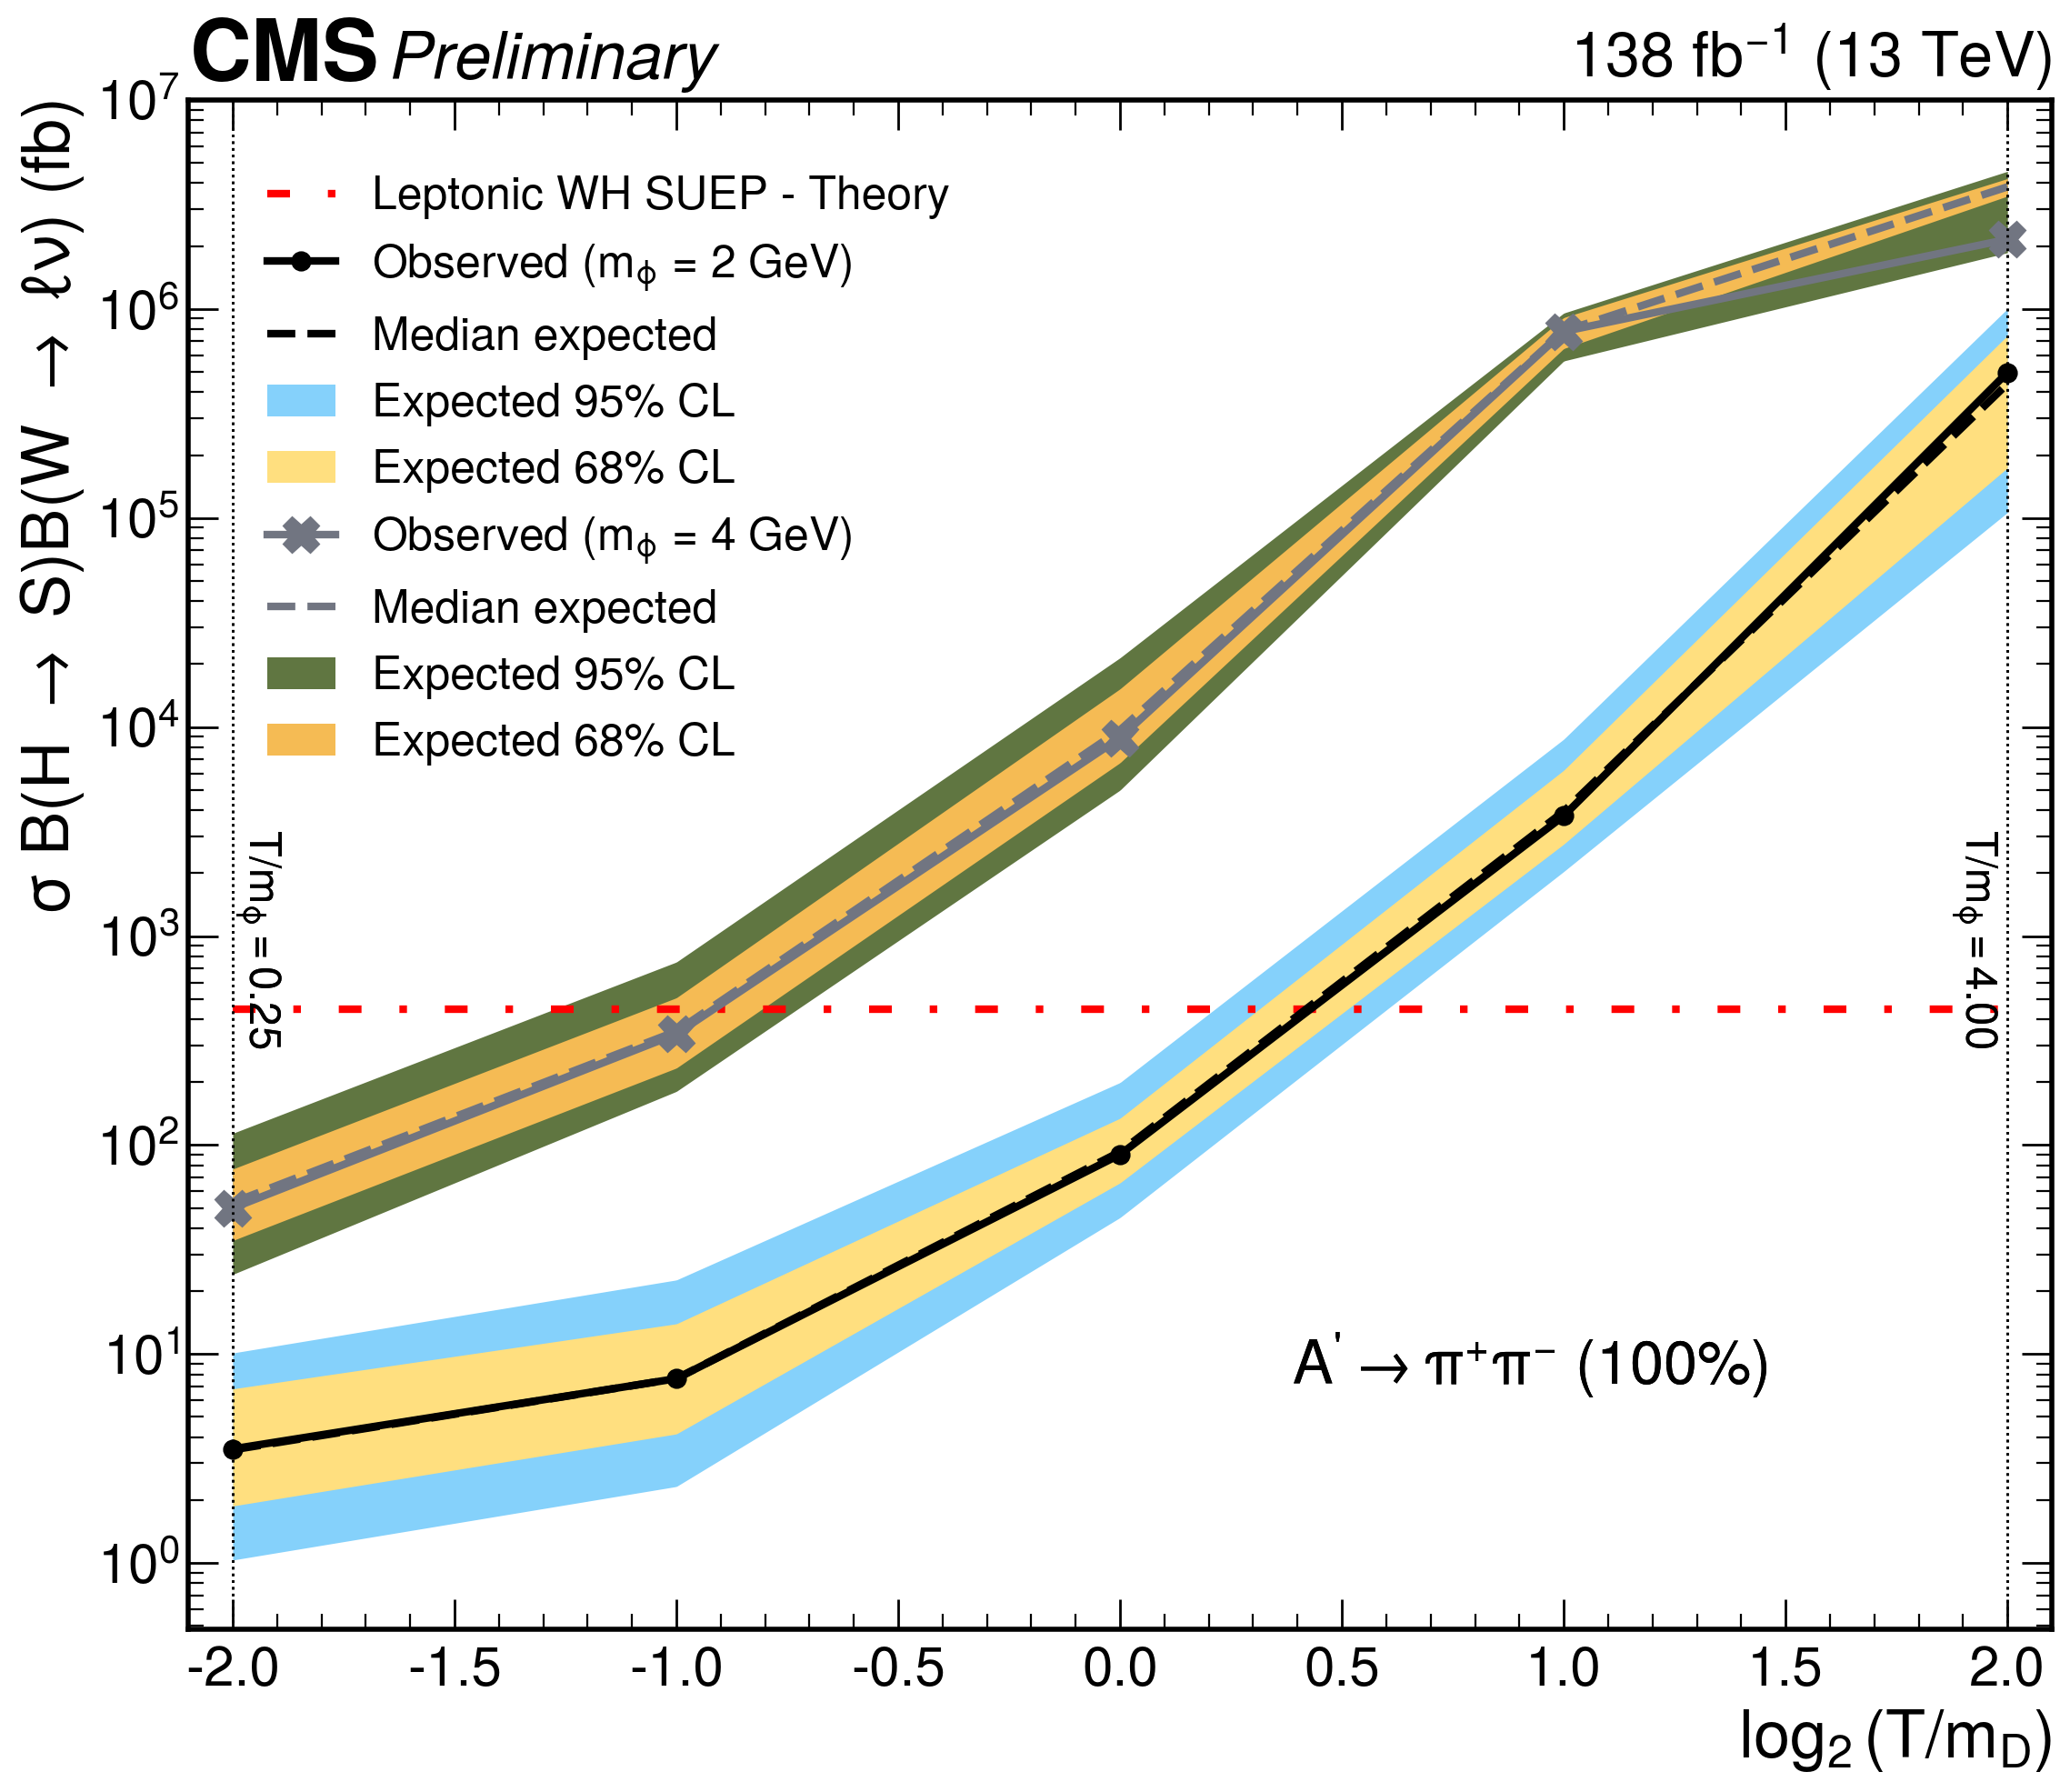

In [23]:
import matplotlib.ticker as ticker
import numpy as np
fig = utils.plot_limits_log2T_by_mD(mD=2.000, ms=125, decay='generic', path='../cards/WH_3_9/', obs_marker='.', method='AsymptoticLimits', analysis='wh', mu_limit=False, all_decays=False, fb=True, legend_label_postfix=' ($m_{\phi}$ = 2 GeV)')
ax = utils.plot_limits_log2T_by_mD(mD=4.000, ms=125, decay='generic', path='../cards/WH_3_9/', color='#717581', obs_marker='X', bands=True, exp_alpha=1.0, method='AsymptoticLimits', analysis='wh', mu_limit=False, ax=fig.axes[0], all_decays=False, fb=True, legend_label_postfix=' ($m_{\phi}$ = 4 GeV)')
#ax = utils.plot_mphi_by_T_limits(temp_by_mphi=1.0, ms=125, decay='hadronic', path='../official-combined/WH/', color='green', obs_marker='x', bands=False, exp_alpha=0.5, method='AsymptoticLimits', analysis='wh', mu_limit=True, ax=fig.axes[0], all_decays=True)
#ax = utils.plot_mphi_by_T_limits(temp_by_mphi=1.0, ms=125, decay='leptonic', path='../official-combined/WH/', color='orange', obs_marker='^', bands=False, exp_alpha=0.5, method='AsymptoticLimits', analysis='wh', mu_limit=True, ax=fig.axes[0], all_decays=True)

hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

ax.set_ylim(top=1e7)

ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Set minor ticks explicitly to appear (2-9 between each power of 10)
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Suppress minor tick labels
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

#fig.set_size_inches(12, 10, forward=True)

handles, labels = fig.get_axes()[0].get_legend_handles_labels()
fig.get_axes()[0].legend(handles, labels, loc=(0.03, 0.55), fontsize=18, ncol=1)

if saveToPAS:
    fig.savefig(outDirPAS + "limits_log2TovermPhi_mPhi_2_4" + '.pdf', bbox_inches='tight')

plt.show()

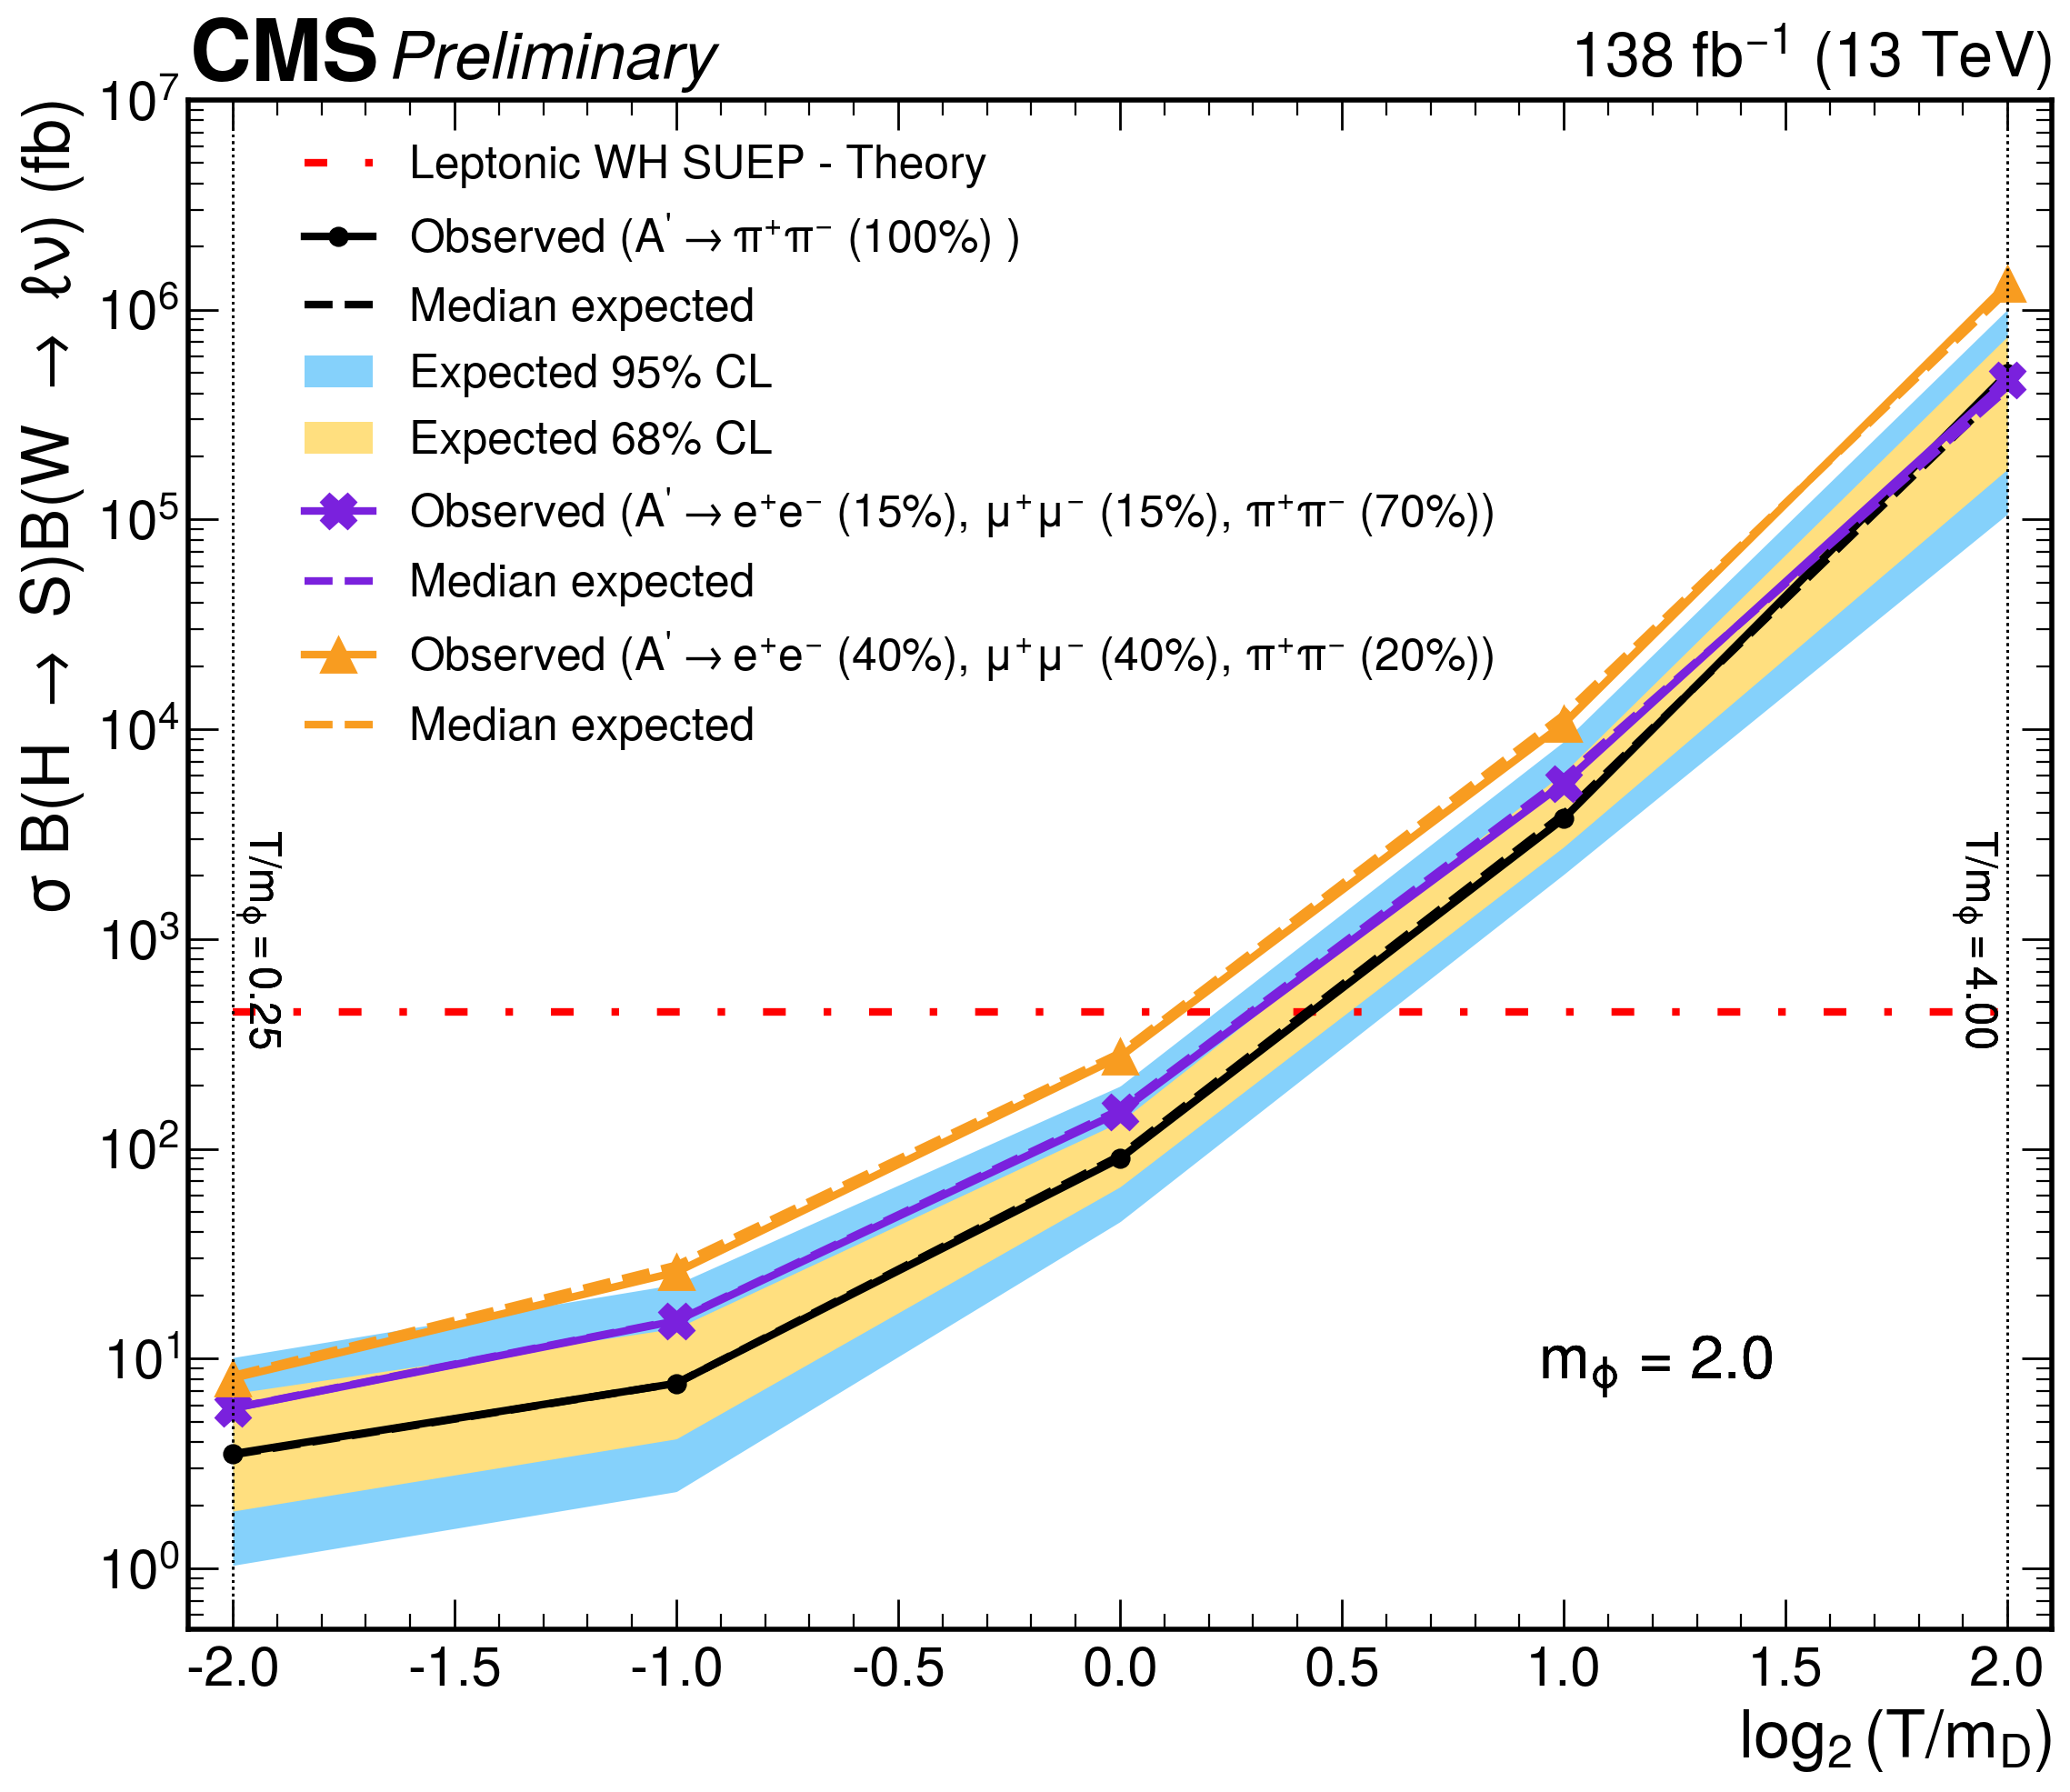

In [22]:
fig = utils.plot_limits_log2T_by_mD(mD=2.000, ms=125, decay='generic', path='../cards/WH_3_9/', obs_marker='.', method='AsymptoticLimits', analysis='wh', mu_limit=False, all_decays=True, fb=True)
ax = utils.plot_limits_log2T_by_mD(mD=2.000, ms=125, decay='hadronic', path='../cards/WH_3_9/', color='#7a21dd', obs_marker='X', bands=False, exp_alpha=0.8, method='AsymptoticLimits', analysis='wh', mu_limit=False, ax=fig.axes[0], all_decays=True, fb=True)
ax = utils.plot_limits_log2T_by_mD(mD=2.000, ms=125, decay='leptonic', path='../cards/WH_3_9/', color='#f89c20', obs_marker='^', bands=False, exp_alpha=0.6, method='AsymptoticLimits', analysis='wh', mu_limit=False, ax=fig.axes[0], all_decays=True, fb=True)

# label
hep.cms.label(data=True, llabel='Preliminary', lumi=utils.lumis['combined'], ax=fig.get_axes()[0])

# y limit and ticks
ax.set_ylim(top=1e7)

ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=20))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Set minor ticks explicitly to appear (2-9 between each power of 10)
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Suppress minor tick labels
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# legend
handles, labels = fig.get_axes()[0].get_legend_handles_labels()
fig.get_axes()[0].legend(handles, labels, loc=(0.05, 0.56), fontsize=18, ncol=1)

if saveToPAS:
    fig.savefig(outDirPAS + "limits_log2TovermPhi_mPhi_2_mA_all" + '.pdf', bbox_inches='tight')

plt.show()